In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
#new trail no overfit

In [ ]:
"""
Transformer-based Text Classifier — Trained from Scratch (v2)
Dataset: Telugu Dialect / Idiom Classification
  Rows 1-2084    -> Telangana   (label 0)
  Rows 2085-4215 -> Rayalaseema (label 1)
  Rows 4216-6011 -> Idioms      (label 2)

CHANGES FROM v1 (why + what):
  1. DATA CLEANING / DEDUP
     - Unicode-normalize + strip every text
     - Drop empty / 1-token rows (near-meaningless for a sentence classifier)
     - Drop exact duplicate (text, label) rows
     - Drop "conflicting" duplicates: same text appearing under >1 label
       (this is label noise / potential train-test leakage if left in)
  2. OVERFITTING REDUCTION
     - NUM_LAYERS 3 -> 2  (your own ablation showed 2 layers matched/beat
       3 layers under equal budget - fewer params for ~4-5k training rows)
     - DROPOUT 0.1 -> 0.2, WEIGHT_DECAY 1e-4 -> 5e-4
     - Added light training-time token dropout (word -> <UNK> at 5%) as
       cheap data augmentation, applied ONLY to the training split
     - Early stopping now watches VALIDATION LOSS, not validation accuracy
       (accuracy can plateau/tie while loss is already climbing -> better
       overfitting signal)
  3. CLASS BALANCE
     - WeightedRandomSampler on the training loader (inverse class
       frequency) instead of plain shuffle, so the smaller "Idioms" class
       is not under-sampled per batch
  4. CONSISTENCY FIX (publication-integrity issue from v1)
     - Ablation study now uses the SAME early-stopping routine and epoch
       budget as the main run (train_with_early_stopping()), so the
       "baseline" row in the ablation table will actually match the main
       reported test accuracy instead of silently diverging.

Everything else (ROC/PR curves, calibration, bootstrap CI, robustness
analysis, dashboard) is unchanged in spirit, just re-wired to use the new
shared training function.
"""

# ─────────────────────────────────────────────
# 1. IMPORTS
# ─────────────────────────────────────────────
import os
import re
import math
import random
import warnings
import unicodedata
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
    average_precision_score, brier_score_loss,
    f1_score, accuracy_score
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 2. REPRODUCIBILITY
# ─────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ─────────────────────────────────────────────
# 3. CONFIGURATION
# ─────────────────────────────────────────────
EXCEL_FILE  = "/content/classification model obj 4.xlsx"
TEXT_COL    = None

MAX_SEQ_LEN = 128
VOCAB_SIZE  = 8000
EMBED_DIM   = 128
NUM_HEADS   = 4
NUM_LAYERS  = 2          # was 3 -> reduced capacity, ablation-justified
FF_DIM      = 256
DROPOUT     = 0.2        # was 0.1
NUM_CLASSES = 3

BATCH_SIZE  = 32
EPOCHS      = 25         # ceiling; early stopping will usually stop earlier
LR          = 3e-4
WEIGHT_DECAY= 5e-4       # was 1e-4
PATIENCE    = 4          # was 5, watching val LOSS now (not accuracy)

TRAIN_TOKEN_DROPOUT = 0.05   # p of replacing a training-time word with <UNK>
MIN_TOKENS          = 2      # drop rows shorter than this after cleaning

ID2LABEL = {0: "Telangana", 1: "Rayalaseema", 2: "Idioms"}
COLORS   = ["#4C72B0", "#DD8452", "#55A868"]

PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# ─────────────────────────────────────────────
# 4. PLOT STYLE HELPER
# ─────────────────────────────────────────────
def set_style():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor"  : "#F8F9FA",
        "axes.grid"       : True,
        "grid.alpha"      : 0.4,
        "grid.linestyle"  : "--",
        "font.size"       : 11,
        "axes.titlesize"  : 13,
        "axes.labelsize"  : 11,
        "legend.fontsize" : 10,
        "lines.linewidth" : 2,
    })

set_style()

def save_fig(name: str):
    path = os.path.join(PLOT_DIR, f"{name}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"[Saved] {path}")

# ─────────────────────────────────────────────
# 5. DATA LOADING + CLEANING / DEDUP
# ─────────────────────────────────────────────
def _clean_text(t: str) -> str:
    t = unicodedata.normalize("NFC", str(t))
    t = t.strip().lower()
    t = re.sub(r"[^\u0C00-\u0C7Fa-z0-9\s\u0964,.!?'-]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

def clean_and_dedupe(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize text, drop empties/too-short rows, drop exact duplicates,
    and drop rows whose text conflicts with a different label elsewhere."""
    orig_n = len(df)

    df = df.copy()
    df["text"] = df["text"].apply(_clean_text)

    df = df[df["text"].str.len() > 0]
    df = df[df["text"].str.split().str.len() >= MIN_TOKENS]
    after_empty = len(df)

    before_dupe = len(df)
    df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
    exact_dupes_removed = before_dupe - len(df)

    dupe_mask   = df.duplicated(subset=["text"], keep=False)
    conflict_ct = df[dupe_mask].groupby("text")["label"].nunique()
    conflict_texts = set(conflict_ct[conflict_ct > 1].index)
    before_conflict = len(df)
    df = df[~df["text"].isin(conflict_texts)].reset_index(drop=True)
    conflicts_removed = before_conflict - len(df)

    print("\n── Data cleaning report ──────────────────────────")
    print(f"  Original rows            : {orig_n}")
    print(f"  Removed empty/too-short  : {orig_n - after_empty}")
    print(f"  Removed exact duplicates : {exact_dupes_removed}")
    print(f"  Removed label-conflicts  : {conflicts_removed}  (same text, different label)")
    print(f"  Final rows               : {len(df)}")
    print(f"  Final class distribution : {dict(Counter(df['label'].tolist()))}")
    print("────────────────────────────────────────────────────")
    return df

def load_data(path: str) -> pd.DataFrame:
    print(f"\nLoading data from: {path}")
    df = pd.read_excel(path, header=None)
    print(f"  Raw shape: {df.shape}")

    text_col = TEXT_COL
    if text_col is None:
        best_col, best_len = None, 0
        for c in df.columns:
            avg = df[c].astype(str).str.len().mean()
            if avg > best_len:
                best_len, best_col = avg, c
        text_col = best_col
        print(f"  Auto-selected text column: {text_col}")

    n = len(df)
    labels = []
    for i in range(n):
        row_num = i + 1
        if   1    <= row_num <= 2084: labels.append(0)
        elif 2085 <= row_num <= 4215: labels.append(1)
        elif 4216 <= row_num <= 6011: labels.append(2)
        else:                         labels.append(-1)

    df["label"] = labels
    df["text"]  = df[text_col].astype(str)
    df = df[df["label"] != -1].reset_index(drop=True)
    df = df[["text", "label"]]

    df = clean_and_dedupe(df)
    return df

# ─────────────────────────────────────────────
# 6. SENTENCE-LEVEL TOKENIZER
# ─────────────────────────────────────────────
class SentenceTokenizer:
    PAD, UNK, BOS, EOS = 0, 1, 2, 3
    SPECIAL = ["<PAD>", "<UNK>", "<BOS>", "<EOS>"]

    def __init__(self, max_vocab: int = VOCAB_SIZE):
        self.max_vocab  = max_vocab
        self.word2id    : dict = {}
        self.id2word    : list = []
        self.vocab_size : int  = 0

    @staticmethod
    def _clean(text: str) -> str:
        return _clean_text(text)

    def _split(self, text: str) -> list:
        return self._clean(text).split()

    def fit(self, texts: list):
        counter = Counter()
        for t in texts:
            counter.update(self._split(t))
        most_common   = [w for w, _ in counter.most_common(self.max_vocab - len(self.SPECIAL))]
        self.id2word  = self.SPECIAL + most_common
        self.word2id  = {w: i for i, w in enumerate(self.id2word)}
        self.vocab_size = len(self.id2word)
        print(f"\nVocabulary size: {self.vocab_size}")

    def encode(self, text: str, max_len: int = MAX_SEQ_LEN, token_dropout: float = 0.0) -> list:
        words = self._split(text)
        if token_dropout > 0:
            words = [w if random.random() > token_dropout else "<UNK>" for w in words]
        tokens = [self.BOS]
        for w in words:
            tokens.append(self.word2id.get(w, self.UNK))
        tokens.append(self.EOS)
        if len(tokens) > max_len:
            tokens = tokens[:max_len - 1] + [self.EOS]
        tokens += [self.PAD] * (max_len - len(tokens))
        return tokens

    def decode(self, ids: list) -> str:
        return " ".join(self.id2word[i] for i in ids
                        if i not in (self.PAD, self.BOS, self.EOS))

# ─────────────────────────────────────────────
# 7. PYTORCH DATASETS
# ─────────────────────────────────────────────
class TextDataset(Dataset):
    """Static, pre-encoded dataset — use for val/test (deterministic)."""
    def __init__(self, texts, labels, tokenizer):
        self.encodings = [tokenizer.encode(t) for t in texts]
        self.labels    = labels

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.encodings[idx], dtype=torch.long),
            torch.tensor(self.labels[idx],    dtype=torch.long),
        )

class AugmentedTrainDataset(Dataset):
    """Re-encodes on the fly with light token dropout — use for TRAIN only.
    Cheap augmentation: acts as a regularizer against overfitting."""
    def __init__(self, texts, labels, tokenizer, token_dropout=TRAIN_TOKEN_DROPOUT):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.p         = token_dropout

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        ids = self.tokenizer.encode(self.texts[idx], token_dropout=self.p)
        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )

def make_weighted_sampler(labels):
    """Inverse-frequency sampler so the smaller class isn't under-seen."""
    counts = Counter(labels)
    class_w = {c: 1.0 / counts[c] for c in counts}
    sample_w = [class_w[l] for l in labels]
    return WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)

# ─────────────────────────────────────────────
# 8. MODEL
# ─────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=MAX_SEQ_LEN, dropout=DROPOUT):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=DROPOUT):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_k = d_model // num_heads
        self.h   = num_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj  = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, C = x.shape
        def sh(t): return t.view(B, T, self.h, self.d_k).transpose(1, 2)
        Q, K, V = sh(self.q_proj(x)), sh(self.k_proj(x)), sh(self.v_proj(x))
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        attn = self.attn_drop(torch.softmax(scores, dim=-1))
        out  = torch.matmul(attn, V).transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out)

class FeedForward(nn.Module):
    def __init__(self, d_model, ff_dim, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, ff_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model), nn.Dropout(dropout),
        )
    def forward(self, x): return self.net(x)

class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=DROPOUT):
        super().__init__()
        self.self_attn = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.ff    = FeedForward(d_model, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = x + self.drop(self.self_attn(self.norm1(x), mask))
        x = x + self.drop(self.ff(self.norm2(x)))
        return x

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, d_model=EMBED_DIM,
                 num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
                 ff_dim=FF_DIM, max_len=MAX_SEQ_LEN, dropout=DROPOUT):
        super().__init__()
        self.embedding    = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.embed_drop   = nn.Dropout(dropout)
        self.pos_enc      = PositionalEncoding(d_model, max_len, dropout)
        self.layers       = nn.ModuleList([
            TransformerEncoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.norm       = nn.LayerNorm(d_model)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model // 2, num_classes),
        )

    def forward(self, input_ids):
        pad_mask = (input_ids != 0).unsqueeze(1).unsqueeze(2)
        x        = self.embed_drop(self.embedding(input_ids))
        x        = self.pos_enc(x)
        for layer in self.layers:
            x = layer(x, pad_mask)
        x = self.norm(x)
        mask_exp = (input_ids != 0).unsqueeze(-1).float()
        x = (x * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)
        return self.classifier(x)

# ─────────────────────────────────────────────
# 9. TRAINING UTILITIES
# ─────────────────────────────────────────────
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel parameters: {total:,}  |  Trainable: {train:,}")

def train_one_epoch(model, loader, criterion, optimizer, scheduler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for ids, labels in loader:
        ids, labels = ids.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(ids)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item() * ids.size(0)
        correct    += (logits.argmax(-1) == labels).sum().item()
        total      += ids.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, return_probs=False):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for ids, labels in loader:
        ids, labels = ids.to(DEVICE), labels.to(DEVICE)
        logits = model(ids)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * ids.size(0)
        probs  = torch.softmax(logits, -1)
        preds  = probs.argmax(-1)
        correct += (preds == labels).sum().item()
        total   += ids.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())
    if return_probs:
        return total_loss/total, correct/total, all_preds, all_labels, all_probs
    return total_loss/total, correct/total, all_preds, all_labels

def build_optimizer_scheduler(model, train_dl, epochs, lr=LR, weight_decay=WEIGHT_DECAY):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps  = max(1, len(train_dl) * epochs)
    warmup_steps = max(1, total_steps // 10)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * prog)))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    return optimizer, scheduler

def train_with_early_stopping(model, train_dl, val_dl, criterion, epochs=EPOCHS,
                               patience=PATIENCE, ckpt_path=None, verbose=True):
    """Shared training loop, used by BOTH the main run and the ablation
    study, so results are directly comparable. Early stopping watches
    VALIDATION LOSS (more sensitive to overfitting than accuracy, which
    can plateau/tie while loss is already rising)."""
    optimizer, scheduler = build_optimizer_scheduler(model, train_dl, epochs)
    best_val_loss = float("inf")
    best_val_acc  = 0.0
    best_state    = None
    patience_cnt  = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    if verbose:
        print("="*65)
        print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
        print("="*65)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_dl, criterion, optimizer, scheduler)
        va_loss, va_acc, _, _ = evaluate(model, val_dl, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(f"{epoch:>6}  {tr_loss:>10.4f}  {tr_acc*100:>8.2f}%  {va_loss:>8.4f}  {va_acc*100:>6.2f}%")

        if va_loss < best_val_loss - 1e-4:
            best_val_loss = va_loss
            best_val_acc  = va_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
            if ckpt_path:
                torch.save(model.state_dict(), ckpt_path)
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                if verbose:
                    print(f"\nEarly stopping at epoch {epoch}. "
                          f"Best val loss: {best_val_loss:.4f} (val acc {best_val_acc*100:.2f}%)")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_val_acc, best_val_loss

# ─────────────────────────────────────────────
# 10. ANALYSIS FUNCTIONS
# ─────────────────────────────────────────────
def plot_train_val_curves(history: dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training & Validation Curves", fontsize=15, fontweight="bold")
    epochs = range(1, len(history["train_loss"]) + 1)

    ax = axes[0]
    ax.plot(epochs, history["train_loss"], color="#4C72B0", label="Train Loss", marker="o", ms=4)
    ax.plot(epochs, history["val_loss"],   color="#DD8452", label="Val Loss",   marker="s", ms=4)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("Loss over Epochs"); ax.legend()

    ax = axes[1]
    ax.plot(epochs, [a*100 for a in history["train_acc"]], color="#4C72B0", label="Train Acc", marker="o", ms=4)
    ax.plot(epochs, [a*100 for a in history["val_acc"]],   color="#DD8452", label="Val Acc",   marker="s", ms=4)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.set_title("Accuracy over Epochs"); ax.legend()

    plt.tight_layout()
    save_fig("01_train_val_curves")

def plot_confusion_matrix(y_true, y_pred):
    cm    = confusion_matrix(y_true, y_pred)
    cm_n  = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Confusion Matrices", fontsize=15, fontweight="bold")
    for ax, data, title, fmt in zip(
            axes, [cm, cm_n], ["Counts", "Normalised (row %)"], ["d", ".2f"]):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=labels, yticklabels=labels,
                    linewidths=0.5, ax=ax)
        ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout()
    save_fig("02_confusion_matrices")

def plot_roc_curves(y_true, y_probs):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    y_arr = np.array(y_probs)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title("ROC Curves (One-vs-Rest)", fontsize=14, fontweight="bold")
    for i, (label, color) in enumerate(zip(labels, COLORS)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_arr[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, label=f"{label}  AUC={roc_auc:.3f}")
    fpr_m, tpr_m, _ = roc_curve(y_bin.ravel(), y_arr.ravel())
    ax.plot(fpr_m, tpr_m, "k--", label=f"Micro-avg  AUC={auc(fpr_m,tpr_m):.3f}", lw=1.5)
    ax.plot([0,1],[0,1],"grey", ls=":", lw=1)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    plt.tight_layout()
    save_fig("03_roc_curves")

def plot_precision_recall_curves(y_true, y_probs):
    y_bin  = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    y_arr  = np.array(y_probs)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title("Precision-Recall Curves", fontsize=14, fontweight="bold")
    for i, (label, color) in enumerate(zip(labels, COLORS)):
        prec, rec, _ = precision_recall_curve(y_bin[:, i], y_arr[:, i])
        ap = average_precision_score(y_bin[:, i], y_arr[:, i])
        ax.plot(rec, prec, color=color, label=f"{label}  AP={ap:.3f}")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.legend()
    plt.tight_layout()
    save_fig("04_precision_recall_curves")

def plot_calibration_curves(y_true, y_probs):
    y_bin  = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    y_arr  = np.array(y_probs)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]

    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(15, 5), sharey=True)
    fig.suptitle("Calibration Curves (Reliability Diagrams)", fontsize=14, fontweight="bold")
    for i, (ax, label, color) in enumerate(zip(axes, labels, COLORS)):
        prob_true, prob_pred = calibration_curve(y_bin[:, i], y_arr[:, i], n_bins=10)
        brier = brier_score_loss(y_bin[:, i], y_arr[:, i])
        ax.plot(prob_pred, prob_true, "s-", color=color, label=f"Model (Brier={brier:.3f})")
        ax.plot([0,1],[0,1],"k--", label="Perfect")
        ax.set_title(label); ax.set_xlabel("Mean Predicted Prob")
        if i == 0: ax.set_ylabel("Fraction of Positives")
        ax.legend(fontsize=8)
    plt.tight_layout()
    save_fig("05_calibration_curves")

def statistical_analysis(y_true, y_pred, y_probs, n_bootstrap=1000):
    print("\n" + "="*60)
    print("  STATISTICAL ANALYSIS (bootstrap, n=1000)")
    print("="*60)
    y_true = np.array(y_true); y_pred = np.array(y_pred)

    acc_boot, f1_boot = [], []
    rng = np.random.RandomState(SEED)
    for _ in range(n_bootstrap):
        idx = rng.randint(0, len(y_true), len(y_true))
        acc_boot.append(accuracy_score(y_true[idx], y_pred[idx]))
        f1_boot.append(f1_score(y_true[idx], y_pred[idx], average="macro", zero_division=0))
    acc_boot, f1_boot = np.array(acc_boot), np.array(f1_boot)

    def ci95(arr): return np.percentile(arr, [2.5, 97.5])
    obs_acc, obs_f1 = accuracy_score(y_true, y_pred), f1_score(y_true, y_pred, average="macro", zero_division=0)
    print(f"\n  Accuracy  : {obs_acc*100:.2f}%   95% CI [{ci95(acc_boot)[0]*100:.2f}%, {ci95(acc_boot)[1]*100:.2f}%]")
    print(f"  Macro-F1  : {obs_f1:.4f}   95% CI [{ci95(f1_boot)[0]:.4f}, {ci95(f1_boot)[1]:.4f}]")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Bootstrap Distribution of Metrics (n=1000)", fontsize=14, fontweight="bold")
    for ax, data, title, obs, color in zip(
            axes, [acc_boot*100, f1_boot], ["Accuracy (%)", "Macro-F1"],
            [obs_acc*100, obs_f1], ["#4C72B0", "#DD8452"]):
        ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor="white")
        ax.axvline(obs, color="red", ls="-", lw=2, label=f"Observed: {obs:.3f}")
        ax.axvline(ci95(data)[0], color="black", ls="--", lw=1.5, label="95% CI")
        ax.axvline(ci95(data)[1], color="black", ls="--", lw=1.5)
        ax.set_xlabel(title); ax.set_ylabel("Frequency"); ax.legend()
    plt.tight_layout()
    save_fig("06_bootstrap_statistical_analysis")

def ablation_study(X_train, X_val, X_test, y_train, y_val, y_test, tokenizer):
    """Uses the SAME train_with_early_stopping() budget as the main run,
    so this table is directly comparable to the headline result."""
    print("\n" + "="*60)
    print("  ABLATION STUDY (same early-stopping budget as main run)")
    print("="*60)

    results = []
    configs = [
        {"name": "Full Model (baseline)", "layers": NUM_LAYERS, "dim": EMBED_DIM, "heads": NUM_HEADS, "drop": DROPOUT},
        {"name": "1 Layer",               "layers": 1,          "dim": EMBED_DIM, "heads": NUM_HEADS, "drop": DROPOUT},
        {"name": "3 Layers",              "layers": 3,          "dim": EMBED_DIM, "heads": NUM_HEADS, "drop": DROPOUT},
        {"name": "Embed=64",              "layers": NUM_LAYERS, "dim": 64,        "heads": NUM_HEADS, "drop": DROPOUT},
        {"name": "2 Heads",               "layers": NUM_LAYERS, "dim": EMBED_DIM, "heads": 2,         "drop": DROPOUT},
        {"name": "No Dropout (0.0)",      "layers": NUM_LAYERS, "dim": EMBED_DIM, "heads": NUM_HEADS, "drop": 0.0},
        {"name": "High Dropout (0.35)",   "layers": NUM_LAYERS, "dim": EMBED_DIM, "heads": NUM_HEADS, "drop": 0.35},
    ]

    class_weights = None  # sampler already balances; loss stays unweighted
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    train_ds = AugmentedTrainDataset(X_train, y_train, tokenizer)
    val_ds   = TextDataset(X_val,  y_val,  tokenizer)
    test_ds  = TextDataset(X_test, y_test, tokenizer)
    sampler  = make_weighted_sampler(y_train)
    train_dl = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0)
    val_dl   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0)
    test_dl  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0)

    for cfg in configs:
        print(f"\n  > {cfg['name']} ...")
        model = TransformerClassifier(
            vocab_size=tokenizer.vocab_size, num_classes=NUM_CLASSES,
            d_model=cfg["dim"], num_heads=cfg["heads"], num_layers=cfg["layers"],
            ff_dim=cfg["dim"] * 2, dropout=cfg["drop"],
        ).to(DEVICE)

        model, _, best_va, _ = train_with_early_stopping(
            model, train_dl, val_dl, criterion,
            epochs=EPOCHS, patience=PATIENCE, verbose=False)

        _, te_acc, preds, gold = evaluate(model, test_dl, criterion)
        f1 = f1_score(gold, preds, average="macro", zero_division=0)
        params = sum(p.numel() for p in model.parameters())
        print(f"    Val={best_va*100:.2f}%  Test={te_acc*100:.2f}%  MacroF1={f1:.4f}  Params={params:,}")
        results.append({"Config": cfg["name"], "Val Acc": best_va*100,
                        "Test Acc": te_acc*100, "Macro-F1": f1, "Params": params})

    df_abl = pd.DataFrame(results)
    print("\n" + df_abl.to_string(index=False))

    fig, axes = plt.subplots(1, 3, figsize=(17, 6))
    fig.suptitle("Ablation Study Results (same budget as main run)", fontsize=14, fontweight="bold")
    palette = sns.color_palette("muted", len(df_abl))
    for ax, col, title in zip(axes, ["Val Acc", "Test Acc", "Macro-F1"],
                               ["Validation Accuracy (%)", "Test Accuracy (%)", "Macro-F1"]):
        bars = ax.barh(df_abl["Config"], df_abl[col], color=palette)
        ax.set_xlabel(title); ax.set_title(title)
        ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
        for bar, name in zip(bars, df_abl["Config"]):
            if "baseline" in name:
                bar.set_edgecolor("red"); bar.set_linewidth(2)
    plt.tight_layout()
    save_fig("07_ablation_study")
    return df_abl

def robustness_analysis(model, tokenizer, X_test, y_test):
    print("\n" + "="*60)
    print("  ROBUSTNESS ANALYSIS")
    print("="*60)

    def _noisy_loader_token_drop(texts, p):
        noisy = []
        for t in texts:
            words = tokenizer._split(t)
            words = [w if random.random() > p else "<UNK>" for w in words]
            noisy.append(" ".join(words))
        return DataLoader(TextDataset(noisy, [0]*len(noisy), tokenizer), BATCH_SIZE, shuffle=False)

    def _noisy_loader_char(texts, p):
        def swap_chars(word):
            if len(word) < 2: return word
            w = list(word)
            for i in range(len(w)-1):
                if random.random() < p:
                    w[i], w[i+1] = w[i+1], w[i]
            return "".join(w)
        noisy = [" ".join(swap_chars(w) for w in tokenizer._split(t)) for t in texts]
        return DataLoader(TextDataset(noisy, [0]*len(noisy), tokenizer), BATCH_SIZE, shuffle=False)

    def _noisy_loader_trunc(texts, k):
        noisy = []
        for t in texts:
            words = tokenizer._split(t)
            keep  = max(1, int(len(words) * k))
            noisy.append(" ".join(words[:keep]))
        return DataLoader(TextDataset(noisy, [0]*len(noisy), tokenizer), BATCH_SIZE, shuffle=False)

    y_arr = np.array(y_test)
    model.eval()

    @torch.no_grad()
    def _accuracy(loader):
        all_preds = []
        for ids, _ in loader:
            ids = ids.to(DEVICE)
            all_preds.extend(torch.softmax(model(ids), -1).argmax(-1).cpu().tolist())
        return accuracy_score(y_arr, all_preds) * 100

    rows = []
    baseline_acc = _accuracy(DataLoader(TextDataset(X_test, y_test, tokenizer), BATCH_SIZE, shuffle=False))
    rows.append({"Perturbation": "Baseline (clean)", "Level": "-", "Accuracy": baseline_acc})
    print(f"  Baseline accuracy: {baseline_acc:.2f}%")

    for p in [0.1, 0.2, 0.4]:
        acc = _accuracy(_noisy_loader_token_drop(X_test, p))
        rows.append({"Perturbation": f"Token Drop p={p}", "Level": str(p), "Accuracy": acc})
        print(f"  Token Drop p={p}: {acc:.2f}%")
    for p in [0.1, 0.2, 0.4]:
        acc = _accuracy(_noisy_loader_char(X_test, p))
        rows.append({"Perturbation": f"Char Noise p={p}", "Level": str(p), "Accuracy": acc})
        print(f"  Char Noise p={p}: {acc:.2f}%")
    for k in [0.75, 0.50, 0.25]:
        acc = _accuracy(_noisy_loader_trunc(X_test, k))
        rows.append({"Perturbation": f"Truncate k={k}", "Level": str(k), "Accuracy": acc})
        print(f"  Truncation k={k}: {acc:.2f}%")

    df_rob = pd.DataFrame(rows)
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Robustness Analysis: Accuracy under Input Perturbations", fontsize=14, fontweight="bold")
    groups = [
        ("Token Drop", "Token Drop", [0.1, 0.2, 0.4]),
        ("Char Noise", "Char Noise", [0.1, 0.2, 0.4]),
        ("Truncation", "Truncate",   [0.75, 0.50, 0.25]),
    ]
    for ax, (name, prefix, levels) in zip(axes, groups):
        accs = [
            df_rob.loc[df_rob["Perturbation"].str.startswith(prefix) & df_rob["Level"].eq(str(l)), "Accuracy"].values[0]
            for l in levels
        ]
        ax.axhline(baseline_acc, color="red", ls="--", lw=1.5, label=f"Baseline {baseline_acc:.1f}%")
        ax.plot(levels, accs, "o-", color="#4C72B0", ms=8)
        for l, a in zip(levels, accs):
            ax.annotate(f"{a:.1f}%", (l, a), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
        ax.set_title(name); ax.set_xlabel("Level"); ax.set_ylabel("Accuracy (%)")
        ax.legend(); ax.set_ylim(max(0, min(accs)-10), 105)
    plt.tight_layout()
    save_fig("08_robustness_analysis")
    return df_rob

def plot_complete_results_summary(y_true, y_pred, y_probs, history):
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]
    y_arr  = np.array(y_probs)
    report = classification_report(y_true, y_pred, target_names=labels, output_dict=True, zero_division=0)

    fig = plt.figure(figsize=(18, 14))
    fig.suptitle("Complete Results Analysis Dashboard", fontsize=16, fontweight="bold", y=1.01)
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

    ax = fig.add_subplot(gs[0, 0])
    true_counts, pred_counts = Counter(y_true), Counter(y_pred)
    x = np.arange(NUM_CLASSES); w = 0.35
    ax.bar(x - w/2, [true_counts[i] for i in range(NUM_CLASSES)], w, label="True", color="#4C72B0", alpha=0.85)
    ax.bar(x + w/2, [pred_counts[i] for i in range(NUM_CLASSES)], w, label="Pred", color="#DD8452", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title("Class Distribution: True vs Predicted"); ax.set_ylabel("Count"); ax.legend()

    ax = fig.add_subplot(gs[0, 1])
    metrics = ["precision", "recall", "f1-score"]; x = np.arange(NUM_CLASSES); w = 0.25
    pal = ["#4C72B0", "#DD8452", "#55A868"]
    for j, (m, c) in enumerate(zip(metrics, pal)):
        vals = [report[lbl][m] for lbl in labels]
        ax.bar(x + j*w - w, vals, w, label=m.capitalize(), color=c, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title("Per-class Precision / Recall / F1"); ax.set_ylim(0, 1.15); ax.legend(); ax.set_ylabel("Score")

    ax = fig.add_subplot(gs[0, 2])
    parts = ax.violinplot([y_arr[:, i] for i in range(NUM_CLASSES)], positions=range(NUM_CLASSES), showmedians=True)
    for pc, c in zip(parts["bodies"], COLORS):
        pc.set_facecolor(c); pc.set_alpha(0.75)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title("Predicted Probability Distributions"); ax.set_ylabel("Probability")

    epochs = range(1, len(history["train_loss"]) + 1)
    ax = fig.add_subplot(gs[1, 0])
    ax.plot(epochs, history["train_loss"], "#4C72B0", label="Train", marker="o", ms=3)
    ax.plot(epochs, history["val_loss"],   "#DD8452", label="Val",   marker="s", ms=3)
    ax.set_title("Loss Curve"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend()

    ax = fig.add_subplot(gs[1, 1])
    ax.plot(epochs, [a*100 for a in history["train_acc"]], "#4C72B0", label="Train", marker="o", ms=3)
    ax.plot(epochs, [a*100 for a in history["val_acc"]],   "#DD8452", label="Val",   marker="s", ms=3)
    ax.set_title("Accuracy Curve"); ax.set_xlabel("Epoch"); ax.set_ylabel("Acc (%)"); ax.legend()

    ax = fig.add_subplot(gs[1, 2]); ax.axis("off")
    summary_data = [
        ["Metric", "Value"],
        ["Accuracy", f"{accuracy_score(y_true,y_pred)*100:.2f}%"],
        ["Macro Precision", f"{report['macro avg']['precision']:.4f}"],
        ["Macro Recall",    f"{report['macro avg']['recall']:.4f}"],
        ["Macro F1",        f"{report['macro avg']['f1-score']:.4f}"],
        ["Weighted F1",     f"{report['weighted avg']['f1-score']:.4f}"],
    ]
    tbl = ax.table(cellText=summary_data[1:], colLabels=summary_data[0], loc="center", cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.8)
    ax.set_title("Overall Metrics Summary", pad=12)

    ax = fig.add_subplot(gs[2, 0])
    max_probs = y_arr.max(axis=1); correct = (np.array(y_pred) == np.array(y_true))
    ax.hist(max_probs[correct],  bins=20, alpha=0.7, color="#55A868", label="Correct")
    ax.hist(max_probs[~correct], bins=20, alpha=0.7, color="#C44E52", label="Wrong")
    ax.set_title("Confidence (Max Prob) Distribution"); ax.set_xlabel("Max Predicted Probability"); ax.set_ylabel("Count"); ax.legend()

    ax = fig.add_subplot(gs[2, 1])
    n_bins = 10; bin_edges = np.linspace(0, 1, n_bins + 1); ece_vals = []
    for i in range(NUM_CLASSES):
        y_bin_i = (np.array(y_true) == i).astype(int); p_i = y_arr[:, i]; ece = 0.0
        for b in range(n_bins):
            mask = (p_i >= bin_edges[b]) & (p_i < bin_edges[b+1])
            if mask.sum() == 0: continue
            ece += mask.sum() * abs(y_bin_i[mask].mean() - p_i[mask].mean())
        ece_vals.append(ece / len(y_true))
    bars = ax.bar(labels, ece_vals, color=COLORS, alpha=0.85)
    ax.bar_label(bars, fmt="%.4f", padding=3)
    ax.set_title("Expected Calibration Error (ECE) per Class"); ax.set_ylabel("ECE (lower is better)")

    ax = fig.add_subplot(gs[2, 2])
    support = [report[lbl]["support"] for lbl in labels]
    ax.bar(labels, support, color=COLORS, alpha=0.85)
    for j, s in enumerate(support):
        ax.text(j, s + 1, str(s), ha="center", fontsize=10)
    ax.set_title("Test-set Support per Class"); ax.set_ylabel("Number of Samples")

    plt.tight_layout()
    save_fig("09_complete_results_dashboard")

# ─────────────────────────────────────────────
# 11. MAIN
# ─────────────────────────────────────────────
def main():
    df = load_data(EXCEL_FILE)
    texts, labels = df["text"].tolist(), df["label"].tolist()

    X_train, X_tmp, y_train, y_tmp = train_test_split(
        texts, labels, test_size=0.2, random_state=SEED, stratify=labels)
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp)
    print(f"\nTrain: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
    print(f"Train class dist: {dict(Counter(y_train))}")

    tokenizer = SentenceTokenizer(max_vocab=VOCAB_SIZE)
    tokenizer.fit(X_train)

    train_ds = AugmentedTrainDataset(X_train, y_train, tokenizer)
    val_ds   = TextDataset(X_val,  y_val,  tokenizer)
    test_ds  = TextDataset(X_test, y_test, tokenizer)

    sampler  = make_weighted_sampler(y_train)
    train_dl = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
    val_dl   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0)
    test_dl  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0)

    model = TransformerClassifier(
        vocab_size=tokenizer.vocab_size, num_classes=NUM_CLASSES,
        d_model=EMBED_DIM, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
        ff_dim=FF_DIM, max_len=MAX_SEQ_LEN, dropout=DROPOUT,
    ).to(DEVICE)
    count_parameters(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_ckpt = "best_transformer.pt"

    model, history, best_val_acc, best_val_loss = train_with_early_stopping(
        model, train_dl, val_dl, criterion,
        epochs=EPOCHS, patience=PATIENCE, ckpt_path=best_ckpt, verbose=True)

    te_loss, te_acc, preds, gold, probs = evaluate(model, test_dl, criterion, return_probs=True)

    print("\n" + "="*65)
    print(f"TEST  Loss: {te_loss:.4f}   Acc: {te_acc*100:.2f}%")
    print("="*65)
    print("\nClassification Report:")
    print(classification_report(gold, preds, target_names=[ID2LABEL[i] for i in range(NUM_CLASSES)]))
    print("Confusion Matrix (rows=true, cols=pred):")
    print(confusion_matrix(gold, preds))
    print(f"\nTrain/Test accuracy gap check -> train acc at best epoch vs test acc "
          f"(smaller is better): {abs(history['train_acc'][-1]*100 - te_acc*100):.2f} pts")

    print("\n\n" + "#"*65)
    print(f"  GENERATING ALL ANALYSIS PLOTS  ->  saved to '{PLOT_DIR}/'")
    print("#"*65)

    plot_train_val_curves(history)
    plot_confusion_matrix(gold, preds)
    plot_roc_curves(gold, probs)
    plot_precision_recall_curves(gold, probs)
    plot_calibration_curves(gold, probs)
    statistical_analysis(gold, preds, probs)
    df_ablation   = ablation_study(X_train, X_val, X_test, y_train, y_val, y_test, tokenizer)
    df_robustness = robustness_analysis(model, tokenizer, X_test, y_test)
    plot_complete_results_summary(gold, preds, probs, history)

    torch.save({"word2id": tokenizer.word2id, "id2word": tokenizer.id2word}, "tokenizer.pt")

    print(f"\nAll plots saved to '{PLOT_DIR}/'")
    print("Saved: best_transformer.pt  &  tokenizer.pt")
    print("Done!")

    return model, tokenizer

# ─────────────────────────────────────────────
# 12. SINGLE-SENTENCE INFERENCE
# ─────────────────────────────────────────────
def predict(text: str, model: TransformerClassifier, tokenizer: SentenceTokenizer) -> str:
    model.eval()
    ids = torch.tensor([tokenizer.encode(text)], dtype=torch.long).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model(ids), -1)[0]
        pred  = probs.argmax().item()
    label = ID2LABEL[pred]
    print(f"\nText  : {text}")
    for i, p in enumerate(probs.tolist()):
        print(f"  {ID2LABEL[i]:15s}: {p*100:.1f}%")
    print(f"Prediction -> {label}")
    return label

# ─────────────────────────────────────────────
# 13. ENTRY POINT
# ─────────────────────────────────────────────
if __name__ == "__main__":
    trained_model, tok = main()

    print("\n-- Demo inference ------------------------------------")
    sample = "మీరు ఎక్కడ నుండి వచ్చారు"
    predict(sample, trained_model, tok)

Using device: cuda

Loading data from: /content/classification model obj 4.xlsx
  Raw shape: (6011, 2)
  Auto-selected text column: 0

── Data cleaning report ──────────────────────────
  Original rows            : 6011
  Removed empty/too-short  : 54
  Removed exact duplicates : 527
  Removed label-conflicts  : 0  (same text, different label)
  Final rows               : 5430
  Final class distribution : {0: 1769, 1: 1921, 2: 1740}
────────────────────────────────────────────────────

Train: 4344  Val: 543  Test: 543
Train class dist: {1: 1537, 2: 1392, 0: 1415}

Vocabulary size: 8000

Model parameters: 1,297,667  |  Trainable: 1,297,667
 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
     1      1.0908     40.31%    1.0066   48.25%
     2      0.9942     53.71%    0.8955   63.72%
     3      0.9117     60.93%    0.8676   65.75%
     4      0.8572     65.72%    0.8660   68.14%
     5      0.8110     68.23%    0.8740   70.17%
     6      0.7909     70.58%    0.7945   74.40%
     7    

In [ ]:
Using device: cuda

Loading data from: /content/classification model obj 4.xlsx
  Raw shape: (6011, 2)
  Auto-selected text column: 0

── Data cleaning report ──────────────────────────
  Original rows            : 6011
  Removed empty/too-short  : 54
  Removed exact duplicates : 527
  Removed label-conflicts  : 0  (same text, different label)
  Final rows               : 5430
  Final class distribution : {0: 1769, 1: 1921, 2: 1740}
────────────────────────────────────────────────────

Train: 4344  Val: 543  Test: 543
Train class dist: {1: 1537, 2: 1392, 0: 1415}

Vocabulary size: 8000

Model parameters: 1,297,667  |  Trainable: 1,297,667
=================================================================
 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
=================================================================
     1      1.0908     40.31%    1.0066   48.25%
     2      0.9942     53.71%    0.8955   63.72%
     3      0.9117     60.93%    0.8676   65.75%
     4      0.8572     65.72%    0.8660   68.14%
     5      0.8110     68.23%    0.8740   70.17%
     6      0.7909     70.58%    0.7945   74.40%
     7      0.7664     72.44%    0.7377   76.80%
     8      0.7373     74.06%    0.7253   78.27%
     9      0.7235     75.48%    0.7193   78.08%
    10      0.6975     76.75%    0.7116   79.19%
    11      0.6905     77.60%    0.7324   79.74%
    12      0.6678     78.87%    0.7052   80.48%
    13      0.6402     80.92%    0.7101   81.58%
    14      0.6402     80.11%    0.6918   81.03%
    15      0.6469     80.36%    0.6976   80.66%
    16      0.6312     80.78%    0.7012   81.03%
    17      0.6235     82.18%    0.6899   80.48%
    18      0.6187     81.26%    0.6978   81.22%
    19      0.6071     81.74%    0.7080   81.40%
    20      0.6170     82.73%    0.7101   80.66%
    21      0.6135     82.57%    0.6995   81.58%

Early stopping at epoch 21. Best val loss: 0.6899 (val acc 80.48%)

=================================================================
TEST  Loss: 0.6725   Acc: 80.48%
=================================================================

Classification Report:
              precision    recall  f1-score   support

   Telangana       0.81      0.72      0.76       177
 Rayalaseema       0.80      0.83      0.82       192
      Idioms       0.80      0.86      0.83       174

    accuracy                           0.80       543
   macro avg       0.81      0.80      0.80       543
weighted avg       0.81      0.80      0.80       543

Confusion Matrix (rows=true, cols=pred):
[[127  31  19]
 [ 14 160  18]
 [ 15   9 150]]

Train/Test accuracy gap check -> train acc at best epoch vs test acc (smaller is better): 2.09 pts


#################################################################
  GENERATING ALL ANALYSIS PLOTS  ->  saved to 'plots/'
#################################################################
[Saved] plots/01_train_val_curves.png
[Saved] plots/02_confusion_matrices.png
[Saved] plots/03_roc_curves.png
[Saved] plots/04_precision_recall_curves.png
[Saved] plots/05_calibration_curves.png

============================================================
  STATISTICAL ANALYSIS (bootstrap, n=1000)
============================================================

  Accuracy  : 80.48%   95% CI [76.80%, 83.61%]
  Macro-F1  : 0.8034   95% CI [0.7657, 0.8346]
[Saved] plots/06_bootstrap_statistical_analysis.png

============================================================
  ABLATION STUDY (same early-stopping budget as main run)
============================================================

  > Full Model (baseline) ...
    Val=81.77%  Test=82.87%  MacroF1=0.8281  Params=1,297,667

  > 1 Layer ...
    Val=79.74%  Test=81.22%  MacroF1=0.8111  Params=1,165,187

  > 3 Layers ...
    Val=82.32%  Test=82.14%  MacroF1=0.8196  Params=1,430,147

  > Embed=64 ...
    Val=78.45%  Test=77.35%  MacroF1=0.7731  Params=581,251

  > 2 Heads ...
    Val=79.93%  Test=76.98%  MacroF1=0.7692  Params=1,297,667

  > No Dropout (0.0) ...
    Val=80.48%  Test=79.56%  MacroF1=0.7940  Params=1,297,667

  > High Dropout (0.35) ...
    Val=62.80%  Test=63.72%  MacroF1=0.6328  Params=1,297,667

               Config   Val Acc  Test Acc  Macro-F1  Params
Full Model (baseline) 81.767956 82.872928  0.828106 1297667
              1 Layer 79.742173 81.215470  0.811055 1165187
             3 Layers 82.320442 82.136280  0.819551 1430147
             Embed=64 78.453039 77.348066  0.773091  581251
              2 Heads 79.926335 76.979742  0.769156 1297667
     No Dropout (0.0) 80.478821 79.558011  0.793982 1297667
  High Dropout (0.35) 62.799263 63.720074  0.632810 1297667
[Saved] plots/07_ablation_study.png

============================================================
  ROBUSTNESS ANALYSIS
============================================================
  Baseline accuracy: 80.48%
  Token Drop p=0.1: 79.01%
  Token Drop p=0.2: 77.35%
  Token Drop p=0.4: 72.38%
  Char Noise p=0.1: 73.11%
  Char Noise p=0.2: 66.30%
  Char Noise p=0.4: 50.28%
  Truncation k=0.75: 68.69%
  Truncation k=0.5: 58.20%
  Truncation k=0.25: 48.43%
[Saved] plots/08_robustness_analysis.png
[Saved] plots/09_complete_results_dashboard.png

All plots saved to 'plots/'
Saved: best_transformer.pt  &  tokenizer.pt
Done!

-- Demo inference ------------------------------------

Text  : మీరు ఎక్కడ నుండి వచ్చారు
  Telangana      : 11.2%
  Rayalaseema    : 18.0%
  Idioms         : 70.9%
Prediction -> Idioms


IndentationError: unindent does not match any outer indentation level (<tokenize>, line 34)

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Point your plot directory to Google Drive
PLOT_DIR = '/content/drive/MyDrive/classification_plots'
os.makedirs(PLOT_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
#new for conferencer ready

In [ ]:
"""
Transformer-based Text Classifier — Trained from Scratch (v3)
Dataset: Telugu Dialect / Idiom Classification
  Rows 1-2084    -> Telangana   (label 0)
  Rows 2085-4215 -> Rayalaseema (label 1)
  Rows 4216-6011 -> Idioms      (label 2)

CHANGES FROM v2:
  - Added STRATIFIED K-FOLD CROSS-VALIDATION (run_stratified_kfold()).
    This is what your last run's ablation table quietly proved you needed:
    an identical config swung ~2.4 points between two runs, so a single
    train/val/test split is not a reliable accuracy estimate on its own.
    K-fold retrains K times on different data splits and reports
    mean +/- std, which is the number you should actually put in the paper.
  - A NEW tokenizer, sampler, and model are built fresh inside each fold
    (fit only on that fold's training portion) to avoid any vocabulary
    leakage across folds.
  - Added cudnn determinism flags to reduce (not eliminate) GPU-side
    run-to-run variance.
  - main() now runs: (1) k-fold CV for the headline, statistically honest
    accuracy estimate, then (2) the original single train/val/test
    pipeline to produce all the diagnostic plots (confusion matrix, ROC,
    calibration, ablation, robustness, dashboard), since those need one
    concrete trained model to inspect.

Everything from v2 (data cleaning/dedup, class-balanced sampler, token-
dropout augmentation, val-loss early stopping, shared ablation budget)
is kept as-is.
"""

# ─────────────────────────────────────────────
# 1. IMPORTS
# ─────────────────────────────────────────────
import os
import re
import math
import random
import warnings
import unicodedata
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
    average_precision_score, brier_score_loss,
    f1_score, accuracy_score
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import matplotlib
try:
    from IPython import get_ipython
    _IN_NOTEBOOK = get_ipython() is not None
except Exception:
    _IN_NOTEBOOK = False
if not _IN_NOTEBOOK:
    matplotlib.use("Agg")   # headless (plain .py script run) -> save-only, no inline display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 2. REPRODUCIBILITY
# ─────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True   # reduces GPU run-to-run variance
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ─────────────────────────────────────────────
# 3. CONFIGURATION
# ─────────────────────────────────────────────
EXCEL_FILE  = "/content/classification model obj 4.xlsx"
TEXT_COL    = None

MAX_SEQ_LEN = 128
VOCAB_SIZE  = 8000
EMBED_DIM   = 128
NUM_HEADS   = 4
NUM_LAYERS  = 2
FF_DIM      = 256
DROPOUT     = 0.2
NUM_CLASSES = 3

BATCH_SIZE  = 32
EPOCHS      = 25
LR          = 3e-4
WEIGHT_DECAY= 5e-4
PATIENCE    = 4

TRAIN_TOKEN_DROPOUT = 0.05
MIN_TOKENS          = 2
K_FOLDS             = 5     # <- new

ID2LABEL = {0: "Telangana", 1: "Rayalaseema", 2: "Idioms"}
COLORS   = ["#4C72B0", "#DD8452", "#55A868"]

PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# ─────────────────────────────────────────────
# 4. PLOT STYLE HELPER
# ─────────────────────────────────────────────
def set_style():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor"  : "#F8F9FA",
        "axes.grid"       : True,
        "grid.alpha"      : 0.4,
        "grid.linestyle"  : "--",
        "font.size"       : 11,
        "axes.titlesize"  : 13,
        "axes.labelsize"  : 11,
        "legend.fontsize" : 10,
        "lines.linewidth" : 2,
    })

set_style()

def save_fig(name: str):
    """Save PNG to PLOT_DIR, and ALSO display it inline when running in a
    notebook (Colab/Jupyter). In a plain `python script.py` run, this only
    saves the file (no window will pop up)."""
    path = os.path.join(PLOT_DIR, f"{name}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    if _IN_NOTEBOOK:
        plt.show()
    plt.close()
    print(f"[Saved] {path}")

# ─────────────────────────────────────────────
# 5. DATA LOADING + CLEANING / DEDUP
# ─────────────────────────────────────────────
def _clean_text(t: str) -> str:
    t = unicodedata.normalize("NFC", str(t))
    t = t.strip().lower()
    t = re.sub(r"[^\u0C00-\u0C7Fa-z0-9\s\u0964,.!?'-]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

def clean_and_dedupe(df: pd.DataFrame) -> pd.DataFrame:
    orig_n = len(df)
    df = df.copy()
    df["text"] = df["text"].apply(_clean_text)

    df = df[df["text"].str.len() > 0]
    df = df[df["text"].str.split().str.len() >= MIN_TOKENS]
    after_empty = len(df)

    before_dupe = len(df)
    df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
    exact_dupes_removed = before_dupe - len(df)

    dupe_mask   = df.duplicated(subset=["text"], keep=False)
    conflict_ct = df[dupe_mask].groupby("text")["label"].nunique()
    conflict_texts = set(conflict_ct[conflict_ct > 1].index)
    before_conflict = len(df)
    df = df[~df["text"].isin(conflict_texts)].reset_index(drop=True)
    conflicts_removed = before_conflict - len(df)

    print("\n── Data cleaning report ──────────────────────────")
    print(f"  Original rows            : {orig_n}")
    print(f"  Removed empty/too-short  : {orig_n - after_empty}")
    print(f"  Removed exact duplicates : {exact_dupes_removed}")
    print(f"  Removed label-conflicts  : {conflicts_removed}  (same text, different label)")
    print(f"  Final rows               : {len(df)}")
    print(f"  Final class distribution : {dict(Counter(df['label'].tolist()))}")
    print("────────────────────────────────────────────────────")
    return df

def load_data(path: str) -> pd.DataFrame:
    print(f"\nLoading data from: {path}")
    df = pd.read_excel(path, header=None)
    print(f"  Raw shape: {df.shape}")

    text_col = TEXT_COL
    if text_col is None:
        best_col, best_len = None, 0
        for c in df.columns:
            avg = df[c].astype(str).str.len().mean()
            if avg > best_len:
                best_len, best_col = avg, c
        text_col = best_col
        print(f"  Auto-selected text column: {text_col}")

    n = len(df)
    labels = []
    for i in range(n):
        row_num = i + 1
        if   1    <= row_num <= 2084: labels.append(0)
        elif 2085 <= row_num <= 4215: labels.append(1)
        elif 4216 <= row_num <= 6011: labels.append(2)
        else:                         labels.append(-1)

    df["label"] = labels
    df["text"]  = df[text_col].astype(str)
    df = df[df["label"] != -1].reset_index(drop=True)
    df = df[["text", "label"]]

    df = clean_and_dedupe(df)
    return df

# ─────────────────────────────────────────────
# 6. SENTENCE-LEVEL TOKENIZER
# ─────────────────────────────────────────────
class SentenceTokenizer:
    PAD, UNK, BOS, EOS = 0, 1, 2, 3
    SPECIAL = ["<PAD>", "<UNK>", "<BOS>", "<EOS>"]

    def __init__(self, max_vocab: int = VOCAB_SIZE):
        self.max_vocab  = max_vocab
        self.word2id    : dict = {}
        self.id2word    : list = []
        self.vocab_size : int  = 0

    @staticmethod
    def _clean(text: str) -> str:
        return _clean_text(text)

    def _split(self, text: str) -> list:
        return self._clean(text).split()

    def fit(self, texts: list):
        counter = Counter()
        for t in texts:
            counter.update(self._split(t))
        most_common   = [w for w, _ in counter.most_common(self.max_vocab - len(self.SPECIAL))]
        self.id2word  = self.SPECIAL + most_common
        self.word2id  = {w: i for i, w in enumerate(self.id2word)}
        self.vocab_size = len(self.id2word)

    def encode(self, text: str, max_len: int = MAX_SEQ_LEN, token_dropout: float = 0.0) -> list:
        words = self._split(text)
        if token_dropout > 0:
            words = [w if random.random() > token_dropout else "<UNK>" for w in words]
        tokens = [self.BOS]
        for w in words:
            tokens.append(self.word2id.get(w, self.UNK))
        tokens.append(self.EOS)
        if len(tokens) > max_len:
            tokens = tokens[:max_len - 1] + [self.EOS]
        tokens += [self.PAD] * (max_len - len(tokens))
        return tokens

    def decode(self, ids: list) -> str:
        return " ".join(self.id2word[i] for i in ids
                        if i not in (self.PAD, self.BOS, self.EOS))

# ─────────────────────────────────────────────
# 7. PYTORCH DATASETS
# ─────────────────────────────────────────────
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = [tokenizer.encode(t) for t in texts]
        self.labels    = labels

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.encodings[idx], dtype=torch.long),
            torch.tensor(self.labels[idx],    dtype=torch.long),
        )

class AugmentedTrainDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, token_dropout=TRAIN_TOKEN_DROPOUT):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.p         = token_dropout

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        ids = self.tokenizer.encode(self.texts[idx], token_dropout=self.p)
        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )

def make_weighted_sampler(labels):
    counts = Counter(labels)
    class_w = {c: 1.0 / counts[c] for c in counts}
    sample_w = [class_w[l] for l in labels]
    return WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)

# ─────────────────────────────────────────────
# 8. MODEL
# ─────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=MAX_SEQ_LEN, dropout=DROPOUT):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=DROPOUT):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_k = d_model // num_heads
        self.h   = num_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj  = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, C = x.shape
        def sh(t): return t.view(B, T, self.h, self.d_k).transpose(1, 2)
        Q, K, V = sh(self.q_proj(x)), sh(self.k_proj(x)), sh(self.v_proj(x))
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        attn = self.attn_drop(torch.softmax(scores, dim=-1))
        out  = torch.matmul(attn, V).transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out)

class FeedForward(nn.Module):
    def __init__(self, d_model, ff_dim, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, ff_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model), nn.Dropout(dropout),
        )
    def forward(self, x): return self.net(x)

class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=DROPOUT):
        super().__init__()
        self.self_attn = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.ff    = FeedForward(d_model, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = x + self.drop(self.self_attn(self.norm1(x), mask))
        x = x + self.drop(self.ff(self.norm2(x)))
        return x

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, d_model=EMBED_DIM,
                 num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
                 ff_dim=FF_DIM, max_len=MAX_SEQ_LEN, dropout=DROPOUT):
        super().__init__()
        self.embedding    = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.embed_drop   = nn.Dropout(dropout)
        self.pos_enc      = PositionalEncoding(d_model, max_len, dropout)
        self.layers       = nn.ModuleList([
            TransformerEncoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.norm       = nn.LayerNorm(d_model)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model // 2, num_classes),
        )

    def forward(self, input_ids):
        pad_mask = (input_ids != 0).unsqueeze(1).unsqueeze(2)
        x        = self.embed_drop(self.embedding(input_ids))
        x        = self.pos_enc(x)
        for layer in self.layers:
            x = layer(x, pad_mask)
        x = self.norm(x)
        mask_exp = (input_ids != 0).unsqueeze(-1).float()
        x = (x * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)
        return self.classifier(x)

# ─────────────────────────────────────────────
# 9. TRAINING UTILITIES
# ─────────────────────────────────────────────
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel parameters: {total:,}  |  Trainable: {train:,}")

def train_one_epoch(model, loader, criterion, optimizer, scheduler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for ids, labels in loader:
        ids, labels = ids.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(ids)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item() * ids.size(0)
        correct    += (logits.argmax(-1) == labels).sum().item()
        total      += ids.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, return_probs=False):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for ids, labels in loader:
        ids, labels = ids.to(DEVICE), labels.to(DEVICE)
        logits = model(ids)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * ids.size(0)
        probs  = torch.softmax(logits, -1)
        preds  = probs.argmax(-1)
        correct += (preds == labels).sum().item()
        total   += ids.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())
    if return_probs:
        return total_loss/total, correct/total, all_preds, all_labels, all_probs
    return total_loss/total, correct/total, all_preds, all_labels

def build_optimizer_scheduler(model, train_dl, epochs, lr=LR, weight_decay=WEIGHT_DECAY):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps  = max(1, len(train_dl) * epochs)
    warmup_steps = max(1, total_steps // 10)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * prog)))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    return optimizer, scheduler

def train_with_early_stopping(model, train_dl, val_dl, criterion, epochs=EPOCHS,
                               patience=PATIENCE, ckpt_path=None, verbose=True):
    optimizer, scheduler = build_optimizer_scheduler(model, train_dl, epochs)
    best_val_loss = float("inf")
    best_val_acc  = 0.0
    best_state    = None
    patience_cnt  = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    if verbose:
        print("="*65)
        print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
        print("="*65)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_dl, criterion, optimizer, scheduler)
        va_loss, va_acc, _, _ = evaluate(model, val_dl, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(f"{epoch:>6}  {tr_loss:>10.4f}  {tr_acc*100:>8.2f}%  {va_loss:>8.4f}  {va_acc*100:>6.2f}%")

        if va_loss < best_val_loss - 1e-4:
            best_val_loss = va_loss
            best_val_acc  = va_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
            if ckpt_path:
                torch.save(model.state_dict(), ckpt_path)
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                if verbose:
                    print(f"\nEarly stopping at epoch {epoch}. "
                          f"Best val loss: {best_val_loss:.4f} (val acc {best_val_acc*100:.2f}%)")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_val_acc, best_val_loss

# ─────────────────────────────────────────────
# 10. K-FOLD CROSS-VALIDATION  ★ NEW ★
# ─────────────────────────────────────────────
def run_stratified_kfold(texts, labels, k=K_FOLDS, epochs=EPOCHS, patience=PATIENCE):
    """Retrains the model k times on different stratified splits of the
    FULL cleaned dataset and reports mean +/- std test accuracy / macro-F1.
    A fresh tokenizer + sampler + model is built inside each fold so there
    is no vocabulary or sampling leakage across folds. Report the mean+/-std
    from this function as your headline number, not a single split's score."""
    print("\n" + "="*60)
    print(f"  STRATIFIED {k}-FOLD CROSS-VALIDATION")
    print("="*60)

    texts_arr  = np.array(texts, dtype=object)
    labels_arr = np.array(labels)
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    fold_rows = []
    for fold_idx, (trainval_idx, test_idx) in enumerate(skf.split(texts_arr, labels_arr), start=1):
        print(f"\n  --- Fold {fold_idx}/{k} ---")
        X_trainval = texts_arr[trainval_idx].tolist()
        y_trainval = labels_arr[trainval_idx].tolist()
        X_test_f   = texts_arr[test_idx].tolist()
        y_test_f   = labels_arr[test_idx].tolist()

        # carve a validation slice out of THIS fold's training portion only
        X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(
            X_trainval, y_trainval, test_size=0.12, random_state=SEED, stratify=y_trainval)

        tok_f = SentenceTokenizer(max_vocab=VOCAB_SIZE)
        tok_f.fit(X_train_f)

        train_ds = AugmentedTrainDataset(X_train_f, y_train_f, tok_f)
        val_ds   = TextDataset(X_val_f,  y_val_f,  tok_f)
        test_ds  = TextDataset(X_test_f, y_test_f, tok_f)

        sampler  = make_weighted_sampler(y_train_f)
        train_dl = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0)
        val_dl   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0)
        test_dl  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0)

        model = TransformerClassifier(
            vocab_size=tok_f.vocab_size, num_classes=NUM_CLASSES,
            d_model=EMBED_DIM, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
            ff_dim=FF_DIM, max_len=MAX_SEQ_LEN, dropout=DROPOUT,
        ).to(DEVICE)

        model, _, best_va, _ = train_with_early_stopping(
            model, train_dl, val_dl, criterion,
            epochs=epochs, patience=patience, verbose=False)

        _, te_acc, preds, gold = evaluate(model, test_dl, criterion)
        f1_macro = f1_score(gold, preds, average="macro", zero_division=0)
        f1_per_class = f1_score(gold, preds, average=None, zero_division=0,
                                 labels=list(range(NUM_CLASSES)))

        print(f"    Val Acc={best_va*100:.2f}%  Test Acc={te_acc*100:.2f}%  Macro-F1={f1_macro:.4f}")
        row = {"Fold": fold_idx, "Val Acc": best_va*100, "Test Acc": te_acc*100, "Macro-F1": f1_macro}
        for i in range(NUM_CLASSES):
            row[f"F1_{ID2LABEL[i]}"] = f1_per_class[i]
        fold_rows.append(row)

    df_kfold = pd.DataFrame(fold_rows)
    print("\n" + df_kfold.to_string(index=False))

    acc_mean, acc_std = df_kfold["Test Acc"].mean(), df_kfold["Test Acc"].std()
    f1_mean,  f1_std  = df_kfold["Macro-F1"].mean(), df_kfold["Macro-F1"].std()
    print(f"\n  >>> {k}-Fold Test Accuracy : {acc_mean:.2f}% +/- {acc_std:.2f}%  <<<")
    print(f"  >>> {k}-Fold Macro-F1      : {f1_mean:.4f} +/- {f1_std:.4f}  <<<")
    print("  Report THIS mean +/- std as your headline number, not a single split's score.")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"{k}-Fold Cross-Validation Results", fontsize=14, fontweight="bold")

    ax = axes[0]
    bars = ax.bar(df_kfold["Fold"].astype(str), df_kfold["Test Acc"], color="#4C72B0", alpha=0.85)
    ax.axhline(acc_mean, color="red", ls="--", lw=1.5, label=f"Mean={acc_mean:.2f}%")
    ax.axhspan(acc_mean - acc_std, acc_mean + acc_std, color="red", alpha=0.08, label="±1 std")
    ax.bar_label(bars, fmt="%.1f", padding=3)
    ax.set_xlabel("Fold"); ax.set_ylabel("Test Accuracy (%)")
    ax.set_title("Per-fold Test Accuracy"); ax.legend()

    ax = axes[1]
    bars = ax.bar(df_kfold["Fold"].astype(str), df_kfold["Macro-F1"], color="#DD8452", alpha=0.85)
    ax.axhline(f1_mean, color="red", ls="--", lw=1.5, label=f"Mean={f1_mean:.3f}")
    ax.axhspan(f1_mean - f1_std, f1_mean + f1_std, color="red", alpha=0.08, label="±1 std")
    ax.bar_label(bars, fmt="%.3f", padding=3)
    ax.set_xlabel("Fold"); ax.set_ylabel("Macro-F1")
    ax.set_title("Per-fold Macro-F1"); ax.legend()

    plt.tight_layout()
    save_fig("00_kfold_cross_validation")

    return df_kfold, acc_mean, acc_std, f1_mean, f1_std

# ─────────────────────────────────────────────
# 11. ANALYSIS FUNCTIONS (unchanged from v2)
# ─────────────────────────────────────────────
def plot_train_val_curves(history: dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training & Validation Curves", fontsize=15, fontweight="bold")
    epochs = range(1, len(history["train_loss"]) + 1)

    ax = axes[0]
    ax.plot(epochs, history["train_loss"], color="#4C72B0", label="Train Loss", marker="o", ms=4)
    ax.plot(epochs, history["val_loss"],   color="#DD8452", label="Val Loss",   marker="s", ms=4)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("Loss over Epochs"); ax.legend()

    ax = axes[1]
    ax.plot(epochs, [a*100 for a in history["train_acc"]], color="#4C72B0", label="Train Acc", marker="o", ms=4)
    ax.plot(epochs, [a*100 for a in history["val_acc"]],   color="#DD8452", label="Val Acc",   marker="s", ms=4)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.set_title("Accuracy over Epochs"); ax.legend()

    plt.tight_layout()
    save_fig("01_train_val_curves")

def plot_confusion_matrix(y_true, y_pred):
    cm    = confusion_matrix(y_true, y_pred)
    cm_n  = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Confusion Matrices", fontsize=15, fontweight="bold")
    for ax, data, title, fmt in zip(
            axes, [cm, cm_n], ["Counts", "Normalised (row %)"], ["d", ".2f"]):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=labels, yticklabels=labels,
                    linewidths=0.5, ax=ax)
        ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout()
    save_fig("02_confusion_matrices")

def plot_roc_curves(y_true, y_probs):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    y_arr = np.array(y_probs)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title("ROC Curves (One-vs-Rest)", fontsize=14, fontweight="bold")
    for i, (label, color) in enumerate(zip(labels, COLORS)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_arr[:, i])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, label=f"{label}  AUC={roc_auc:.3f}")
    fpr_m, tpr_m, _ = roc_curve(y_bin.ravel(), y_arr.ravel())
    ax.plot(fpr_m, tpr_m, "k--", label=f"Micro-avg  AUC={auc(fpr_m,tpr_m):.3f}", lw=1.5)
    ax.plot([0,1],[0,1],"grey", ls=":", lw=1)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    plt.tight_layout()
    save_fig("03_roc_curves")

def plot_precision_recall_curves(y_true, y_probs):
    y_bin  = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    y_arr  = np.array(y_probs)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title("Precision-Recall Curves", fontsize=14, fontweight="bold")
    for i, (label, color) in enumerate(zip(labels, COLORS)):
        prec, rec, _ = precision_recall_curve(y_bin[:, i], y_arr[:, i])
        ap = average_precision_score(y_bin[:, i], y_arr[:, i])
        ax.plot(rec, prec, color=color, label=f"{label}  AP={ap:.3f}")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.legend()
    plt.tight_layout()
    save_fig("04_precision_recall_curves")

def plot_calibration_curves(y_true, y_probs):
    y_bin  = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    y_arr  = np.array(y_probs)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]

    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(15, 5), sharey=True)
    fig.suptitle("Calibration Curves (Reliability Diagrams)", fontsize=14, fontweight="bold")
    for i, (ax, label, color) in enumerate(zip(axes, labels, COLORS)):
        prob_true, prob_pred = calibration_curve(y_bin[:, i], y_arr[:, i], n_bins=10)
        brier = brier_score_loss(y_bin[:, i], y_arr[:, i])
        ax.plot(prob_pred, prob_true, "s-", color=color, label=f"Model (Brier={brier:.3f})")
        ax.plot([0,1],[0,1],"k--", label="Perfect")
        ax.set_title(label); ax.set_xlabel("Mean Predicted Prob")
        if i == 0: ax.set_ylabel("Fraction of Positives")
        ax.legend(fontsize=8)
    plt.tight_layout()
    save_fig("05_calibration_curves")

def statistical_analysis(y_true, y_pred, y_probs, n_bootstrap=1000):
    print("\n" + "="*60)
    print("  STATISTICAL ANALYSIS (bootstrap, n=1000, single split)")
    print("="*60)
    y_true = np.array(y_true); y_pred = np.array(y_pred)

    acc_boot, f1_boot = [], []
    rng = np.random.RandomState(SEED)
    for _ in range(n_bootstrap):
        idx = rng.randint(0, len(y_true), len(y_true))
        acc_boot.append(accuracy_score(y_true[idx], y_pred[idx]))
        f1_boot.append(f1_score(y_true[idx], y_pred[idx], average="macro", zero_division=0))
    acc_boot, f1_boot = np.array(acc_boot), np.array(f1_boot)

    def ci95(arr): return np.percentile(arr, [2.5, 97.5])
    obs_acc, obs_f1 = accuracy_score(y_true, y_pred), f1_score(y_true, y_pred, average="macro", zero_division=0)
    print(f"\n  Accuracy  : {obs_acc*100:.2f}%   95% CI [{ci95(acc_boot)[0]*100:.2f}%, {ci95(acc_boot)[1]*100:.2f}%]")
    print(f"  Macro-F1  : {obs_f1:.4f}   95% CI [{ci95(f1_boot)[0]:.4f}, {ci95(f1_boot)[1]:.4f}]")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Bootstrap Distribution of Metrics (n=1000, single split)", fontsize=14, fontweight="bold")
    for ax, data, title, obs, color in zip(
            axes, [acc_boot*100, f1_boot], ["Accuracy (%)", "Macro-F1"],
            [obs_acc*100, obs_f1], ["#4C72B0", "#DD8452"]):
        ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor="white")
        ax.axvline(obs, color="red", ls="-", lw=2, label=f"Observed: {obs:.3f}")
        ax.axvline(ci95(data)[0], color="black", ls="--", lw=1.5, label="95% CI")
        ax.axvline(ci95(data)[1], color="black", ls="--", lw=1.5)
        ax.set_xlabel(title); ax.set_ylabel("Frequency"); ax.legend()
    plt.tight_layout()
    save_fig("06_bootstrap_statistical_analysis")

def ablation_study(X_train, X_val, X_test, y_train, y_val, y_test, tokenizer):
    print("\n" + "="*60)
    print("  ABLATION STUDY (same early-stopping budget as main run)")
    print("="*60)

    results = []
    configs = [
        {"name": "Full Model (baseline)", "layers": NUM_LAYERS, "dim": EMBED_DIM, "heads": NUM_HEADS, "drop": DROPOUT},
        {"name": "1 Layer",               "layers": 1,          "dim": EMBED_DIM, "heads": NUM_HEADS, "drop": DROPOUT},
        {"name": "3 Layers",              "layers": 3,          "dim": EMBED_DIM, "heads": NUM_HEADS, "drop": DROPOUT},
        {"name": "Embed=64",              "layers": NUM_LAYERS, "dim": 64,        "heads": NUM_HEADS, "drop": DROPOUT},
        {"name": "2 Heads",               "layers": NUM_LAYERS, "dim": EMBED_DIM, "heads": 2,         "drop": DROPOUT},
        {"name": "No Dropout (0.0)",      "layers": NUM_LAYERS, "dim": EMBED_DIM, "heads": NUM_HEADS, "drop": 0.0},
        {"name": "High Dropout (0.35)",   "layers": NUM_LAYERS, "dim": EMBED_DIM, "heads": NUM_HEADS, "drop": 0.35},
    ]

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    train_ds = AugmentedTrainDataset(X_train, y_train, tokenizer)
    val_ds   = TextDataset(X_val,  y_val,  tokenizer)
    test_ds  = TextDataset(X_test, y_test, tokenizer)
    sampler  = make_weighted_sampler(y_train)
    train_dl = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0)
    val_dl   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0)
    test_dl  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0)

    for cfg in configs:
        print(f"\n  > {cfg['name']} ...")
        model = TransformerClassifier(
            vocab_size=tokenizer.vocab_size, num_classes=NUM_CLASSES,
            d_model=cfg["dim"], num_heads=cfg["heads"], num_layers=cfg["layers"],
            ff_dim=cfg["dim"] * 2, dropout=cfg["drop"],
        ).to(DEVICE)

        model, _, best_va, _ = train_with_early_stopping(
            model, train_dl, val_dl, criterion,
            epochs=EPOCHS, patience=PATIENCE, verbose=False)

        _, te_acc, preds, gold = evaluate(model, test_dl, criterion)
        f1 = f1_score(gold, preds, average="macro", zero_division=0)
        params = sum(p.numel() for p in model.parameters())
        print(f"    Val={best_va*100:.2f}%  Test={te_acc*100:.2f}%  MacroF1={f1:.4f}  Params={params:,}")
        results.append({"Config": cfg["name"], "Val Acc": best_va*100,
                        "Test Acc": te_acc*100, "Macro-F1": f1, "Params": params})

    df_abl = pd.DataFrame(results)
    print("\n" + df_abl.to_string(index=False))

    fig, axes = plt.subplots(1, 3, figsize=(17, 6))
    fig.suptitle("Ablation Study Results (same budget as main run)", fontsize=14, fontweight="bold")
    palette = sns.color_palette("muted", len(df_abl))
    for ax, col, title in zip(axes, ["Val Acc", "Test Acc", "Macro-F1"],
                               ["Validation Accuracy (%)", "Test Accuracy (%)", "Macro-F1"]):
        bars = ax.barh(df_abl["Config"], df_abl[col], color=palette)
        ax.set_xlabel(title); ax.set_title(title)
        ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
        for bar, name in zip(bars, df_abl["Config"]):
            if "baseline" in name:
                bar.set_edgecolor("red"); bar.set_linewidth(2)
    plt.tight_layout()
    save_fig("07_ablation_study")
    return df_abl

def robustness_analysis(model, tokenizer, X_test, y_test):
    print("\n" + "="*60)
    print("  ROBUSTNESS ANALYSIS")
    print("="*60)

    def _noisy_loader_token_drop(texts, p):
        noisy = []
        for t in texts:
            words = tokenizer._split(t)
            words = [w if random.random() > p else "<UNK>" for w in words]
            noisy.append(" ".join(words))
        return DataLoader(TextDataset(noisy, [0]*len(noisy), tokenizer), BATCH_SIZE, shuffle=False)

    def _noisy_loader_char(texts, p):
        def swap_chars(word):
            if len(word) < 2: return word
            w = list(word)
            for i in range(len(w)-1):
                if random.random() < p:
                    w[i], w[i+1] = w[i+1], w[i]
            return "".join(w)
        noisy = [" ".join(swap_chars(w) for w in tokenizer._split(t)) for t in texts]
        return DataLoader(TextDataset(noisy, [0]*len(noisy), tokenizer), BATCH_SIZE, shuffle=False)

    def _noisy_loader_trunc(texts, k):
        noisy = []
        for t in texts:
            words = tokenizer._split(t)
            keep  = max(1, int(len(words) * k))
            noisy.append(" ".join(words[:keep]))
        return DataLoader(TextDataset(noisy, [0]*len(noisy), tokenizer), BATCH_SIZE, shuffle=False)

    y_arr = np.array(y_test)
    model.eval()

    @torch.no_grad()
    def _accuracy(loader):
        all_preds = []
        for ids, _ in loader:
            ids = ids.to(DEVICE)
            all_preds.extend(torch.softmax(model(ids), -1).argmax(-1).cpu().tolist())
        return accuracy_score(y_arr, all_preds) * 100

    rows = []
    baseline_acc = _accuracy(DataLoader(TextDataset(X_test, y_test, tokenizer), BATCH_SIZE, shuffle=False))
    rows.append({"Perturbation": "Baseline (clean)", "Level": "-", "Accuracy": baseline_acc})
    print(f"  Baseline accuracy: {baseline_acc:.2f}%")

    for p in [0.1, 0.2, 0.4]:
        acc = _accuracy(_noisy_loader_token_drop(X_test, p))
        rows.append({"Perturbation": f"Token Drop p={p}", "Level": str(p), "Accuracy": acc})
        print(f"  Token Drop p={p}: {acc:.2f}%")
    for p in [0.1, 0.2, 0.4]:
        acc = _accuracy(_noisy_loader_char(X_test, p))
        rows.append({"Perturbation": f"Char Noise p={p}", "Level": str(p), "Accuracy": acc})
        print(f"  Char Noise p={p}: {acc:.2f}%")
    for k in [0.75, 0.50, 0.25]:
        acc = _accuracy(_noisy_loader_trunc(X_test, k))
        rows.append({"Perturbation": f"Truncate k={k}", "Level": str(k), "Accuracy": acc})
        print(f"  Truncation k={k}: {acc:.2f}%")

    df_rob = pd.DataFrame(rows)
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Robustness Analysis: Accuracy under Input Perturbations", fontsize=14, fontweight="bold")
    groups = [
        ("Token Drop", "Token Drop", [0.1, 0.2, 0.4]),
        ("Char Noise", "Char Noise", [0.1, 0.2, 0.4]),
        ("Truncation", "Truncate",   [0.75, 0.50, 0.25]),
    ]
    for ax, (name, prefix, levels) in zip(axes, groups):
        accs = [
            df_rob.loc[df_rob["Perturbation"].str.startswith(prefix) & df_rob["Level"].eq(str(l)), "Accuracy"].values[0]
            for l in levels
        ]
        ax.axhline(baseline_acc, color="red", ls="--", lw=1.5, label=f"Baseline {baseline_acc:.1f}%")
        ax.plot(levels, accs, "o-", color="#4C72B0", ms=8)
        for l, a in zip(levels, accs):
            ax.annotate(f"{a:.1f}%", (l, a), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
        ax.set_title(name); ax.set_xlabel("Level"); ax.set_ylabel("Accuracy (%)")
        ax.legend(); ax.set_ylim(max(0, min(accs)-10), 105)
    plt.tight_layout()
    save_fig("08_robustness_analysis")
    return df_rob

def plot_complete_results_summary(y_true, y_pred, y_probs, history):
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]
    y_arr  = np.array(y_probs)
    report = classification_report(y_true, y_pred, target_names=labels, output_dict=True, zero_division=0)

    fig = plt.figure(figsize=(18, 14))
    fig.suptitle("Complete Results Analysis Dashboard (single split)", fontsize=16, fontweight="bold", y=1.01)
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

    ax = fig.add_subplot(gs[0, 0])
    true_counts, pred_counts = Counter(y_true), Counter(y_pred)
    x = np.arange(NUM_CLASSES); w = 0.35
    ax.bar(x - w/2, [true_counts[i] for i in range(NUM_CLASSES)], w, label="True", color="#4C72B0", alpha=0.85)
    ax.bar(x + w/2, [pred_counts[i] for i in range(NUM_CLASSES)], w, label="Pred", color="#DD8452", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title("Class Distribution: True vs Predicted"); ax.set_ylabel("Count"); ax.legend()

    ax = fig.add_subplot(gs[0, 1])
    metrics = ["precision", "recall", "f1-score"]; x = np.arange(NUM_CLASSES); w = 0.25
    pal = ["#4C72B0", "#DD8452", "#55A868"]
    for j, (m, c) in enumerate(zip(metrics, pal)):
        vals = [report[lbl][m] for lbl in labels]
        ax.bar(x + j*w - w, vals, w, label=m.capitalize(), color=c, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title("Per-class Precision / Recall / F1"); ax.set_ylim(0, 1.15); ax.legend(); ax.set_ylabel("Score")

    ax = fig.add_subplot(gs[0, 2])
    parts = ax.violinplot([y_arr[:, i] for i in range(NUM_CLASSES)], positions=range(NUM_CLASSES), showmedians=True)
    for pc, c in zip(parts["bodies"], COLORS):
        pc.set_facecolor(c); pc.set_alpha(0.75)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title("Predicted Probability Distributions"); ax.set_ylabel("Probability")

    epochs = range(1, len(history["train_loss"]) + 1)
    ax = fig.add_subplot(gs[1, 0])
    ax.plot(epochs, history["train_loss"], "#4C72B0", label="Train", marker="o", ms=3)
    ax.plot(epochs, history["val_loss"],   "#DD8452", label="Val",   marker="s", ms=3)
    ax.set_title("Loss Curve"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend()

    ax = fig.add_subplot(gs[1, 1])
    ax.plot(epochs, [a*100 for a in history["train_acc"]], "#4C72B0", label="Train", marker="o", ms=3)
    ax.plot(epochs, [a*100 for a in history["val_acc"]],   "#DD8452", label="Val",   marker="s", ms=3)
    ax.set_title("Accuracy Curve"); ax.set_xlabel("Epoch"); ax.set_ylabel("Acc (%)"); ax.legend()

    ax = fig.add_subplot(gs[1, 2]); ax.axis("off")
    summary_data = [
        ["Metric", "Value"],
        ["Accuracy", f"{accuracy_score(y_true,y_pred)*100:.2f}%"],
        ["Macro Precision", f"{report['macro avg']['precision']:.4f}"],
        ["Macro Recall",    f"{report['macro avg']['recall']:.4f}"],
        ["Macro F1",        f"{report['macro avg']['f1-score']:.4f}"],
        ["Weighted F1",     f"{report['weighted avg']['f1-score']:.4f}"],
    ]
    tbl = ax.table(cellText=summary_data[1:], colLabels=summary_data[0], loc="center", cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.8)
    ax.set_title("Overall Metrics Summary", pad=12)

    ax = fig.add_subplot(gs[2, 0])
    max_probs = y_arr.max(axis=1); correct = (np.array(y_pred) == np.array(y_true))
    ax.hist(max_probs[correct],  bins=20, alpha=0.7, color="#55A868", label="Correct")
    ax.hist(max_probs[~correct], bins=20, alpha=0.7, color="#C44E52", label="Wrong")
    ax.set_title("Confidence (Max Prob) Distribution"); ax.set_xlabel("Max Predicted Probability"); ax.set_ylabel("Count"); ax.legend()

    ax = fig.add_subplot(gs[2, 1])
    n_bins = 10; bin_edges = np.linspace(0, 1, n_bins + 1); ece_vals = []
    for i in range(NUM_CLASSES):
        y_bin_i = (np.array(y_true) == i).astype(int); p_i = y_arr[:, i]; ece = 0.0
        for b in range(n_bins):
            mask = (p_i >= bin_edges[b]) & (p_i < bin_edges[b+1])
            if mask.sum() == 0: continue
            ece += mask.sum() * abs(y_bin_i[mask].mean() - p_i[mask].mean())
        ece_vals.append(ece / len(y_true))
    bars = ax.bar(labels, ece_vals, color=COLORS, alpha=0.85)
    ax.bar_label(bars, fmt="%.4f", padding=3)
    ax.set_title("Expected Calibration Error (ECE) per Class"); ax.set_ylabel("ECE (lower is better)")

    ax = fig.add_subplot(gs[2, 2])
    support = [report[lbl]["support"] for lbl in labels]
    ax.bar(labels, support, color=COLORS, alpha=0.85)
    for j, s in enumerate(support):
        ax.text(j, s + 1, str(s), ha="center", fontsize=10)
    ax.set_title("Test-set Support per Class"); ax.set_ylabel("Number of Samples")

    plt.tight_layout()
    save_fig("09_complete_results_dashboard")

# ─────────────────────────────────────────────
# 12. MAIN
# ─────────────────────────────────────────────
def main():
    df = load_data(EXCEL_FILE)
    texts, labels = df["text"].tolist(), df["label"].tolist()

    # ── STEP 1: k-fold CV on the FULL cleaned dataset -> headline number ──
    df_kfold, kfold_acc_mean, kfold_acc_std, kfold_f1_mean, kfold_f1_std = \
        run_stratified_kfold(texts, labels, k=K_FOLDS, epochs=EPOCHS, patience=PATIENCE)

    # ── STEP 2: single train/val/test split -> diagnostic plots ──
    X_train, X_tmp, y_train, y_tmp = train_test_split(
        texts, labels, test_size=0.2, random_state=SEED, stratify=labels)
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp)
    print(f"\nTrain: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
    print(f"Train class dist: {dict(Counter(y_train))}")

    tokenizer = SentenceTokenizer(max_vocab=VOCAB_SIZE)
    tokenizer.fit(X_train)
    print(f"\nVocabulary size: {tokenizer.vocab_size}")

    train_ds = AugmentedTrainDataset(X_train, y_train, tokenizer)
    val_ds   = TextDataset(X_val,  y_val,  tokenizer)
    test_ds  = TextDataset(X_test, y_test, tokenizer)

    sampler  = make_weighted_sampler(y_train)
    train_dl = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
    val_dl   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0)
    test_dl  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0)

    model = TransformerClassifier(
        vocab_size=tokenizer.vocab_size, num_classes=NUM_CLASSES,
        d_model=EMBED_DIM, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
        ff_dim=FF_DIM, max_len=MAX_SEQ_LEN, dropout=DROPOUT,
    ).to(DEVICE)
    count_parameters(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_ckpt = "best_transformer.pt"

    model, history, best_val_acc, best_val_loss = train_with_early_stopping(
        model, train_dl, val_dl, criterion,
        epochs=EPOCHS, patience=PATIENCE, ckpt_path=best_ckpt, verbose=True)

    te_loss, te_acc, preds, gold, probs = evaluate(model, test_dl, criterion, return_probs=True)

    print("\n" + "="*65)
    print(f"SINGLE-SPLIT TEST  Loss: {te_loss:.4f}   Acc: {te_acc*100:.2f}%")
    print(f"K-FOLD ({K_FOLDS}-fold) TEST Acc: {kfold_acc_mean:.2f}% +/- {kfold_acc_std:.2f}%   <- report this one")
    print("="*65)
    print("\nClassification Report (single split):")
    print(classification_report(gold, preds, target_names=[ID2LABEL[i] for i in range(NUM_CLASSES)]))
    print("Confusion Matrix (rows=true, cols=pred):")
    print(confusion_matrix(gold, preds))
    print(f"\nTrain/Test accuracy gap check (smaller is better): "
          f"{abs(history['train_acc'][-1]*100 - te_acc*100):.2f} pts")

    print("\n\n" + "#"*65)
    print(f"  GENERATING ALL ANALYSIS PLOTS  ->  saved to '{PLOT_DIR}/'")
    print("#"*65)

    plot_train_val_curves(history)
    plot_confusion_matrix(gold, preds)
    plot_roc_curves(gold, probs)
    plot_precision_recall_curves(gold, probs)
    plot_calibration_curves(gold, probs)
    statistical_analysis(gold, preds, probs)
    df_ablation   = ablation_study(X_train, X_val, X_test, y_train, y_val, y_test, tokenizer)
    df_robustness = robustness_analysis(model, tokenizer, X_test, y_test)
    plot_complete_results_summary(gold, preds, probs, history)

    torch.save({"word2id": tokenizer.word2id, "id2word": tokenizer.id2word}, "tokenizer.pt")
    df_kfold.to_csv("kfold_results.csv", index=False)

    print(f"\nAll plots saved to '{PLOT_DIR}/'")
    print("Saved: best_transformer.pt, tokenizer.pt, kfold_results.csv")
    print("Done!")

    return model, tokenizer

# ─────────────────────────────────────────────
# 13. SINGLE-SENTENCE INFERENCE
# ─────────────────────────────────────────────
def predict(text: str, model: TransformerClassifier, tokenizer: SentenceTokenizer) -> str:
    model.eval()
    ids = torch.tensor([tokenizer.encode(text)], dtype=torch.long).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model(ids), -1)[0]
        pred  = probs.argmax().item()
    label = ID2LABEL[pred]
    print(f"\nText  : {text}")
    for i, p in enumerate(probs.tolist()):
        print(f"  {ID2LABEL[i]:15s}: {p*100:.1f}%")
    print(f"Prediction -> {label}")
    return label

# ─────────────────────────────────────────────
# 14. ENTRY POINT
# ─────────────────────────────────────────────
if __name__ == "__main__":
    trained_model, tok = main()

    print("\n-- Demo inference ------------------------------------")
    sample = "మీరు ఎక్కడ నుండి వచ్చారు"
    predict(sample, trained_model, tok)

Using device: cuda

Loading data from: /content/classification model obj 4.xlsx
  Raw shape: (6011, 2)
  Auto-selected text column: 0

── Data cleaning report ──────────────────────────
  Original rows            : 6011
  Removed empty/too-short  : 54
  Removed exact duplicates : 527
  Removed label-conflicts  : 0  (same text, different label)
  Final rows               : 5430
  Final class distribution : {0: 1769, 1: 1921, 2: 1740}
────────────────────────────────────────────────────

  STRATIFIED 5-FOLD CROSS-VALIDATION

  --- Fold 1/5 ---
    Val Acc=79.69%  Test Acc=79.19%  Macro-F1=0.7908

  --- Fold 2/5 ---
    Val Acc=80.08%  Test Acc=78.55%  Macro-F1=0.7837

  --- Fold 3/5 ---
    Val Acc=81.80%  Test Acc=79.10%  Macro-F1=0.7900

  --- Fold 4/5 ---
    Val Acc=76.82%  Test Acc=78.91%  Macro-F1=0.7873

  --- Fold 5/5 ---
    Val Acc=81.23%  Test Acc=78.73%  Macro-F1=0.7851

 Fold   Val Acc  Test Acc  Macro-F1  F1_Telangana  F1_Rayalaseema  F1_Idioms
    1 79.693487 79.189687  0.

In [ ]:
#mbart

Using device: cuda

Loading data from: /classification model obj 4.xlsx
  Raw shape: (6011, 2)
  Auto-selected text column: 0

── Data cleaning report ──────────────────────────
  Original rows            : 6011
  Removed empty/too-short  : 54
  Removed exact duplicates : 527
  Removed label-conflicts  : 0  (same text, different label)
  Final rows               : 5430
  Final class distribution : {0: 1769, 1: 1921, 2: 1740}
────────────────────────────────────────────────────

Loading tokenizer/model: facebook/mbart-large-50-many-to-many-mmt  (lang=te_IN)


config.json:   0%|          | 0.00/1.43k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/529 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.44GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

[transformers] MBartModel LOAD REPORT from: facebook/mbart-large-50-many-to-many-mmt
Key               | Status     |  | 
------------------+------------+--+-
final_logits_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model parameters: 408,791,043  |  Trainable: 50,915,331  (12.5%)
 Epoch  Train Loss  Train Acc  Val Loss  Val Acc
     1      0.8987     62.68%    0.5926   82.69%
     2      0.5649     84.32%    0.5511   84.90%
     3      0.4743     90.10%    0.6047   82.69%
     4      0.4419     92.15%    0.5617   86.00%
     5      0.4000     94.34%    0.5750   86.74%

Early stopping at epoch 5. Best val loss: 0.5511 (val acc 84.90%)

SINGLE-SPLIT TEST  Loss: 0.5315   Acc: 86.56%

Classification Report (single split):
              precision    recall  f1-score   support

   Telangana       0.83      0.81      0.82       177
 Rayalaseema       0.84      0.89      0.87       192
      Idioms       0.93      0.90      0.91       174

    accuracy                           0.87       543
   macro avg       0.87      0.87      0.87       543
weighted avg       0.87      0.87      0.87       543

Confusion Matrix (rows=true, cols=pred):
[[143  24  10]
 [ 19 171   2]
 [ 10   8 156]]

Train/Test accurac

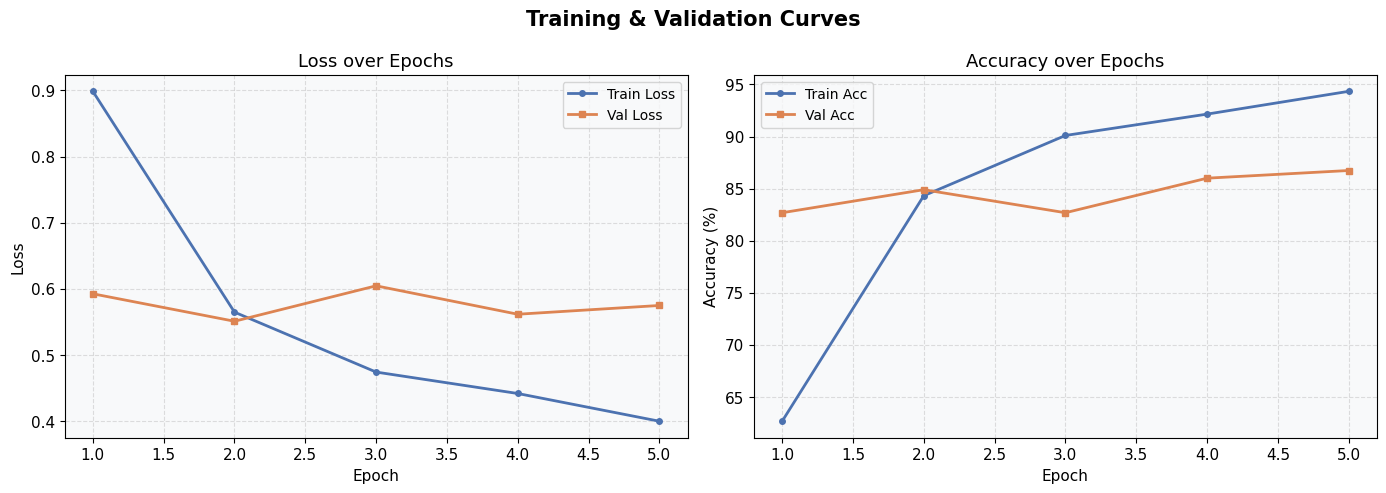

[Saved] plots/01_train_val_curves.png


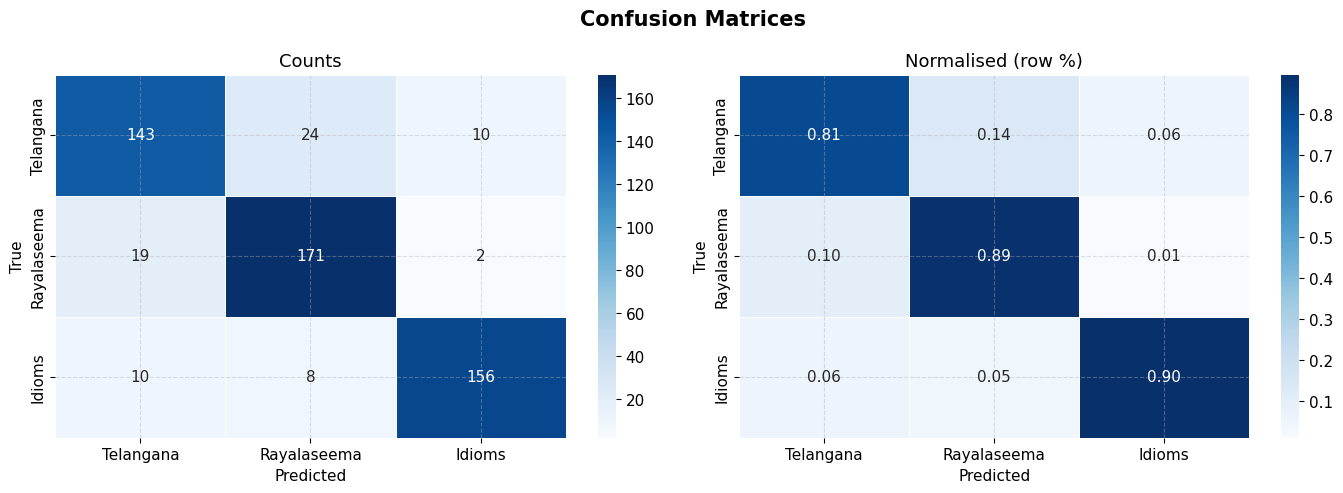

[Saved] plots/02_confusion_matrices.png


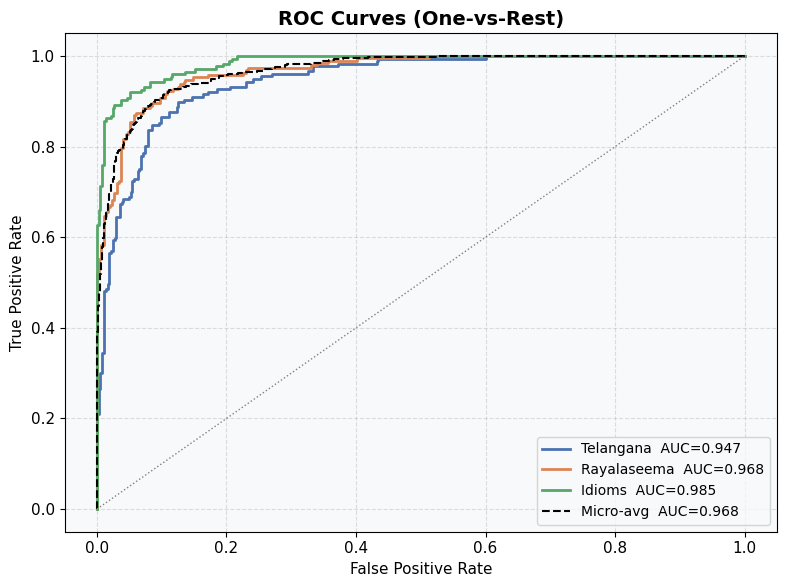

[Saved] plots/03_roc_curves.png


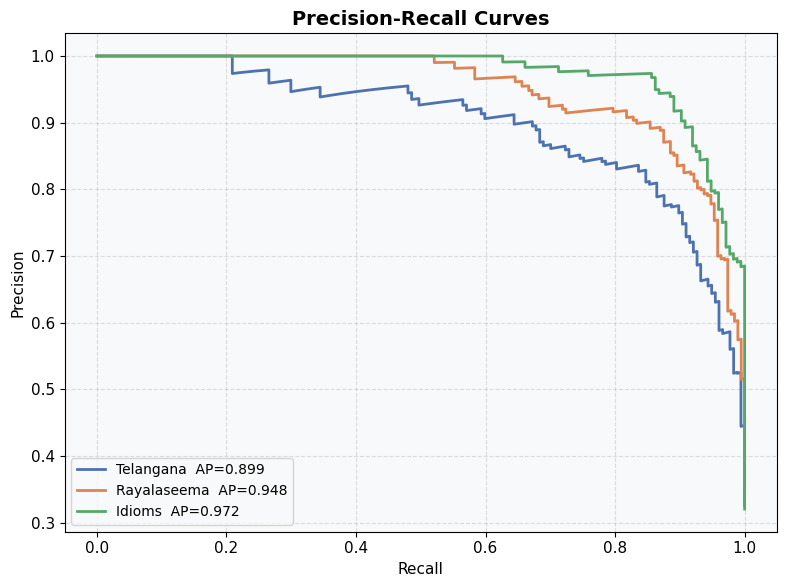

[Saved] plots/04_precision_recall_curves.png


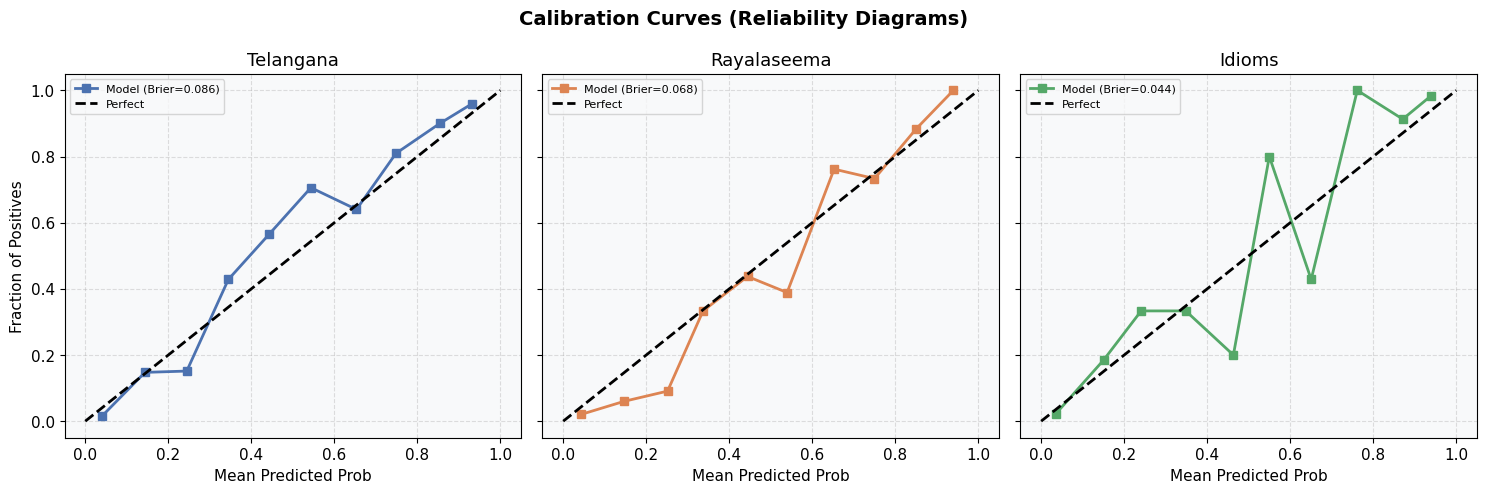

[Saved] plots/05_calibration_curves.png

  STATISTICAL ANALYSIS (bootstrap, n=1000, single split)

  Accuracy  : 86.56%   95% CI [83.79%, 89.32%]
  Macro-F1  : 0.8659   95% CI [0.8373, 0.8936]


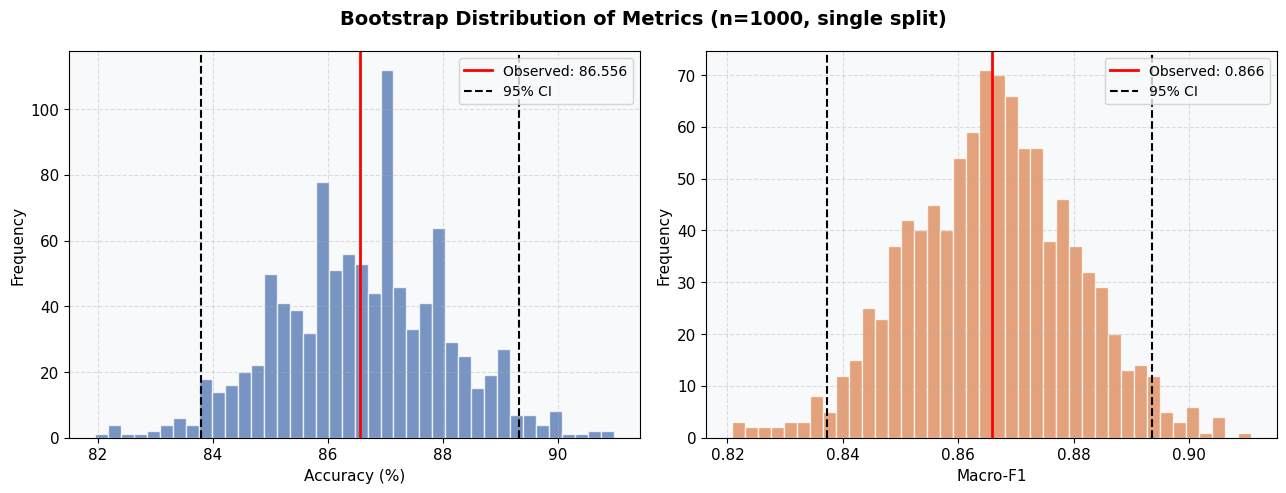

[Saved] plots/06_bootstrap_statistical_analysis.png

  ABLATION STUDY (mBART - freeze depth / dropout)

  > Baseline (freeze=8, drop=0.2) ...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

[transformers] MBartModel LOAD REPORT from: facebook/mbart-large-50-many-to-many-mmt
Key               | Status     |  | 
------------------+------------+--+-
final_logits_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Val=87.11%  Test=90.06%  MacroF1=0.9012  Trainable=50,915,331

  > Freeze=10 (fewer trainable) ...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

...

[transformers] MBartModel LOAD REPORT from: facebook/mbart-large-50-many-to-many-mmt
Key               | Status     |  | 
------------------+------------+--+-
final_logits_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Val=87.66%  Test=88.21%  MacroF1=0.8820  Trainable=76,107,779

  > No Dropout (0.0) ...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

[transformers] MBartModel LOAD REPORT from: facebook/mbart-large-50-many-to-many-mmt
Key               | Status     |  | 
------------------+------------+--+-
final_logits_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Val=88.77%  Test=89.87%  MacroF1=0.8991  Trainable=50,915,331

                       Config   Val Acc  Test Acc  Macro-F1  Trainable Params
Baseline (freeze=8, drop=0.2) 87.108656 90.055249  0.901190          50915331
  Freeze=10 (fewer trainable) 87.476980 88.950276  0.889315          25722883
    Freeze=6 (more trainable) 87.661142 88.213628  0.882050          76107779
             No Dropout (0.0) 88.766114 89.871087  0.899050          50915331


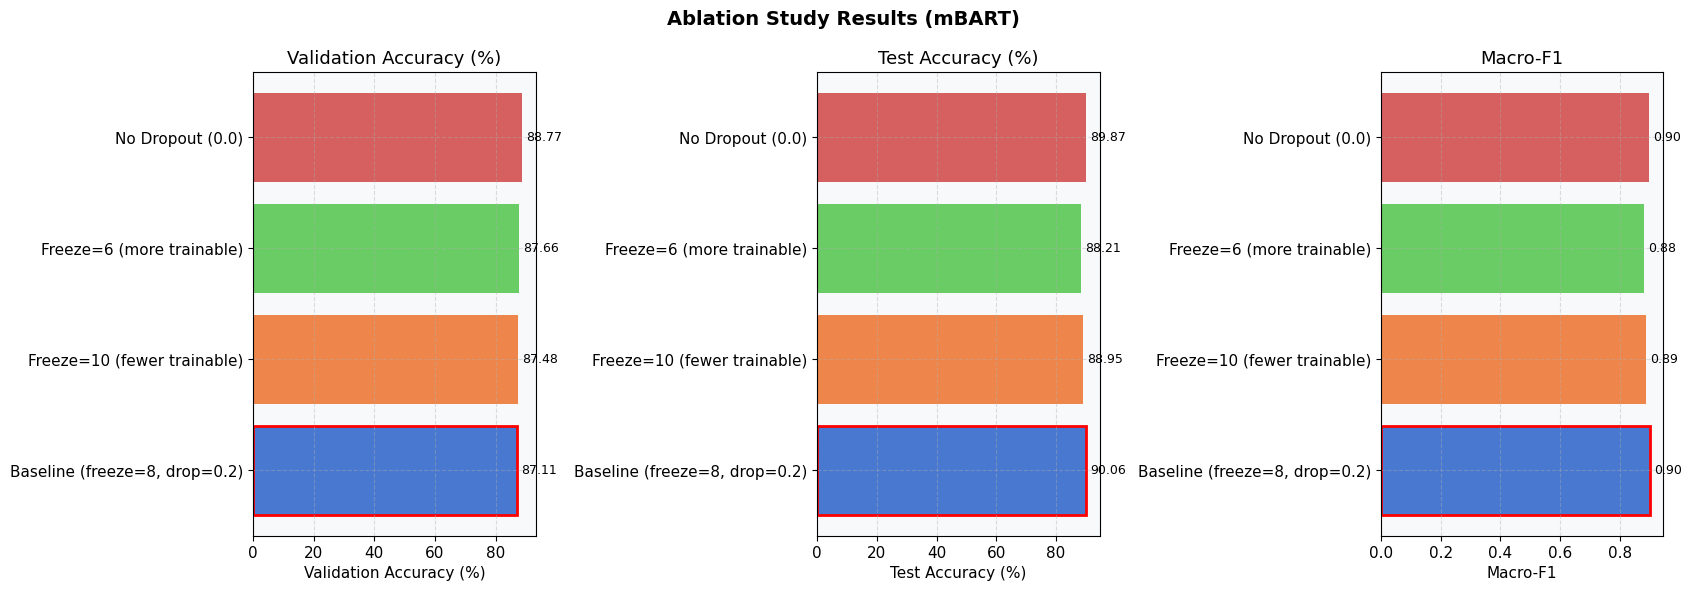

[Saved] plots/07_ablation_study.png

  ROBUSTNESS ANALYSIS
  Baseline accuracy: 86.56%
  Token Drop p=0.1: 81.95%
  Token Drop p=0.2: 79.37%
  Token Drop p=0.4: 73.11%
  Char Noise p=0.1: 75.87%
  Char Noise p=0.2: 62.25%
  Char Noise p=0.4: 45.86%
  Truncation k=0.75: 46.41%
  Truncation k=0.5: 41.80%
  Truncation k=0.25: 47.70%


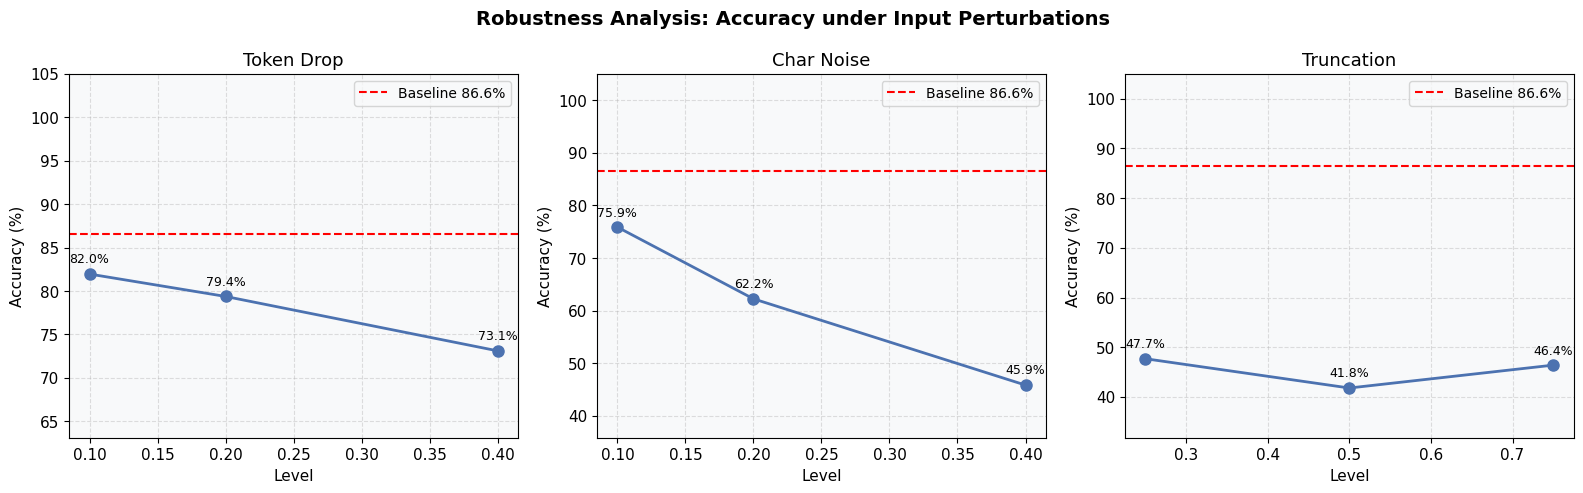

[Saved] plots/08_robustness_analysis.png


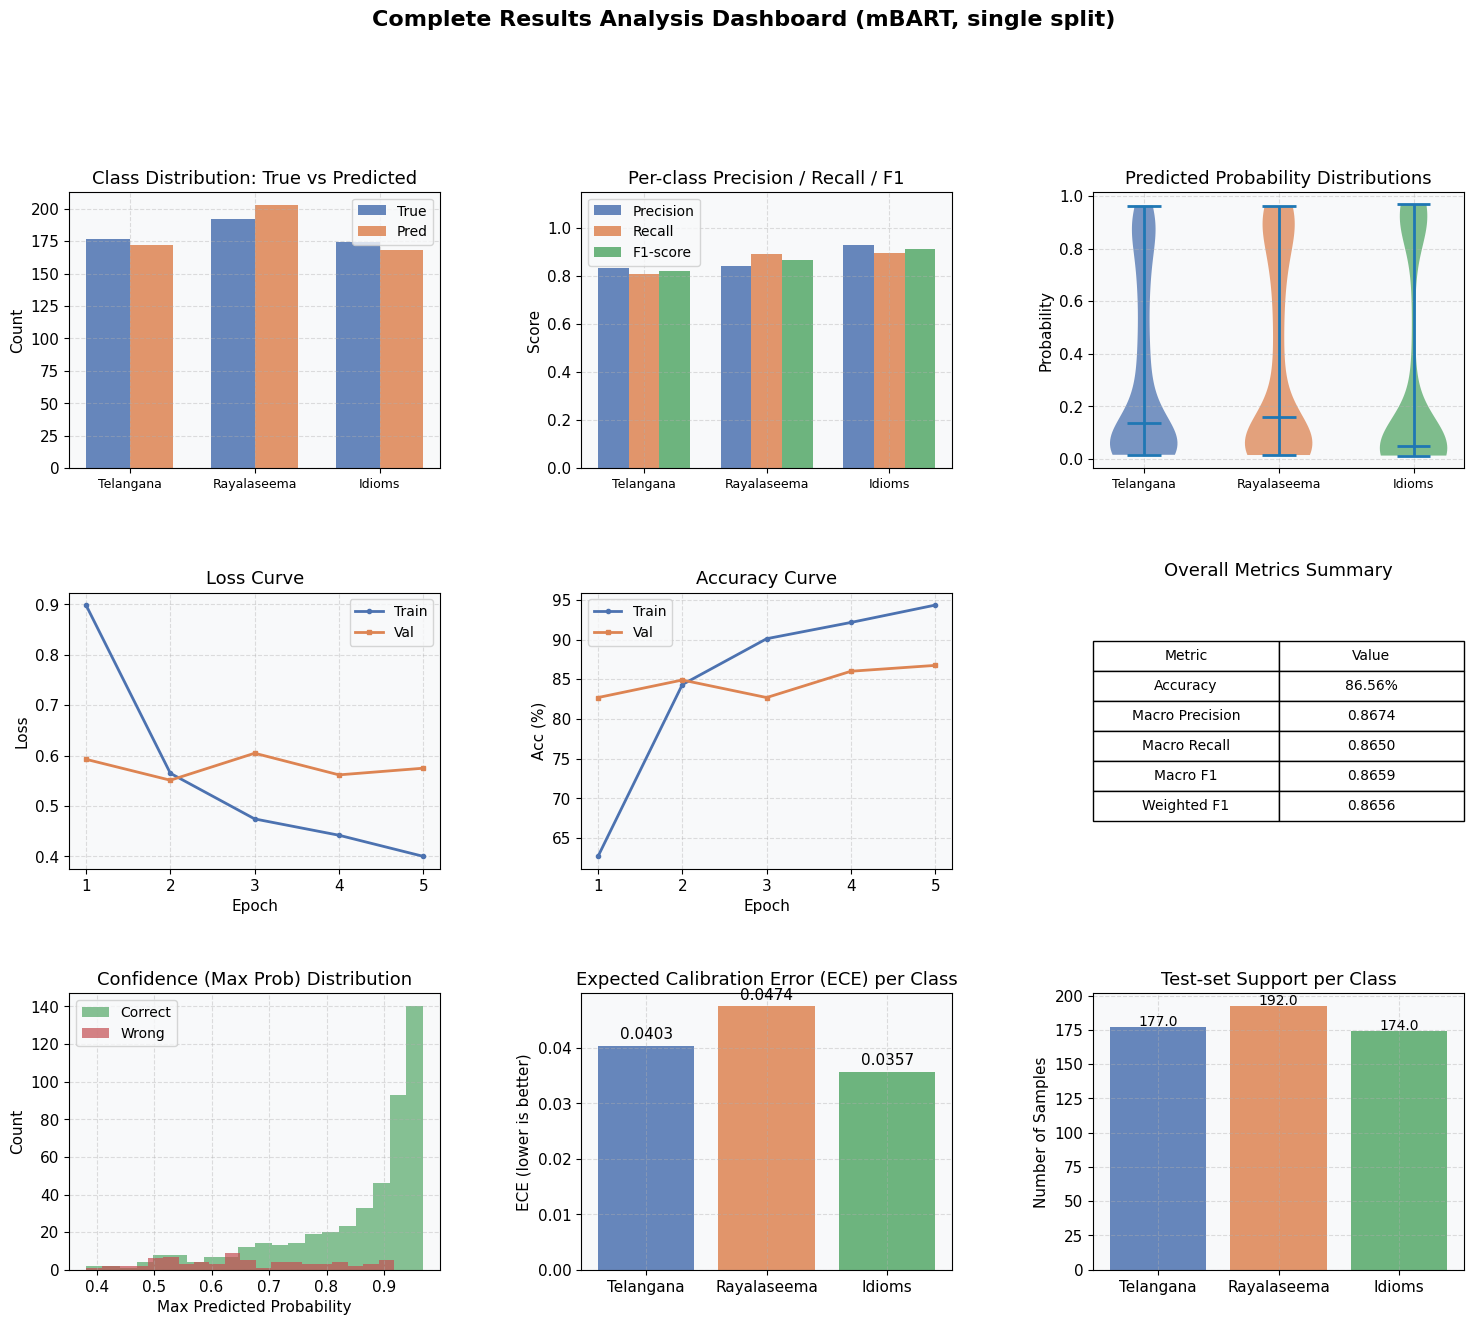

[Saved] plots/09_complete_results_dashboard.png

All plots saved to 'plots/'
Saved: best_mbart_classifier.pt
Done!

-- Demo inference ------------------------------------

Text  : మీరు ఎక్కడ నుండి వచ్చారు
  Telangana      : 17.1%
  Rayalaseema    : 45.4%
  Idioms         : 37.5%
Prediction -> Rayalaseema


In [ ]:
"""
mBART-based Text Classifier — Fine-tuned from Pretrained Weights (v4)
Dataset: Telugu Dialect / Idiom Classification
  Rows 1-2084    -> Telangana   (label 0)
  Rows 2085-4215 -> Rayalaseema (label 1)
  Rows 4216-6011 -> Idioms      (label 2)

CHANGES FROM v3 (from-scratch transformer):
  - Replaces SentenceTokenizer + TransformerClassifier with a pretrained
    mBART-50 encoder ("facebook/mbart-large-50-many-to-many-mmt", which
    covers Telugu as te_IN) + a small mean-pooling classification head.
  - PARTIAL FREEZING: embeddings + the first FREEZE_ENCODER_LAYERS encoder
    layers are frozen; only the top few encoder layers + the new
    classifier head are trainable. Full fine-tuning of a 610M-param model
    on ~5,400 rows would overfit almost immediately and be far slower -
    freezing most of the network is the standard approach for small
    downstream datasets.
  - Fine-tuning LR is much lower than the from-scratch run (2e-5 vs 3e-4)
    and epochs/patience are reduced, since pretrained models converge
    (and overfit) much faster than models trained from scratch.
  - DATA PATH updated to "/content/classification model obj 4.xlsx".
  - K-fold CV is now GATED behind RUN_KFOLD (default False): it means K
    full mBART fine-tuning runs, which is very expensive. Get the main
    single-split run working first, then flip RUN_KFOLD=True once you
    have GPU time to spare. Ablation is trimmed to freeze-depth/dropout
    configs relevant to a pretrained model (not architecture depth,
    since that's now fixed by the pretrained checkpoint).

Requires (Colab):
  !pip install transformers sentencepiece --quiet
"""

# ─────────────────────────────────────────────
# 1. IMPORTS
# ─────────────────────────────────────────────
import os
import re
import math
import random
import warnings
import unicodedata
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
    average_precision_score, brier_score_loss,
    f1_score, accuracy_score
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import AutoTokenizer, MBartModel

import matplotlib
try:
    from IPython import get_ipython
    _IN_NOTEBOOK = get_ipython() is not None
except Exception:
    _IN_NOTEBOOK = False
if not _IN_NOTEBOOK:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 2. REPRODUCIBILITY
# ─────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ─────────────────────────────────────────────
# 3. CONFIGURATION
# ─────────────────────────────────────────────
EXCEL_FILE  = "/classification model obj 4.xlsx"   # <- updated path
TEXT_COL    = None

NUM_CLASSES = 3
MIN_TOKENS  = 2

# mBART settings
MBART_MODEL_NAME      = "facebook/mbart-large-50-many-to-many-mmt"
MBART_LANG_CODE       = "te_IN"          # Telugu
MAX_SEQ_LEN           = 64               # shorter than the from-scratch run - mBART is much heavier per token
FREEZE_ENCODER_LAYERS = 8                # freeze embeddings + first 8 of 12 encoder layers
DROPOUT               = 0.2
BATCH_SIZE            = 16               # smaller batch - mBART is memory-hungry
EPOCHS                = 10               # pretrained models converge/overfit much faster than from-scratch
LR                    = 2e-5             # standard fine-tuning LR, NOT the 3e-4 used for from-scratch training
WEIGHT_DECAY          = 0.01
PATIENCE              = 3
TRAIN_TOKEN_DROPOUT   = 0.05

# Which heavy analyses to run (see module docstring)
RUN_KFOLD      = False     # K full mBART fine-tunes - expensive, opt in once main run looks good
RUN_ABLATION   = True      # trimmed to freeze-depth / dropout configs, still several fine-tunes
RUN_ROBUSTNESS = True      # inference-only on the already-trained model - cheap
K_FOLDS        = 5

ID2LABEL = {0: "Telangana", 1: "Rayalaseema", 2: "Idioms"}
COLORS   = ["#4C72B0", "#DD8452", "#55A868"]

PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# ─────────────────────────────────────────────
# 4. PLOT STYLE HELPER
# ─────────────────────────────────────────────
def set_style():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor"  : "#F8F9FA",
        "axes.grid"       : True,
        "grid.alpha"      : 0.4,
        "grid.linestyle"  : "--",
        "font.size"       : 11,
        "axes.titlesize"  : 13,
        "axes.labelsize"  : 11,
        "legend.fontsize" : 10,
        "lines.linewidth" : 2,
    })

set_style()

def save_fig(name: str):
    path = os.path.join(PLOT_DIR, f"{name}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    if _IN_NOTEBOOK:
        plt.show()
    plt.close()
    print(f"[Saved] {path}")

# ─────────────────────────────────────────────
# 5. DATA LOADING + CLEANING / DEDUP
# ─────────────────────────────────────────────
def _clean_text(t: str) -> str:
    t = unicodedata.normalize("NFC", str(t))
    t = t.strip().lower()
    t = re.sub(r"[^\u0C00-\u0C7Fa-z0-9\s\u0964,.!?'-]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

def clean_and_dedupe(df: pd.DataFrame) -> pd.DataFrame:
    orig_n = len(df)
    df = df.copy()
    df["text"] = df["text"].apply(_clean_text)

    df = df[df["text"].str.len() > 0]
    df = df[df["text"].str.split().str.len() >= MIN_TOKENS]
    after_empty = len(df)

    before_dupe = len(df)
    df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
    exact_dupes_removed = before_dupe - len(df)

    dupe_mask   = df.duplicated(subset=["text"], keep=False)
    conflict_ct = df[dupe_mask].groupby("text")["label"].nunique()
    conflict_texts = set(conflict_ct[conflict_ct > 1].index)
    before_conflict = len(df)
    df = df[~df["text"].isin(conflict_texts)].reset_index(drop=True)
    conflicts_removed = before_conflict - len(df)

    print("\n── Data cleaning report ──────────────────────────")
    print(f"  Original rows            : {orig_n}")
    print(f"  Removed empty/too-short  : {orig_n - after_empty}")
    print(f"  Removed exact duplicates : {exact_dupes_removed}")
    print(f"  Removed label-conflicts  : {conflicts_removed}  (same text, different label)")
    print(f"  Final rows               : {len(df)}")
    print(f"  Final class distribution : {dict(Counter(df['label'].tolist()))}")
    print("────────────────────────────────────────────────────")
    return df

def load_data(path: str) -> pd.DataFrame:
    print(f"\nLoading data from: {path}")
    df = pd.read_excel(path, header=None)
    print(f"  Raw shape: {df.shape}")

    text_col = TEXT_COL
    if text_col is None:
        best_col, best_len = None, 0
        for c in df.columns:
            avg = df[c].astype(str).str.len().mean()
            if avg > best_len:
                best_len, best_col = avg, c
        text_col = best_col
        print(f"  Auto-selected text column: {text_col}")

    n = len(df)
    labels = []
    for i in range(n):
        row_num = i + 1
        if   1    <= row_num <= 2084: labels.append(0)
        elif 2085 <= row_num <= 4215: labels.append(1)
        elif 4216 <= row_num <= 6011: labels.append(2)
        else:                         labels.append(-1)

    df["label"] = labels
    df["text"]  = df[text_col].astype(str)
    df = df[df["label"] != -1].reset_index(drop=True)
    df = df[["text", "label"]]

    df = clean_and_dedupe(df)
    return df

# ─────────────────────────────────────────────
# 6. mBART TOKENIZER + DATASETS
# ─────────────────────────────────────────────
def load_mbart_tokenizer():
    tok = AutoTokenizer.from_pretrained(MBART_MODEL_NAME)
    tok.src_lang = MBART_LANG_CODE
    return tok

def _word_dropout(text: str, p: float, unk: str) -> str:
    if p <= 0:
        return text
    words = text.split()
    words = [w if random.random() > p else unk for w in words]
    return " ".join(words)

class MBartTextDataset(Dataset):
    """Static, pre-tokenized dataset - use for val/test (deterministic)."""
    def __init__(self, texts, labels, tokenizer, max_len=MAX_SEQ_LEN):
        enc = tokenizer(texts, truncation=True, padding="max_length",
                         max_length=max_len, return_tensors="pt")
        self.input_ids      = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels         = labels

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.input_ids[idx],
            self.attention_mask[idx],
            torch.tensor(self.labels[idx], dtype=torch.long),
        )

class MBartAugmentedTrainDataset(Dataset):
    """Re-tokenizes on the fly with light word dropout - TRAIN only."""
    def __init__(self, texts, labels, tokenizer, max_len=MAX_SEQ_LEN, token_dropout=TRAIN_TOKEN_DROPOUT):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len
        self.p         = token_dropout
        self.unk       = tokenizer.unk_token or "<unk>"

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        text = _word_dropout(self.texts[idx], self.p, self.unk)
        enc = self.tokenizer(text, truncation=True, padding="max_length",
                              max_length=self.max_len, return_tensors="pt")
        return (
            enc["input_ids"].squeeze(0),
            enc["attention_mask"].squeeze(0),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )

def make_weighted_sampler(labels):
    counts = Counter(labels)
    class_w = {c: 1.0 / counts[c] for c in counts}
    sample_w = [class_w[l] for l in labels]
    return WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)

# ─────────────────────────────────────────────
# 7. MODEL: PARTIALLY-FROZEN mBART ENCODER + CLASSIFIER
# ─────────────────────────────────────────────
class MBartClassifier(nn.Module):
    def __init__(self, mbart_name=MBART_MODEL_NAME, num_classes=NUM_CLASSES,
                 dropout=DROPOUT, freeze_layers=FREEZE_ENCODER_LAYERS):
        super().__init__()
        backbone = MBartModel.from_pretrained(mbart_name)
        self.encoder = backbone.get_encoder()
        hidden = backbone.config.d_model

        for p in self.encoder.embed_tokens.parameters():
            p.requires_grad = False
        if hasattr(self.encoder, "embed_positions"):
            for p in self.encoder.embed_positions.parameters():
                p.requires_grad = False
        for i, layer in enumerate(self.encoder.layers):
            if i < freeze_layers:
                for p in layer.parameters():
                    p.requires_grad = False

        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden // 2, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        h = out.last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (h * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        pooled = self.dropout(pooled)
        return self.classifier(pooled)

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel parameters: {total:,}  |  Trainable: {train:,}  ({100*train/total:.1f}%)")

# ─────────────────────────────────────────────
# 8. TRAINING UTILITIES
# ─────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, scheduler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for ids, mask, labels in loader:
        ids, mask, labels = ids.to(DEVICE), mask.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(ids, mask)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item() * ids.size(0)
        correct    += (logits.argmax(-1) == labels).sum().item()
        total      += ids.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, return_probs=False):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for ids, mask, labels in loader:
        ids, mask, labels = ids.to(DEVICE), mask.to(DEVICE), labels.to(DEVICE)
        logits = model(ids, mask)
        loss = criterion(logits, labels)
        total_loss += loss.item() * ids.size(0)
        probs  = torch.softmax(logits, -1)
        preds  = probs.argmax(-1)
        correct += (preds == labels).sum().item()
        total   += ids.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())
    if return_probs:
        return total_loss/total, correct/total, all_preds, all_labels, all_probs
    return total_loss/total, correct/total, all_preds, all_labels

def build_optimizer_scheduler(model, train_dl, epochs, lr=LR, weight_decay=WEIGHT_DECAY):
    trainable = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = optim.AdamW(trainable, lr=lr, weight_decay=weight_decay)
    total_steps  = max(1, len(train_dl) * epochs)
    warmup_steps = max(1, total_steps // 10)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * prog)))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    return optimizer, scheduler

def train_with_early_stopping(model, train_dl, val_dl, criterion, epochs=EPOCHS,
                               patience=PATIENCE, ckpt_path=None, verbose=True):
    optimizer, scheduler = build_optimizer_scheduler(model, train_dl, epochs)
    best_val_loss = float("inf")
    best_val_acc  = 0.0
    best_state    = None
    patience_cnt  = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    if verbose:
        print("="*65)
        print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
        print("="*65)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_dl, criterion, optimizer, scheduler)
        va_loss, va_acc, _, _ = evaluate(model, val_dl, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(f"{epoch:>6}  {tr_loss:>10.4f}  {tr_acc*100:>8.2f}%  {va_loss:>8.4f}  {va_acc*100:>6.2f}%")

        if va_loss < best_val_loss - 1e-4:
            best_val_loss = va_loss
            best_val_acc  = va_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
            if ckpt_path:
                torch.save(model.state_dict(), ckpt_path)
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                if verbose:
                    print(f"\nEarly stopping at epoch {epoch}. "
                          f"Best val loss: {best_val_loss:.4f} (val acc {best_val_acc*100:.2f}%)")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_val_acc, best_val_loss

# ─────────────────────────────────────────────
# 9. K-FOLD CV (gated by RUN_KFOLD - K full mBART fine-tunes)
# ─────────────────────────────────────────────
def run_stratified_kfold(texts, labels, tokenizer, k=K_FOLDS, epochs=EPOCHS, patience=PATIENCE):
    print("\n" + "="*60)
    print(f"  STRATIFIED {k}-FOLD CROSS-VALIDATION (mBART)")
    print("="*60)

    texts_arr  = np.array(texts, dtype=object)
    labels_arr = np.array(labels)
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    fold_rows = []
    for fold_idx, (trainval_idx, test_idx) in enumerate(skf.split(texts_arr, labels_arr), start=1):
        print(f"\n  --- Fold {fold_idx}/{k} ---")
        X_trainval = texts_arr[trainval_idx].tolist()
        y_trainval = labels_arr[trainval_idx].tolist()
        X_test_f   = texts_arr[test_idx].tolist()
        y_test_f   = labels_arr[test_idx].tolist()

        X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(
            X_trainval, y_trainval, test_size=0.12, random_state=SEED, stratify=y_trainval)

        train_ds = MBartAugmentedTrainDataset(X_train_f, y_train_f, tokenizer)
        val_ds   = MBartTextDataset(X_val_f,  y_val_f,  tokenizer)
        test_ds  = MBartTextDataset(X_test_f, y_test_f, tokenizer)

        sampler  = make_weighted_sampler(y_train_f)
        train_dl = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0)
        val_dl   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0)
        test_dl  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0)

        model = MBartClassifier().to(DEVICE)
        model, _, best_va, _ = train_with_early_stopping(
            model, train_dl, val_dl, criterion, epochs=epochs, patience=patience, verbose=False)

        _, te_acc, preds, gold = evaluate(model, test_dl, criterion)
        f1_macro = f1_score(gold, preds, average="macro", zero_division=0)
        print(f"    Val Acc={best_va*100:.2f}%  Test Acc={te_acc*100:.2f}%  Macro-F1={f1_macro:.4f}")
        fold_rows.append({"Fold": fold_idx, "Val Acc": best_va*100, "Test Acc": te_acc*100, "Macro-F1": f1_macro})

        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    df_kfold = pd.DataFrame(fold_rows)
    print("\n" + df_kfold.to_string(index=False))
    acc_mean, acc_std = df_kfold["Test Acc"].mean(), df_kfold["Test Acc"].std()
    f1_mean,  f1_std  = df_kfold["Macro-F1"].mean(), df_kfold["Macro-F1"].std()
    print(f"\n  >>> {k}-Fold Test Accuracy : {acc_mean:.2f}% +/- {acc_std:.2f}%  <<<")
    print(f"  >>> {k}-Fold Macro-F1      : {f1_mean:.4f} +/- {f1_std:.4f}  <<<")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"{k}-Fold Cross-Validation Results (mBART)", fontsize=14, fontweight="bold")
    ax = axes[0]
    bars = ax.bar(df_kfold["Fold"].astype(str), df_kfold["Test Acc"], color="#4C72B0", alpha=0.85)
    ax.axhline(acc_mean, color="red", ls="--", lw=1.5, label=f"Mean={acc_mean:.2f}%")
    ax.bar_label(bars, fmt="%.1f", padding=3)
    ax.set_xlabel("Fold"); ax.set_ylabel("Test Accuracy (%)"); ax.set_title("Per-fold Test Accuracy"); ax.legend()
    ax = axes[1]
    bars = ax.bar(df_kfold["Fold"].astype(str), df_kfold["Macro-F1"], color="#DD8452", alpha=0.85)
    ax.axhline(f1_mean, color="red", ls="--", lw=1.5, label=f"Mean={f1_mean:.3f}")
    ax.bar_label(bars, fmt="%.3f", padding=3)
    ax.set_xlabel("Fold"); ax.set_ylabel("Macro-F1"); ax.set_title("Per-fold Macro-F1"); ax.legend()
    plt.tight_layout()
    save_fig("00_kfold_cross_validation")

    return df_kfold, acc_mean, acc_std, f1_mean, f1_std

# ─────────────────────────────────────────────
# 10. ANALYSIS / PLOTTING (unchanged in spirit from v3)
# ─────────────────────────────────────────────
def plot_train_val_curves(history: dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training & Validation Curves", fontsize=15, fontweight="bold")
    epochs = range(1, len(history["train_loss"]) + 1)
    ax = axes[0]
    ax.plot(epochs, history["train_loss"], color="#4C72B0", label="Train Loss", marker="o", ms=4)
    ax.plot(epochs, history["val_loss"],   color="#DD8452", label="Val Loss",   marker="s", ms=4)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title("Loss over Epochs"); ax.legend()
    ax = axes[1]
    ax.plot(epochs, [a*100 for a in history["train_acc"]], color="#4C72B0", label="Train Acc", marker="o", ms=4)
    ax.plot(epochs, [a*100 for a in history["val_acc"]],   color="#DD8452", label="Val Acc",   marker="s", ms=4)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)"); ax.set_title("Accuracy over Epochs"); ax.legend()
    plt.tight_layout()
    save_fig("01_train_val_curves")

def plot_confusion_matrix(y_true, y_pred):
    cm    = confusion_matrix(y_true, y_pred)
    cm_n  = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Confusion Matrices", fontsize=15, fontweight="bold")
    for ax, data, title, fmt in zip(axes, [cm, cm_n], ["Counts", "Normalised (row %)"], ["d", ".2f"]):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues", xticklabels=labels, yticklabels=labels, linewidths=0.5, ax=ax)
        ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout()
    save_fig("02_confusion_matrices")

def plot_roc_curves(y_true, y_probs):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    y_arr = np.array(y_probs)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title("ROC Curves (One-vs-Rest)", fontsize=14, fontweight="bold")
    for i, (label, color) in enumerate(zip(labels, COLORS)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_arr[:, i])
        ax.plot(fpr, tpr, color=color, label=f"{label}  AUC={auc(fpr, tpr):.3f}")
    fpr_m, tpr_m, _ = roc_curve(y_bin.ravel(), y_arr.ravel())
    ax.plot(fpr_m, tpr_m, "k--", label=f"Micro-avg  AUC={auc(fpr_m,tpr_m):.3f}", lw=1.5)
    ax.plot([0,1],[0,1],"grey", ls=":", lw=1)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate"); ax.legend(loc="lower right")
    plt.tight_layout()
    save_fig("03_roc_curves")

def plot_precision_recall_curves(y_true, y_probs):
    y_bin  = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    y_arr  = np.array(y_probs)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title("Precision-Recall Curves", fontsize=14, fontweight="bold")
    for i, (label, color) in enumerate(zip(labels, COLORS)):
        prec, rec, _ = precision_recall_curve(y_bin[:, i], y_arr[:, i])
        ap = average_precision_score(y_bin[:, i], y_arr[:, i])
        ax.plot(rec, prec, color=color, label=f"{label}  AP={ap:.3f}")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.legend()
    plt.tight_layout()
    save_fig("04_precision_recall_curves")

def plot_calibration_curves(y_true, y_probs):
    y_bin  = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    y_arr  = np.array(y_probs)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(15, 5), sharey=True)
    fig.suptitle("Calibration Curves (Reliability Diagrams)", fontsize=14, fontweight="bold")
    for i, (ax, label, color) in enumerate(zip(axes, labels, COLORS)):
        prob_true, prob_pred = calibration_curve(y_bin[:, i], y_arr[:, i], n_bins=10)
        brier = brier_score_loss(y_bin[:, i], y_arr[:, i])
        ax.plot(prob_pred, prob_true, "s-", color=color, label=f"Model (Brier={brier:.3f})")
        ax.plot([0,1],[0,1],"k--", label="Perfect")
        ax.set_title(label); ax.set_xlabel("Mean Predicted Prob")
        if i == 0: ax.set_ylabel("Fraction of Positives")
        ax.legend(fontsize=8)
    plt.tight_layout()
    save_fig("05_calibration_curves")

def statistical_analysis(y_true, y_pred, y_probs, n_bootstrap=1000):
    print("\n" + "="*60)
    print("  STATISTICAL ANALYSIS (bootstrap, n=1000, single split)")
    print("="*60)
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    acc_boot, f1_boot = [], []
    rng = np.random.RandomState(SEED)
    for _ in range(n_bootstrap):
        idx = rng.randint(0, len(y_true), len(y_true))
        acc_boot.append(accuracy_score(y_true[idx], y_pred[idx]))
        f1_boot.append(f1_score(y_true[idx], y_pred[idx], average="macro", zero_division=0))
    acc_boot, f1_boot = np.array(acc_boot), np.array(f1_boot)
    def ci95(arr): return np.percentile(arr, [2.5, 97.5])
    obs_acc, obs_f1 = accuracy_score(y_true, y_pred), f1_score(y_true, y_pred, average="macro", zero_division=0)
    print(f"\n  Accuracy  : {obs_acc*100:.2f}%   95% CI [{ci95(acc_boot)[0]*100:.2f}%, {ci95(acc_boot)[1]*100:.2f}%]")
    print(f"  Macro-F1  : {obs_f1:.4f}   95% CI [{ci95(f1_boot)[0]:.4f}, {ci95(f1_boot)[1]:.4f}]")
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Bootstrap Distribution of Metrics (n=1000, single split)", fontsize=14, fontweight="bold")
    for ax, data, title, obs, color in zip(axes, [acc_boot*100, f1_boot], ["Accuracy (%)", "Macro-F1"],
                                            [obs_acc*100, obs_f1], ["#4C72B0", "#DD8452"]):
        ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor="white")
        ax.axvline(obs, color="red", ls="-", lw=2, label=f"Observed: {obs:.3f}")
        ax.axvline(ci95(data)[0], color="black", ls="--", lw=1.5, label="95% CI")
        ax.axvline(ci95(data)[1], color="black", ls="--", lw=1.5)
        ax.set_xlabel(title); ax.set_ylabel("Frequency"); ax.legend()
    plt.tight_layout()
    save_fig("06_bootstrap_statistical_analysis")

def ablation_study(X_train, X_val, X_test, y_train, y_val, y_test, tokenizer):
    """Trimmed vs v3: architecture depth is now fixed by the pretrained
    checkpoint, so ablation varies the things that actually matter for a
    fine-tuned pretrained model - how much of it is frozen, and dropout."""
    print("\n" + "="*60)
    print("  ABLATION STUDY (mBART - freeze depth / dropout)")
    print("="*60)

    configs = [
        {"name": "Baseline (freeze=8, drop=0.2)", "freeze": FREEZE_ENCODER_LAYERS, "drop": DROPOUT},
        {"name": "Freeze=10 (fewer trainable)",   "freeze": 10,                    "drop": DROPOUT},
        {"name": "Freeze=6 (more trainable)",     "freeze": 6,                     "drop": DROPOUT},
        {"name": "No Dropout (0.0)",              "freeze": FREEZE_ENCODER_LAYERS, "drop": 0.0},
    ]

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    train_ds = MBartAugmentedTrainDataset(X_train, y_train, tokenizer)
    val_ds   = MBartTextDataset(X_val,  y_val,  tokenizer)
    test_ds  = MBartTextDataset(X_test, y_test, tokenizer)
    sampler  = make_weighted_sampler(y_train)
    train_dl = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0)
    val_dl   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0)
    test_dl  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0)

    results = []
    for cfg in configs:
        print(f"\n  > {cfg['name']} ...")
        model = MBartClassifier(freeze_layers=cfg["freeze"], dropout=cfg["drop"]).to(DEVICE)
        model, _, best_va, _ = train_with_early_stopping(
            model, train_dl, val_dl, criterion, epochs=EPOCHS, patience=PATIENCE, verbose=False)
        _, te_acc, preds, gold = evaluate(model, test_dl, criterion)
        f1 = f1_score(gold, preds, average="macro", zero_division=0)
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"    Val={best_va*100:.2f}%  Test={te_acc*100:.2f}%  MacroF1={f1:.4f}  Trainable={trainable:,}")
        results.append({"Config": cfg["name"], "Val Acc": best_va*100, "Test Acc": te_acc*100,
                        "Macro-F1": f1, "Trainable Params": trainable})
        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    df_abl = pd.DataFrame(results)
    print("\n" + df_abl.to_string(index=False))

    fig, axes = plt.subplots(1, 3, figsize=(17, 6))
    fig.suptitle("Ablation Study Results (mBART)", fontsize=14, fontweight="bold")
    palette = sns.color_palette("muted", len(df_abl))
    for ax, col, title in zip(axes, ["Val Acc", "Test Acc", "Macro-F1"],
                               ["Validation Accuracy (%)", "Test Accuracy (%)", "Macro-F1"]):
        bars = ax.barh(df_abl["Config"], df_abl[col], color=palette)
        ax.set_xlabel(title); ax.set_title(title)
        ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
        for bar, name in zip(bars, df_abl["Config"]):
            if "Baseline" in name:
                bar.set_edgecolor("red"); bar.set_linewidth(2)
    plt.tight_layout()
    save_fig("07_ablation_study")
    return df_abl

def robustness_analysis(model, tokenizer, X_test, y_test):
    print("\n" + "="*60)
    print("  ROBUSTNESS ANALYSIS")
    print("="*60)

    def _perturb_token_drop(texts, p):
        return [_word_dropout(t, p, tokenizer.unk_token or "<unk>") for t in texts]

    def _perturb_char(texts, p):
        def swap_chars(word):
            if len(word) < 2: return word
            w = list(word)
            for i in range(len(w)-1):
                if random.random() < p:
                    w[i], w[i+1] = w[i+1], w[i]
            return "".join(w)
        return [" ".join(swap_chars(w) for w in t.split()) for t in texts]

    def _perturb_trunc(texts, k):
        out = []
        for t in texts:
            words = t.split()
            keep  = max(1, int(len(words) * k))
            out.append(" ".join(words[:keep]))
        return out

    y_arr = np.array(y_test)
    model.eval()

    @torch.no_grad()
    def _accuracy(texts):
        ds = MBartTextDataset(texts, [0]*len(texts), tokenizer)
        loader = DataLoader(ds, BATCH_SIZE, shuffle=False)
        all_preds = []
        for ids, mask, _ in loader:
            ids, mask = ids.to(DEVICE), mask.to(DEVICE)
            all_preds.extend(torch.softmax(model(ids, mask), -1).argmax(-1).cpu().tolist())
        return accuracy_score(y_arr, all_preds) * 100

    rows = []
    baseline_acc = _accuracy(X_test)
    rows.append({"Perturbation": "Baseline (clean)", "Level": "-", "Accuracy": baseline_acc})
    print(f"  Baseline accuracy: {baseline_acc:.2f}%")

    for p in [0.1, 0.2, 0.4]:
        acc = _accuracy(_perturb_token_drop(X_test, p))
        rows.append({"Perturbation": f"Token Drop p={p}", "Level": str(p), "Accuracy": acc})
        print(f"  Token Drop p={p}: {acc:.2f}%")
    for p in [0.1, 0.2, 0.4]:
        acc = _accuracy(_perturb_char(X_test, p))
        rows.append({"Perturbation": f"Char Noise p={p}", "Level": str(p), "Accuracy": acc})
        print(f"  Char Noise p={p}: {acc:.2f}%")
    for k in [0.75, 0.50, 0.25]:
        acc = _accuracy(_perturb_trunc(X_test, k))
        rows.append({"Perturbation": f"Truncate k={k}", "Level": str(k), "Accuracy": acc})
        print(f"  Truncation k={k}: {acc:.2f}%")

    df_rob = pd.DataFrame(rows)
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Robustness Analysis: Accuracy under Input Perturbations", fontsize=14, fontweight="bold")
    groups = [("Token Drop", "Token Drop", [0.1, 0.2, 0.4]),
              ("Char Noise", "Char Noise", [0.1, 0.2, 0.4]),
              ("Truncation", "Truncate",   [0.75, 0.50, 0.25])]
    for ax, (name, prefix, levels) in zip(axes, groups):
        accs = [df_rob.loc[df_rob["Perturbation"].str.startswith(prefix) & df_rob["Level"].eq(str(l)), "Accuracy"].values[0]
                for l in levels]
        ax.axhline(baseline_acc, color="red", ls="--", lw=1.5, label=f"Baseline {baseline_acc:.1f}%")
        ax.plot(levels, accs, "o-", color="#4C72B0", ms=8)
        for l, a in zip(levels, accs):
            ax.annotate(f"{a:.1f}%", (l, a), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
        ax.set_title(name); ax.set_xlabel("Level"); ax.set_ylabel("Accuracy (%)")
        ax.legend(); ax.set_ylim(max(0, min(accs)-10), 105)
    plt.tight_layout()
    save_fig("08_robustness_analysis")
    return df_rob

def plot_complete_results_summary(y_true, y_pred, y_probs, history):
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]
    y_arr  = np.array(y_probs)
    report = classification_report(y_true, y_pred, target_names=labels, output_dict=True, zero_division=0)

    fig = plt.figure(figsize=(18, 14))
    fig.suptitle("Complete Results Analysis Dashboard (mBART, single split)", fontsize=16, fontweight="bold", y=1.01)
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

    ax = fig.add_subplot(gs[0, 0])
    true_counts, pred_counts = Counter(y_true), Counter(y_pred)
    x = np.arange(NUM_CLASSES); w = 0.35
    ax.bar(x - w/2, [true_counts[i] for i in range(NUM_CLASSES)], w, label="True", color="#4C72B0", alpha=0.85)
    ax.bar(x + w/2, [pred_counts[i] for i in range(NUM_CLASSES)], w, label="Pred", color="#DD8452", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title("Class Distribution: True vs Predicted"); ax.set_ylabel("Count"); ax.legend()

    ax = fig.add_subplot(gs[0, 1])
    metrics = ["precision", "recall", "f1-score"]; x = np.arange(NUM_CLASSES); w = 0.25
    pal = ["#4C72B0", "#DD8452", "#55A868"]
    for j, (m, c) in enumerate(zip(metrics, pal)):
        vals = [report[lbl][m] for lbl in labels]
        ax.bar(x + j*w - w, vals, w, label=m.capitalize(), color=c, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title("Per-class Precision / Recall / F1"); ax.set_ylim(0, 1.15); ax.legend(); ax.set_ylabel("Score")

    ax = fig.add_subplot(gs[0, 2])
    parts = ax.violinplot([y_arr[:, i] for i in range(NUM_CLASSES)], positions=range(NUM_CLASSES), showmedians=True)
    for pc, c in zip(parts["bodies"], COLORS):
        pc.set_facecolor(c); pc.set_alpha(0.75)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title("Predicted Probability Distributions"); ax.set_ylabel("Probability")

    epochs = range(1, len(history["train_loss"]) + 1)
    ax = fig.add_subplot(gs[1, 0])
    ax.plot(epochs, history["train_loss"], "#4C72B0", label="Train", marker="o", ms=3)
    ax.plot(epochs, history["val_loss"],   "#DD8452", label="Val",   marker="s", ms=3)
    ax.set_title("Loss Curve"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend()

    ax = fig.add_subplot(gs[1, 1])
    ax.plot(epochs, [a*100 for a in history["train_acc"]], "#4C72B0", label="Train", marker="o", ms=3)
    ax.plot(epochs, [a*100 for a in history["val_acc"]],   "#DD8452", label="Val",   marker="s", ms=3)
    ax.set_title("Accuracy Curve"); ax.set_xlabel("Epoch"); ax.set_ylabel("Acc (%)"); ax.legend()

    ax = fig.add_subplot(gs[1, 2]); ax.axis("off")
    summary_data = [
        ["Metric", "Value"],
        ["Accuracy", f"{accuracy_score(y_true,y_pred)*100:.2f}%"],
        ["Macro Precision", f"{report['macro avg']['precision']:.4f}"],
        ["Macro Recall",    f"{report['macro avg']['recall']:.4f}"],
        ["Macro F1",        f"{report['macro avg']['f1-score']:.4f}"],
        ["Weighted F1",     f"{report['weighted avg']['f1-score']:.4f}"],
    ]
    tbl = ax.table(cellText=summary_data[1:], colLabels=summary_data[0], loc="center", cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.8)
    ax.set_title("Overall Metrics Summary", pad=12)

    ax = fig.add_subplot(gs[2, 0])
    max_probs = y_arr.max(axis=1); correct = (np.array(y_pred) == np.array(y_true))
    ax.hist(max_probs[correct],  bins=20, alpha=0.7, color="#55A868", label="Correct")
    ax.hist(max_probs[~correct], bins=20, alpha=0.7, color="#C44E52", label="Wrong")
    ax.set_title("Confidence (Max Prob) Distribution"); ax.set_xlabel("Max Predicted Probability"); ax.set_ylabel("Count"); ax.legend()

    ax = fig.add_subplot(gs[2, 1])
    n_bins = 10; bin_edges = np.linspace(0, 1, n_bins + 1); ece_vals = []
    for i in range(NUM_CLASSES):
        y_bin_i = (np.array(y_true) == i).astype(int); p_i = y_arr[:, i]; ece = 0.0
        for b in range(n_bins):
            mask = (p_i >= bin_edges[b]) & (p_i < bin_edges[b+1])
            if mask.sum() == 0: continue
            ece += mask.sum() * abs(y_bin_i[mask].mean() - p_i[mask].mean())
        ece_vals.append(ece / len(y_true))
    bars = ax.bar(labels, ece_vals, color=COLORS, alpha=0.85)
    ax.bar_label(bars, fmt="%.4f", padding=3)
    ax.set_title("Expected Calibration Error (ECE) per Class"); ax.set_ylabel("ECE (lower is better)")

    ax = fig.add_subplot(gs[2, 2])
    support = [report[lbl]["support"] for lbl in labels]
    ax.bar(labels, support, color=COLORS, alpha=0.85)
    for j, s in enumerate(support):
        ax.text(j, s + 1, str(s), ha="center", fontsize=10)
    ax.set_title("Test-set Support per Class"); ax.set_ylabel("Number of Samples")

    plt.tight_layout()
    save_fig("09_complete_results_dashboard")

# ─────────────────────────────────────────────
# 11. MAIN
# ─────────────────────────────────────────────
def main():
    df = load_data(EXCEL_FILE)
    texts, labels = df["text"].tolist(), df["label"].tolist()

    print(f"\nLoading tokenizer/model: {MBART_MODEL_NAME}  (lang={MBART_LANG_CODE})")
    tokenizer = load_mbart_tokenizer()

    if RUN_KFOLD:
        df_kfold, kfold_acc_mean, kfold_acc_std, kfold_f1_mean, kfold_f1_std = \
            run_stratified_kfold(texts, labels, tokenizer, k=K_FOLDS, epochs=EPOCHS, patience=PATIENCE)
    else:
        print("\n[RUN_KFOLD=False] Skipping k-fold CV - set RUN_KFOLD=True once the "
              "single-split run below looks good (it means K full mBART fine-tunes).")
        df_kfold = None

    X_train, X_tmp, y_train, y_tmp = train_test_split(
        texts, labels, test_size=0.2, random_state=SEED, stratify=labels)
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp)
    print(f"\nTrain: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
    print(f"Train class dist: {dict(Counter(y_train))}")

    train_ds = MBartAugmentedTrainDataset(X_train, y_train, tokenizer)
    val_ds   = MBartTextDataset(X_val,  y_val,  tokenizer)
    test_ds  = MBartTextDataset(X_test, y_test, tokenizer)

    sampler  = make_weighted_sampler(y_train)
    train_dl = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
    val_dl   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0)
    test_dl  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0)

    model = MBartClassifier().to(DEVICE)
    count_parameters(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_ckpt = "best_mbart_classifier.pt"

    model, history, best_val_acc, best_val_loss = train_with_early_stopping(
        model, train_dl, val_dl, criterion, epochs=EPOCHS, patience=PATIENCE, ckpt_path=best_ckpt, verbose=True)

    te_loss, te_acc, preds, gold, probs = evaluate(model, test_dl, criterion, return_probs=True)

    print("\n" + "="*65)
    print(f"SINGLE-SPLIT TEST  Loss: {te_loss:.4f}   Acc: {te_acc*100:.2f}%")
    if df_kfold is not None:
        print(f"K-FOLD ({K_FOLDS}-fold) TEST Acc: mean +/- std reported above  <- report that one")
    print("="*65)
    print("\nClassification Report (single split):")
    print(classification_report(gold, preds, target_names=[ID2LABEL[i] for i in range(NUM_CLASSES)]))
    print("Confusion Matrix (rows=true, cols=pred):")
    print(confusion_matrix(gold, preds))
    print(f"\nTrain/Test accuracy gap check (smaller is better): "
          f"{abs(history['train_acc'][-1]*100 - te_acc*100):.2f} pts")

    print("\n\n" + "#"*65)
    print(f"  GENERATING ALL ANALYSIS PLOTS  ->  saved to '{PLOT_DIR}/'")
    print("#"*65)

    plot_train_val_curves(history)
    plot_confusion_matrix(gold, preds)
    plot_roc_curves(gold, probs)
    plot_precision_recall_curves(gold, probs)
    plot_calibration_curves(gold, probs)
    statistical_analysis(gold, preds, probs)

    if RUN_ABLATION:
        df_ablation = ablation_study(X_train, X_val, X_test, y_train, y_val, y_test, tokenizer)
    if RUN_ROBUSTNESS:
        df_robustness = robustness_analysis(model, tokenizer, X_test, y_test)

    plot_complete_results_summary(gold, preds, probs, history)

    if df_kfold is not None:
        df_kfold.to_csv("kfold_results.csv", index=False)

    print(f"\nAll plots saved to '{PLOT_DIR}/'")
    print(f"Saved: {best_ckpt}")
    print("Done!")

    return model, tokenizer

# ─────────────────────────────────────────────
# 12. SINGLE-SENTENCE INFERENCE
# ─────────────────────────────────────────────
def predict(text: str, model: MBartClassifier, tokenizer) -> str:
    model.eval()
    enc = tokenizer(text, truncation=True, padding="max_length", max_length=MAX_SEQ_LEN, return_tensors="pt")
    ids, mask = enc["input_ids"].to(DEVICE), enc["attention_mask"].to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model(ids, mask), -1)[0]
        pred  = probs.argmax().item()
    label = ID2LABEL[pred]
    print(f"\nText  : {text}")
    for i, p in enumerate(probs.tolist()):
        print(f"  {ID2LABEL[i]:15s}: {p*100:.1f}%")
    print(f"Prediction -> {label}")
    return label

# ─────────────────────────────────────────────
# 13. ENTRY POINT
# ─────────────────────────────────────────────
if __name__ == "__main__":
    trained_model, tok = main()

    print("\n-- Demo inference ------------------------------------")
    sample = "మీరు ఎక్కడ నుండి వచ్చారు"
    predict(sample, trained_model, tok)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Using device: cuda

Loading data from: /content/classification model obj 4.xlsx
  Raw shape: (6011, 2)
  Auto-selected text column: 0

── Data cleaning report ──────────────────────────
  Original rows            : 6011
  Removed empty/too-short  : 54
  Removed exact duplicates : 527
  Removed label-conflicts  : 0  (same text, different label)
  Final rows               : 5430
  Final class distribution : {0: 1769, 1: 1921, 2: 1740}
────────────────────────────────────────────────────

Loading tokenizer/model: facebook/mbart-large-50-many-to-many-mmt  (lang=te_IN)

[RUN_KFOLD=False] Skipping k-fold CV - set RUN_KFOLD=True once the single-split run below looks good (it means K full mBART fine-tunes).

Train: 4344  Val: 543  Test: 543
Train class dist: {1: 1537, 2: 1392, 0: 1415}


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

[transformers] MBartModel LOAD REPORT from: facebook/mbart-large-50-many-to-many-mmt
Key               | Status     |  | 
------------------+------------+--+-
final_logits_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model parameters: 408,791,043  |  Trainable: 25,722,883  (6.3%)

── Parameter / freeze report ─────────────────────────
  Total params      : 408,791,043
  Frozen params     : 383,068,160  (93.7%)
  Trainable params  : 25,722,883  (6.3%)

  Embeddings        : FROZEN
  Encoder layers (12 total):
    Layer  0: FROZEN     (12,596,224 params)
    Layer  1: FROZEN     (12,596,224 params)
    Layer  2: FROZEN     (12,596,224 params)
    Layer  3: FROZEN     (12,596,224 params)
    Layer  4: FROZEN     (12,596,224 params)
    Layer  5: FROZEN     (12,596,224 params)
    Layer  6: FROZEN     (12,596,224 params)
    Layer  7: FROZEN     (12,596,224 params)
    Layer  8: FROZEN     (12,596,224 params)
    Layer  9: FROZEN     (12,596,224 params)
    Layer 10: trainable  (12,596,224 params)
    Layer 11: trainable  (12,596,224 params)
  Classifier head     : trainable  (526,339 params)
───────────────────────────────────────────────────────
 Epoch  Train Loss  Train Acc  Val Loss  Smoothed  Val

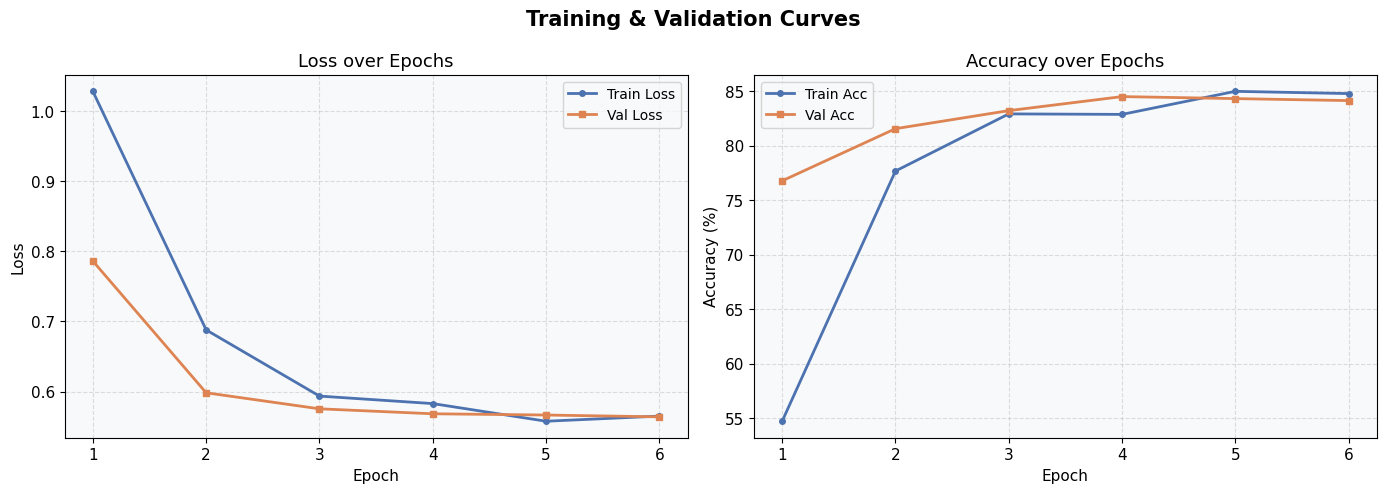

[Saved] plots/01_train_val_curves.png


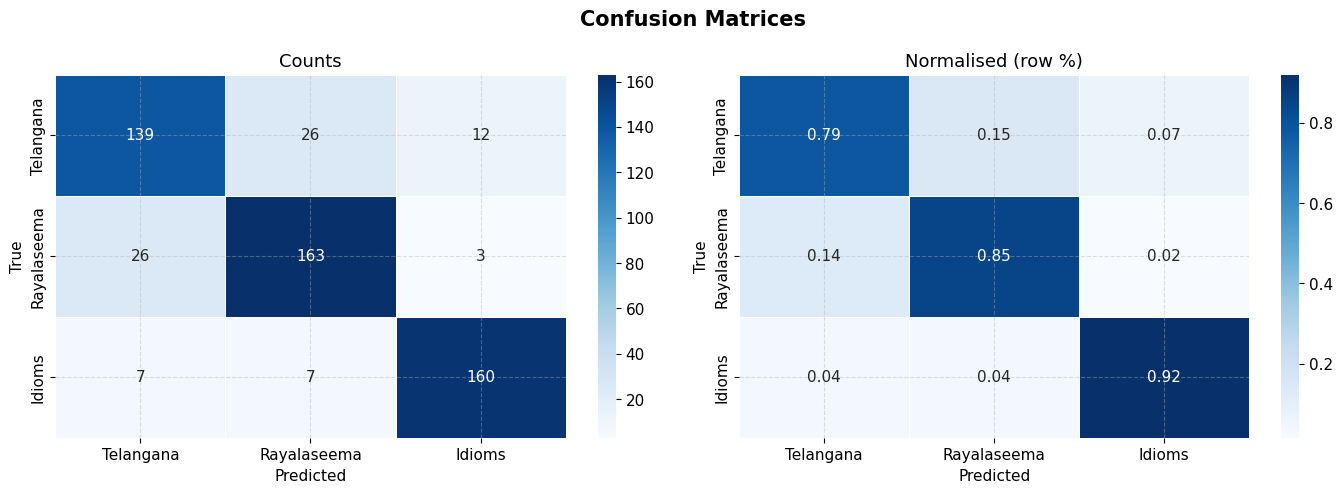

[Saved] plots/02_confusion_matrices.png


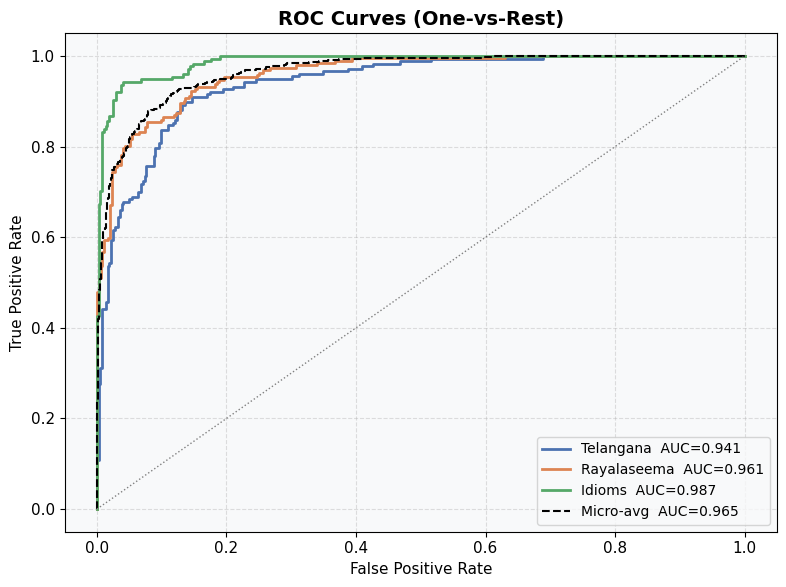

[Saved] plots/03_roc_curves.png


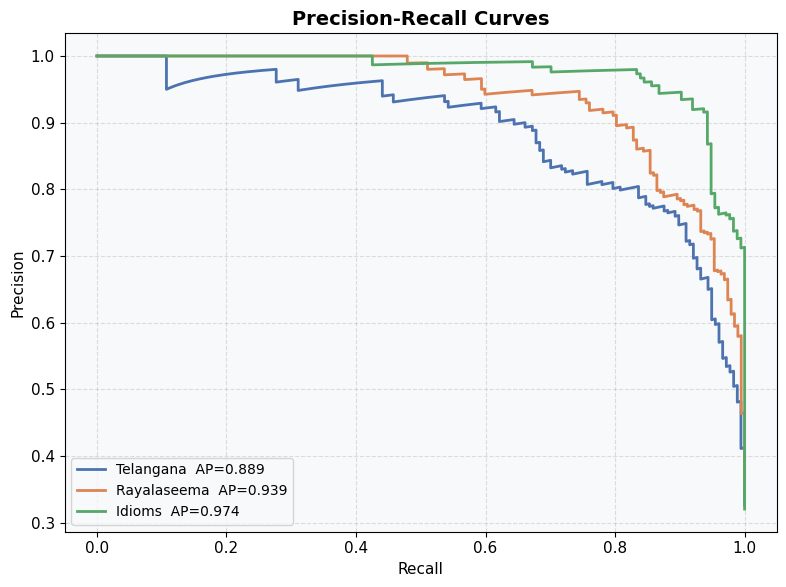

[Saved] plots/04_precision_recall_curves.png


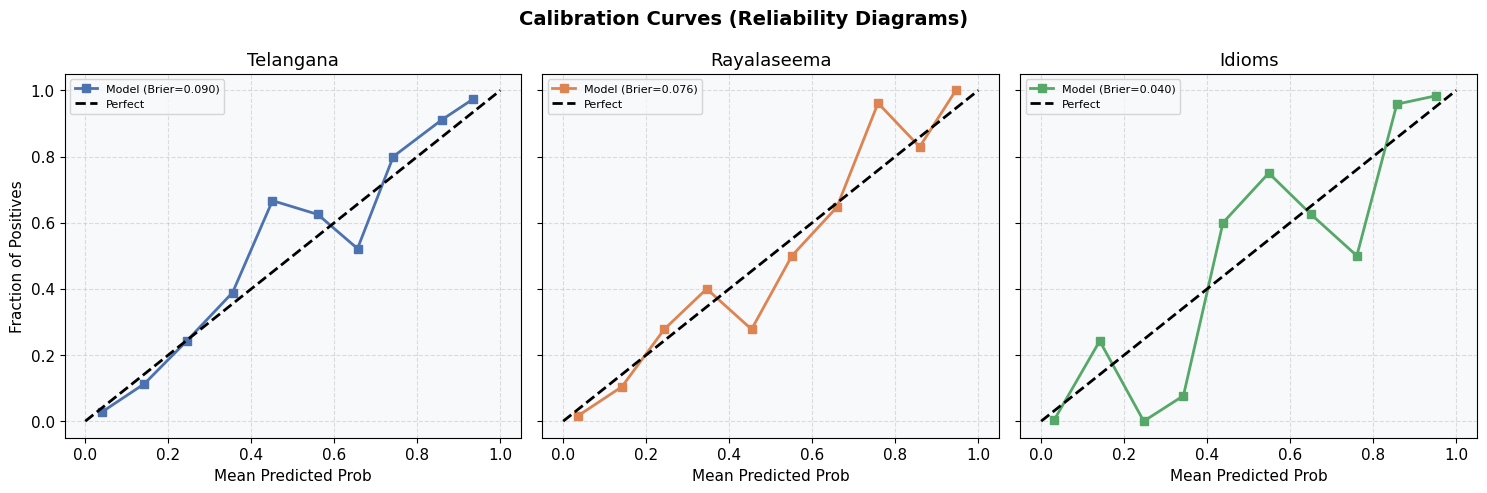

[Saved] plots/05_calibration_curves.png

  STATISTICAL ANALYSIS (bootstrap, n=1000, single split)

  Accuracy  : 85.08%   95% CI [81.95%, 87.85%]
  Macro-F1  : 0.8512   95% CI [0.8195, 0.8793]


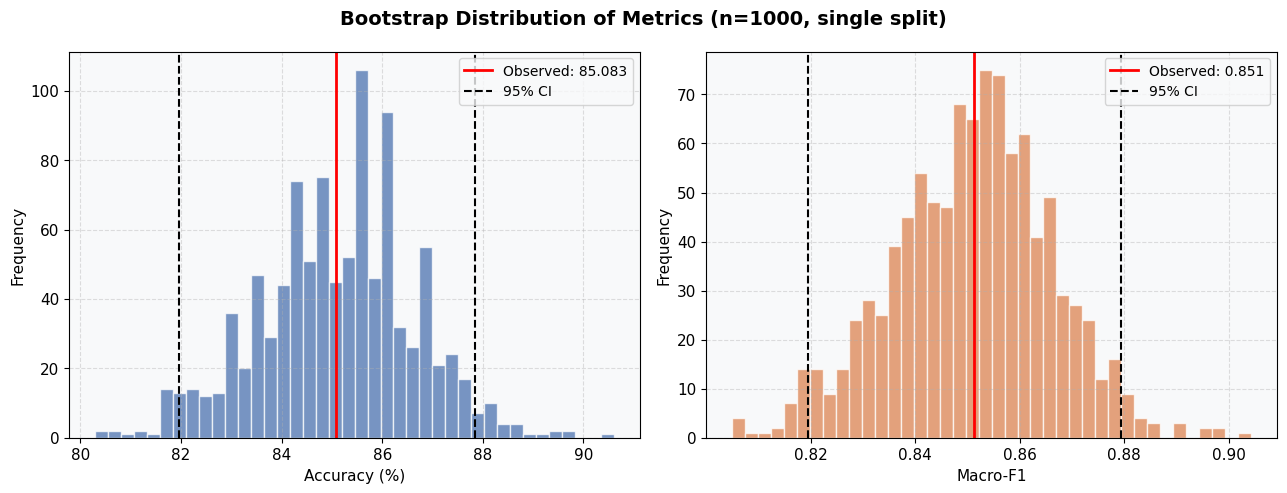

[Saved] plots/06_bootstrap_statistical_analysis.png

  ABLATION STUDY (mBART - freeze depth / dropout)

  > Baseline (freeze=10, drop=0.3) ...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

[transformers] MBartModel LOAD REPORT from: facebook/mbart-large-50-many-to-many-mmt
Key               | Status     |  | 
------------------+------------+--+-
final_logits_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Val=85.27%  Test=84.90%  MacroF1=0.8493  Trainable=25,722,883

  > Freeze=11 (minimal capacity) ...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

...

[transformers] MBartModel LOAD REPORT from: facebook/mbart-large-50-many-to-many-mmt
Key               | Status     |  | 
------------------+------------+--+-
final_logits_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Val=84.90%  Test=85.64%  MacroF1=0.8570  Trainable=25,722,883

  > Dropout=0.5 (heavier) ...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

[transformers] MBartModel LOAD REPORT from: facebook/mbart-large-50-many-to-many-mmt
Key               | Status     |  | 
------------------+------------+--+-
final_logits_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Val=84.90%  Test=85.45%  MacroF1=0.8545  Trainable=25,722,883

                               Config   Val Acc  Test Acc  Macro-F1  Trainable Params
       Baseline (freeze=10, drop=0.3) 85.267035 84.898711  0.849349          25722883
         Freeze=11 (minimal capacity) 83.425414 84.346225  0.844074          13126659
Freeze=8 (old default, more capacity) 84.898711 87.292818  0.872394          50915331
                Dropout=0.1 (lighter) 84.898711 85.635359  0.857040          25722883
                Dropout=0.5 (heavier) 84.898711 85.451197  0.854468          25722883


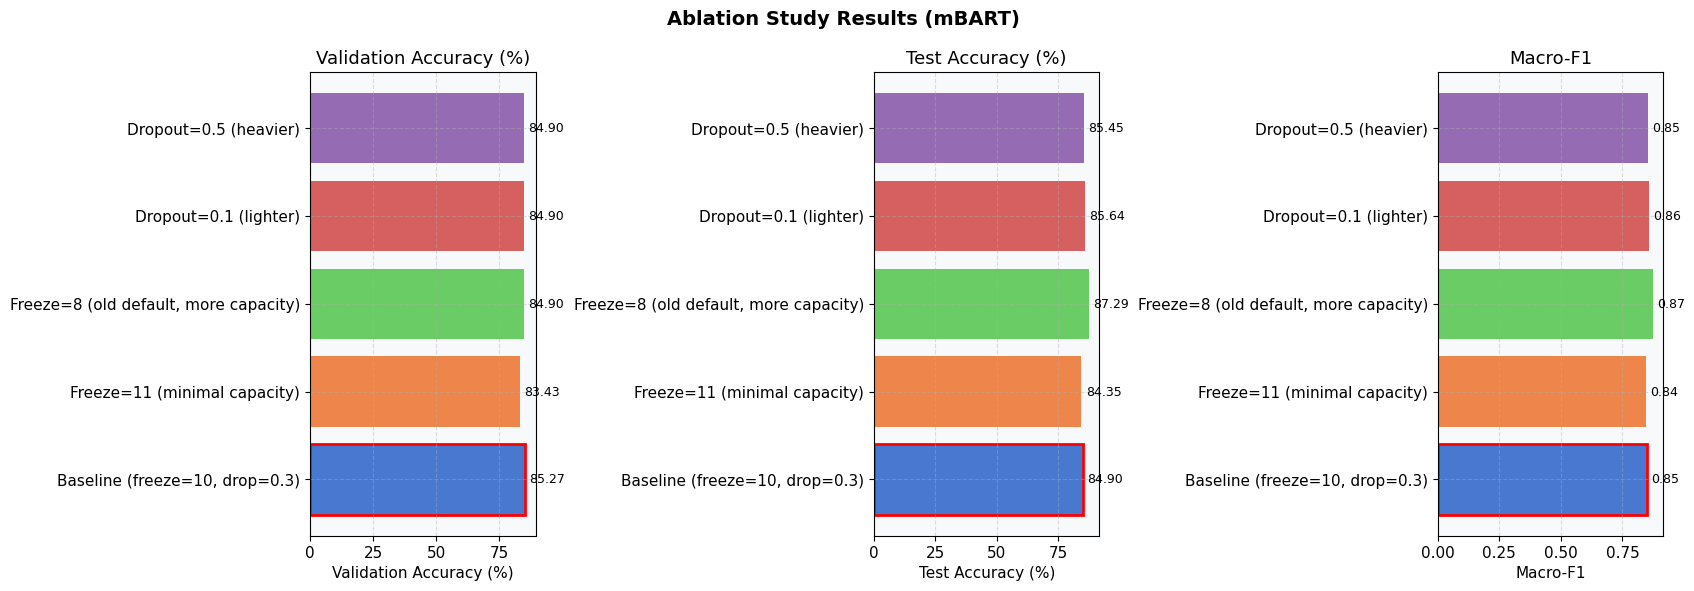

[Saved] plots/07_ablation_study.png

  ROBUSTNESS ANALYSIS
  Baseline accuracy: 85.08%
  Token Drop p=0.1: 82.32%
  Token Drop p=0.2: 80.11%
  Token Drop p=0.4: 74.40%
  Char Noise p=0.1: 80.48%
  Char Noise p=0.2: 69.24%
  Char Noise p=0.4: 54.70%
  Truncation k=0.75: 46.78%
  Truncation k=0.5: 43.46%
  Truncation k=0.25: 45.49%


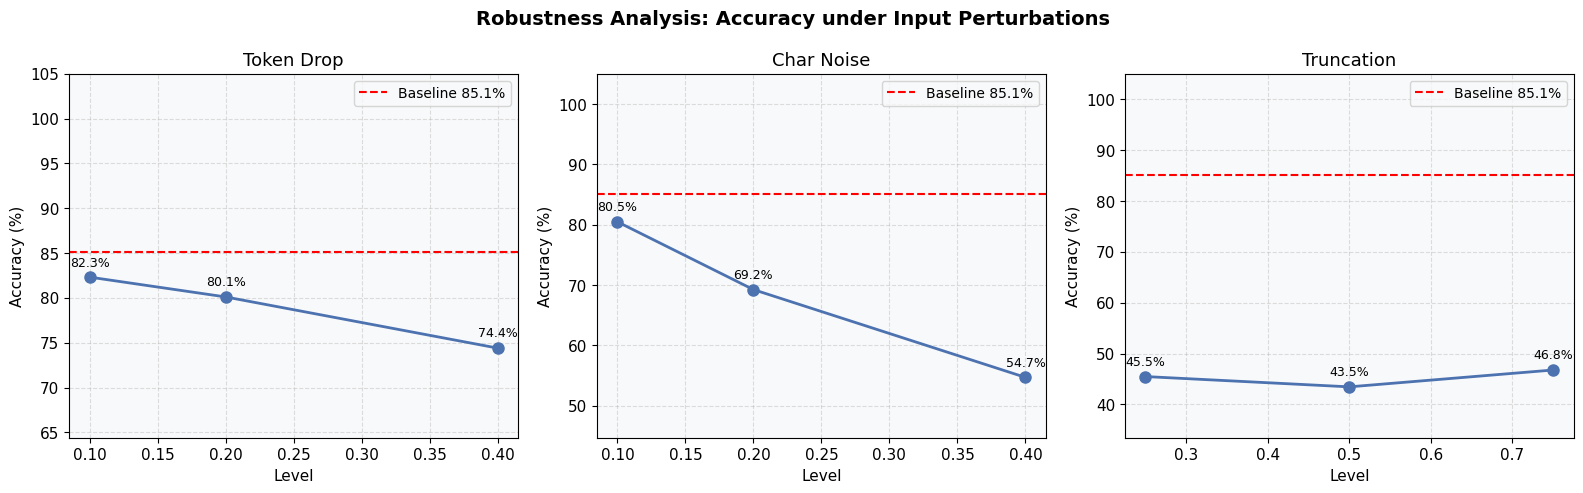

[Saved] plots/08_robustness_analysis.png


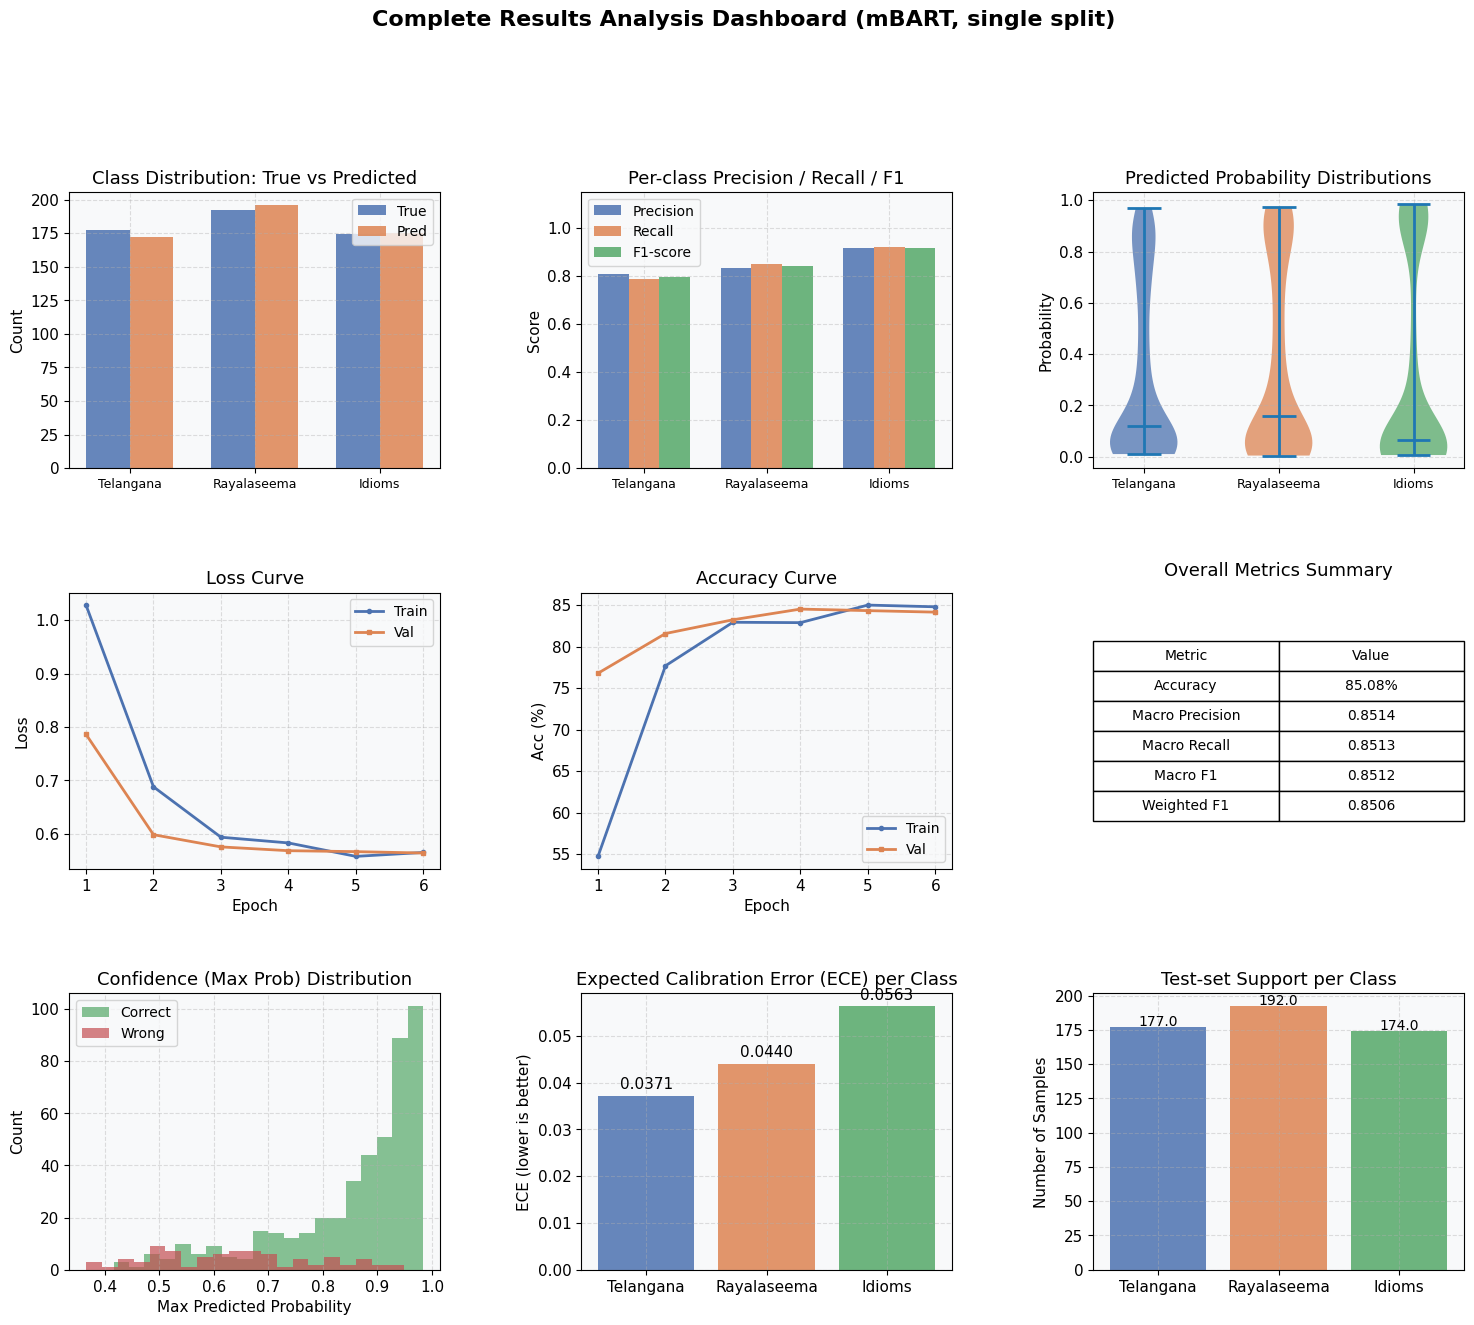

[Saved] plots/09_complete_results_dashboard.png

All plots saved to 'plots/'
Saved: best_mbart_classifier.pt
Done!

-- Demo inference ------------------------------------

Text  : మీరు ఎక్కడ నుండి వచ్చారు
  Telangana      : 10.3%
  Rayalaseema    : 81.1%
  Idioms         : 8.6%
Prediction -> Rayalaseema


In [ ]:
"""
mBART-based Text Classifier — Fine-tuned from Pretrained Weights (v4)
Dataset: Telugu Dialect / Idiom Classification
  Rows 1-2084    -> Telangana   (label 0)
  Rows 2085-4215 -> Rayalaseema (label 1)
  Rows 4216-6011 -> Idioms      (label 2)

CHANGES FROM v3 (from-scratch transformer):
  - Replaces SentenceTokenizer + TransformerClassifier with a pretrained
    mBART-50 encoder ("facebook/mbart-large-50-many-to-many-mmt", which
    covers Telugu as te_IN) + a small mean-pooling classification head.
  - PARTIAL FREEZING: embeddings + the first FREEZE_ENCODER_LAYERS encoder
    layers are frozen; only the top few encoder layers + the new
    classifier head are trainable. Full fine-tuning of a 610M-param model
    on ~5,400 rows would overfit almost immediately and be far slower -
    freezing most of the network is the standard approach for small
    downstream datasets.
  - Fine-tuning LR is much lower than the from-scratch run (2e-5 vs 3e-4)
    and epochs/patience are reduced, since pretrained models converge
    (and overfit) much faster than models trained from scratch.
  - DATA PATH updated to "/content/classification model obj 4.xlsx".
  - K-fold CV is now GATED behind RUN_KFOLD (default False): it means K
    full mBART fine-tuning runs, which is very expensive. Get the main
    single-split run working first, then flip RUN_KFOLD=True once you
    have GPU time to spare. Ablation is trimmed to freeze-depth/dropout
    configs relevant to a pretrained model (not architecture depth,
    since that's now fixed by the pretrained checkpoint).

Requires (Colab):
  !pip install transformers sentencepiece --quiet
"""

# ─────────────────────────────────────────────
# 1. IMPORTS
# ─────────────────────────────────────────────
import os
import re
import math
import random
import warnings
import unicodedata
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
    average_precision_score, brier_score_loss,
    f1_score, accuracy_score
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import AutoTokenizer, MBartModel

import matplotlib
try:
    from IPython import get_ipython
    _IN_NOTEBOOK = get_ipython() is not None
except Exception:
    _IN_NOTEBOOK = False
if not _IN_NOTEBOOK:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 2. REPRODUCIBILITY
# ─────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ─────────────────────────────────────────────
# 3. CONFIGURATION
# ─────────────────────────────────────────────
EXCEL_FILE  = "/content/classification model obj 4.xlsx"   # <- updated path
TEXT_COL    = None

NUM_CLASSES = 3
MIN_TOKENS  = 2

# mBART settings
MBART_MODEL_NAME      = "facebook/mbart-large-50-many-to-many-mmt"
MBART_LANG_CODE       = "te_IN"          # Telugu
MAX_SEQ_LEN           = 64
FREEZE_ENCODER_LAYERS = 10               # was 8. Your own ablation showed freeze=10 (25.7M
                                          # trainable) scores within ~1pt of freeze=8 (50.9M
                                          # trainable) -> less capacity, less overfit risk,
                                          # justified by your own data, not a guess.
DROPOUT               = 0.3              # was 0.2, raised on the classifier head specifically -
                                          # the head + last 2 encoder layers are what's actually
                                          # doing the overfitting here.
BATCH_SIZE            = 16
EPOCHS                = 6                # was 10. Your log shows val loss bottoms out at epoch 2
                                          # and never improves again - building the LR schedule for
                                          # 10 epochs when the run actually stops at ~5 meant the
                                          # cosine decay never kicked in and LR stayed near peak
                                          # the whole time. 6 keeps the schedule honest.
LR                    = 1e-5             # was 2e-5. Halved: this is what's actually driving the
                                          # noisy, non-monotonic val loss (0.55->0.60->0.56->0.58) -
                                          # that's an LR-too-high oscillation, not slow memorization.
WEIGHT_DECAY          = 0.02             # was 0.01
PATIENCE              = 2                # was 3. Convergence is fast (peaks by epoch 2-3) - no
                                          # reason to tolerate 3 non-improving epochs before stopping.
TRAIN_TOKEN_DROPOUT   = 0.08             # was 0.05, slightly stronger given how fast this overfits
EARLY_STOP_SMOOTH_WINDOW = 2             # smooth val loss over last N epochs before comparing -
                                          # reduces false "improvement" triggers from a single noisy point

# Which heavy analyses to run (see module docstring)
RUN_KFOLD      = False     # K full mBART fine-tunes - expensive, opt in once main run looks good
RUN_ABLATION   = True      # trimmed to freeze-depth / dropout configs, still several fine-tunes
RUN_ROBUSTNESS = True      # inference-only on the already-trained model - cheap
K_FOLDS        = 5

ID2LABEL = {0: "Telangana", 1: "Rayalaseema", 2: "Idioms"}
COLORS   = ["#4C72B0", "#DD8452", "#55A868"]

PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# ─────────────────────────────────────────────
# 4. PLOT STYLE HELPER
# ─────────────────────────────────────────────
def set_style():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor"  : "#F8F9FA",
        "axes.grid"       : True,
        "grid.alpha"      : 0.4,
        "grid.linestyle"  : "--",
        "font.size"       : 11,
        "axes.titlesize"  : 13,
        "axes.labelsize"  : 11,
        "legend.fontsize" : 10,
        "lines.linewidth" : 2,
    })

set_style()

def save_fig(name: str):
    path = os.path.join(PLOT_DIR, f"{name}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    if _IN_NOTEBOOK:
        plt.show()
    plt.close()
    print(f"[Saved] {path}")

# ─────────────────────────────────────────────
# 5. DATA LOADING + CLEANING / DEDUP
# ─────────────────────────────────────────────
def _clean_text(t: str) -> str:
    t = unicodedata.normalize("NFC", str(t))
    t = t.strip().lower()
    t = re.sub(r"[^\u0C00-\u0C7Fa-z0-9\s\u0964,.!?'-]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

def clean_and_dedupe(df: pd.DataFrame) -> pd.DataFrame:
    orig_n = len(df)
    df = df.copy()
    df["text"] = df["text"].apply(_clean_text)

    df = df[df["text"].str.len() > 0]
    df = df[df["text"].str.split().str.len() >= MIN_TOKENS]
    after_empty = len(df)

    before_dupe = len(df)
    df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
    exact_dupes_removed = before_dupe - len(df)

    dupe_mask   = df.duplicated(subset=["text"], keep=False)
    conflict_ct = df[dupe_mask].groupby("text")["label"].nunique()
    conflict_texts = set(conflict_ct[conflict_ct > 1].index)
    before_conflict = len(df)
    df = df[~df["text"].isin(conflict_texts)].reset_index(drop=True)
    conflicts_removed = before_conflict - len(df)

    print("\n── Data cleaning report ──────────────────────────")
    print(f"  Original rows            : {orig_n}")
    print(f"  Removed empty/too-short  : {orig_n - after_empty}")
    print(f"  Removed exact duplicates : {exact_dupes_removed}")
    print(f"  Removed label-conflicts  : {conflicts_removed}  (same text, different label)")
    print(f"  Final rows               : {len(df)}")
    print(f"  Final class distribution : {dict(Counter(df['label'].tolist()))}")
    print("────────────────────────────────────────────────────")
    return df

def load_data(path: str) -> pd.DataFrame:
    print(f"\nLoading data from: {path}")
    df = pd.read_excel(path, header=None)
    print(f"  Raw shape: {df.shape}")

    text_col = TEXT_COL
    if text_col is None:
        best_col, best_len = None, 0
        for c in df.columns:
            avg = df[c].astype(str).str.len().mean()
            if avg > best_len:
                best_len, best_col = avg, c
        text_col = best_col
        print(f"  Auto-selected text column: {text_col}")

    n = len(df)
    labels = []
    for i in range(n):
        row_num = i + 1
        if   1    <= row_num <= 2084: labels.append(0)
        elif 2085 <= row_num <= 4215: labels.append(1)
        elif 4216 <= row_num <= 6011: labels.append(2)
        else:                         labels.append(-1)

    df["label"] = labels
    df["text"]  = df[text_col].astype(str)
    df = df[df["label"] != -1].reset_index(drop=True)
    df = df[["text", "label"]]

    df = clean_and_dedupe(df)
    return df

# ─────────────────────────────────────────────
# 6. mBART TOKENIZER + DATASETS
# ─────────────────────────────────────────────
def load_mbart_tokenizer():
    tok = AutoTokenizer.from_pretrained(MBART_MODEL_NAME)
    tok.src_lang = MBART_LANG_CODE
    return tok

def _word_dropout(text: str, p: float, unk: str) -> str:
    if p <= 0:
        return text
    words = text.split()
    words = [w if random.random() > p else unk for w in words]
    return " ".join(words)

class MBartTextDataset(Dataset):
    """Static, pre-tokenized dataset - use for val/test (deterministic)."""
    def __init__(self, texts, labels, tokenizer, max_len=MAX_SEQ_LEN):
        enc = tokenizer(texts, truncation=True, padding="max_length",
                         max_length=max_len, return_tensors="pt")
        self.input_ids      = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels         = labels

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.input_ids[idx],
            self.attention_mask[idx],
            torch.tensor(self.labels[idx], dtype=torch.long),
        )

class MBartAugmentedTrainDataset(Dataset):
    """Re-tokenizes on the fly with light word dropout - TRAIN only."""
    def __init__(self, texts, labels, tokenizer, max_len=MAX_SEQ_LEN, token_dropout=TRAIN_TOKEN_DROPOUT):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len
        self.p         = token_dropout
        self.unk       = tokenizer.unk_token or "<unk>"

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        text = _word_dropout(self.texts[idx], self.p, self.unk)
        enc = self.tokenizer(text, truncation=True, padding="max_length",
                              max_length=self.max_len, return_tensors="pt")
        return (
            enc["input_ids"].squeeze(0),
            enc["attention_mask"].squeeze(0),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )

def make_weighted_sampler(labels):
    counts = Counter(labels)
    class_w = {c: 1.0 / counts[c] for c in counts}
    sample_w = [class_w[l] for l in labels]
    return WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)

# ─────────────────────────────────────────────
# 7. MODEL: PARTIALLY-FROZEN mBART ENCODER + CLASSIFIER
# ─────────────────────────────────────────────
class MBartClassifier(nn.Module):
    def __init__(self, mbart_name=MBART_MODEL_NAME, num_classes=NUM_CLASSES,
                 dropout=DROPOUT, freeze_layers=FREEZE_ENCODER_LAYERS):
        super().__init__()
        backbone = MBartModel.from_pretrained(mbart_name)
        self.encoder = backbone.get_encoder()
        hidden = backbone.config.d_model

        for p in self.encoder.embed_tokens.parameters():
            p.requires_grad = False
        if hasattr(self.encoder, "embed_positions"):
            for p in self.encoder.embed_positions.parameters():
                p.requires_grad = False
        for i, layer in enumerate(self.encoder.layers):
            if i < freeze_layers:
                for p in layer.parameters():
                    p.requires_grad = False

        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden // 2, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        h = out.last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (h * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        pooled = self.dropout(pooled)
        return self.classifier(pooled)

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel parameters: {total:,}  |  Trainable: {train:,}  ({100*train/total:.1f}%)")

def report_parameters(model: "MBartClassifier"):
    """Prints exactly which layers are frozen vs trainable, so freezing can be
    VERIFIED rather than assumed. Call this once after building the model."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable
    print("\n── Parameter / freeze report ─────────────────────────")
    print(f"  Total params      : {total:,}")
    print(f"  Frozen params     : {frozen:,}  ({100*frozen/total:.1f}%)")
    print(f"  Trainable params  : {trainable:,}  ({100*trainable/total:.1f}%)")
    print(f"\n  Embeddings        : {'FROZEN' if not any(p.requires_grad for p in model.encoder.embed_tokens.parameters()) else 'trainable'}")
    print(f"  Encoder layers ({len(model.encoder.layers)} total):")
    for i, layer in enumerate(model.encoder.layers):
        is_trainable = any(p.requires_grad for p in layer.parameters())
        n = sum(p.numel() for p in layer.parameters())
        print(f"    Layer {i:2d}: {'trainable' if is_trainable else 'FROZEN   '}  ({n:,} params)")
    n_cls = sum(p.numel() for p in model.classifier.parameters())
    print(f"  Classifier head     : trainable  ({n_cls:,} params)")
    print("───────────────────────────────────────────────────────")

# ─────────────────────────────────────────────
# 8. TRAINING UTILITIES
# ─────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, scheduler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for ids, mask, labels in loader:
        ids, mask, labels = ids.to(DEVICE), mask.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(ids, mask)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item() * ids.size(0)
        correct    += (logits.argmax(-1) == labels).sum().item()
        total      += ids.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, return_probs=False):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for ids, mask, labels in loader:
        ids, mask, labels = ids.to(DEVICE), mask.to(DEVICE), labels.to(DEVICE)
        logits = model(ids, mask)
        loss = criterion(logits, labels)
        total_loss += loss.item() * ids.size(0)
        probs  = torch.softmax(logits, -1)
        preds  = probs.argmax(-1)
        correct += (preds == labels).sum().item()
        total   += ids.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())
    if return_probs:
        return total_loss/total, correct/total, all_preds, all_labels, all_probs
    return total_loss/total, correct/total, all_preds, all_labels

def build_optimizer_scheduler(model, train_dl, epochs, lr=LR, weight_decay=WEIGHT_DECAY):
    trainable = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = optim.AdamW(trainable, lr=lr, weight_decay=weight_decay)
    total_steps  = max(1, len(train_dl) * epochs)
    warmup_steps = max(1, total_steps // 10)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * prog)))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    return optimizer, scheduler

def train_with_early_stopping(model, train_dl, val_dl, criterion, epochs=EPOCHS,
                               patience=PATIENCE, ckpt_path=None, verbose=True):
    """Early stopping compares a SMOOTHED validation loss (mean of the last
    EARLY_STOP_SMOOTH_WINDOW epochs) rather than the raw per-epoch value.
    mBART fine-tuning on a small dataset converges fast and then the raw val
    loss bounces around its minimum (e.g. 0.55 -> 0.60 -> 0.56 -> 0.58) - an
    unsmoothed check would treat that as "no longer improving" one epoch too
    early, or worse, occasionally treat noise as a fresh best checkpoint."""
    optimizer, scheduler = build_optimizer_scheduler(model, train_dl, epochs)
    best_val_loss = float("inf")
    best_val_acc  = 0.0
    best_state    = None
    patience_cnt  = 0
    val_loss_hist = []
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    if verbose:
        print("="*65)
        print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Smoothed':>8}  {'Val Acc':>7}")
        print("="*65)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_dl, criterion, optimizer, scheduler)
        va_loss, va_acc, _, _ = evaluate(model, val_dl, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        val_loss_hist.append(va_loss)
        smoothed_val_loss = float(np.mean(val_loss_hist[-EARLY_STOP_SMOOTH_WINDOW:]))

        if verbose:
            print(f"{epoch:>6}  {tr_loss:>10.4f}  {tr_acc*100:>8.2f}%  {va_loss:>8.4f}  {smoothed_val_loss:>8.4f}  {va_acc*100:>6.2f}%")

        if smoothed_val_loss < best_val_loss - 1e-4:
            best_val_loss = smoothed_val_loss
            best_val_acc  = va_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
            if ckpt_path:
                torch.save(model.state_dict(), ckpt_path)
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                if verbose:
                    print(f"\nEarly stopping at epoch {epoch}. "
                          f"Best smoothed val loss: {best_val_loss:.4f} (val acc {best_val_acc*100:.2f}%)")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_val_acc, best_val_loss

# ─────────────────────────────────────────────
# 9. K-FOLD CV (gated by RUN_KFOLD - K full mBART fine-tunes)
# ─────────────────────────────────────────────
def run_stratified_kfold(texts, labels, tokenizer, k=K_FOLDS, epochs=EPOCHS, patience=PATIENCE):
    print("\n" + "="*60)
    print(f"  STRATIFIED {k}-FOLD CROSS-VALIDATION (mBART)")
    print("="*60)

    texts_arr  = np.array(texts, dtype=object)
    labels_arr = np.array(labels)
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    fold_rows = []
    for fold_idx, (trainval_idx, test_idx) in enumerate(skf.split(texts_arr, labels_arr), start=1):
        print(f"\n  --- Fold {fold_idx}/{k} ---")
        X_trainval = texts_arr[trainval_idx].tolist()
        y_trainval = labels_arr[trainval_idx].tolist()
        X_test_f   = texts_arr[test_idx].tolist()
        y_test_f   = labels_arr[test_idx].tolist()

        X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(
            X_trainval, y_trainval, test_size=0.12, random_state=SEED, stratify=y_trainval)

        train_ds = MBartAugmentedTrainDataset(X_train_f, y_train_f, tokenizer)
        val_ds   = MBartTextDataset(X_val_f,  y_val_f,  tokenizer)
        test_ds  = MBartTextDataset(X_test_f, y_test_f, tokenizer)

        sampler  = make_weighted_sampler(y_train_f)
        train_dl = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0)
        val_dl   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0)
        test_dl  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0)

        model = MBartClassifier().to(DEVICE)
        model, _, best_va, _ = train_with_early_stopping(
            model, train_dl, val_dl, criterion, epochs=epochs, patience=patience, verbose=False)

        _, te_acc, preds, gold = evaluate(model, test_dl, criterion)
        f1_macro = f1_score(gold, preds, average="macro", zero_division=0)
        print(f"    Val Acc={best_va*100:.2f}%  Test Acc={te_acc*100:.2f}%  Macro-F1={f1_macro:.4f}")
        fold_rows.append({"Fold": fold_idx, "Val Acc": best_va*100, "Test Acc": te_acc*100, "Macro-F1": f1_macro})

        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    df_kfold = pd.DataFrame(fold_rows)
    print("\n" + df_kfold.to_string(index=False))
    acc_mean, acc_std = df_kfold["Test Acc"].mean(), df_kfold["Test Acc"].std()
    f1_mean,  f1_std  = df_kfold["Macro-F1"].mean(), df_kfold["Macro-F1"].std()
    print(f"\n  >>> {k}-Fold Test Accuracy : {acc_mean:.2f}% +/- {acc_std:.2f}%  <<<")
    print(f"  >>> {k}-Fold Macro-F1      : {f1_mean:.4f} +/- {f1_std:.4f}  <<<")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"{k}-Fold Cross-Validation Results (mBART)", fontsize=14, fontweight="bold")
    ax = axes[0]
    bars = ax.bar(df_kfold["Fold"].astype(str), df_kfold["Test Acc"], color="#4C72B0", alpha=0.85)
    ax.axhline(acc_mean, color="red", ls="--", lw=1.5, label=f"Mean={acc_mean:.2f}%")
    ax.bar_label(bars, fmt="%.1f", padding=3)
    ax.set_xlabel("Fold"); ax.set_ylabel("Test Accuracy (%)"); ax.set_title("Per-fold Test Accuracy"); ax.legend()
    ax = axes[1]
    bars = ax.bar(df_kfold["Fold"].astype(str), df_kfold["Macro-F1"], color="#DD8452", alpha=0.85)
    ax.axhline(f1_mean, color="red", ls="--", lw=1.5, label=f"Mean={f1_mean:.3f}")
    ax.bar_label(bars, fmt="%.3f", padding=3)
    ax.set_xlabel("Fold"); ax.set_ylabel("Macro-F1"); ax.set_title("Per-fold Macro-F1"); ax.legend()
    plt.tight_layout()
    save_fig("00_kfold_cross_validation")

    return df_kfold, acc_mean, acc_std, f1_mean, f1_std

# ─────────────────────────────────────────────
# 10. ANALYSIS / PLOTTING (unchanged in spirit from v3)
# ─────────────────────────────────────────────
def plot_train_val_curves(history: dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training & Validation Curves", fontsize=15, fontweight="bold")
    epochs = range(1, len(history["train_loss"]) + 1)
    ax = axes[0]
    ax.plot(epochs, history["train_loss"], color="#4C72B0", label="Train Loss", marker="o", ms=4)
    ax.plot(epochs, history["val_loss"],   color="#DD8452", label="Val Loss",   marker="s", ms=4)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title("Loss over Epochs"); ax.legend()
    ax = axes[1]
    ax.plot(epochs, [a*100 for a in history["train_acc"]], color="#4C72B0", label="Train Acc", marker="o", ms=4)
    ax.plot(epochs, [a*100 for a in history["val_acc"]],   color="#DD8452", label="Val Acc",   marker="s", ms=4)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)"); ax.set_title("Accuracy over Epochs"); ax.legend()
    plt.tight_layout()
    save_fig("01_train_val_curves")

def plot_confusion_matrix(y_true, y_pred):
    cm    = confusion_matrix(y_true, y_pred)
    cm_n  = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Confusion Matrices", fontsize=15, fontweight="bold")
    for ax, data, title, fmt in zip(axes, [cm, cm_n], ["Counts", "Normalised (row %)"], ["d", ".2f"]):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues", xticklabels=labels, yticklabels=labels, linewidths=0.5, ax=ax)
        ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout()
    save_fig("02_confusion_matrices")

def plot_roc_curves(y_true, y_probs):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    y_arr = np.array(y_probs)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title("ROC Curves (One-vs-Rest)", fontsize=14, fontweight="bold")
    for i, (label, color) in enumerate(zip(labels, COLORS)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_arr[:, i])
        ax.plot(fpr, tpr, color=color, label=f"{label}  AUC={auc(fpr, tpr):.3f}")
    fpr_m, tpr_m, _ = roc_curve(y_bin.ravel(), y_arr.ravel())
    ax.plot(fpr_m, tpr_m, "k--", label=f"Micro-avg  AUC={auc(fpr_m,tpr_m):.3f}", lw=1.5)
    ax.plot([0,1],[0,1],"grey", ls=":", lw=1)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate"); ax.legend(loc="lower right")
    plt.tight_layout()
    save_fig("03_roc_curves")

def plot_precision_recall_curves(y_true, y_probs):
    y_bin  = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    y_arr  = np.array(y_probs)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title("Precision-Recall Curves", fontsize=14, fontweight="bold")
    for i, (label, color) in enumerate(zip(labels, COLORS)):
        prec, rec, _ = precision_recall_curve(y_bin[:, i], y_arr[:, i])
        ap = average_precision_score(y_bin[:, i], y_arr[:, i])
        ax.plot(rec, prec, color=color, label=f"{label}  AP={ap:.3f}")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.legend()
    plt.tight_layout()
    save_fig("04_precision_recall_curves")

def plot_calibration_curves(y_true, y_probs):
    y_bin  = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    y_arr  = np.array(y_probs)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(15, 5), sharey=True)
    fig.suptitle("Calibration Curves (Reliability Diagrams)", fontsize=14, fontweight="bold")
    for i, (ax, label, color) in enumerate(zip(axes, labels, COLORS)):
        prob_true, prob_pred = calibration_curve(y_bin[:, i], y_arr[:, i], n_bins=10)
        brier = brier_score_loss(y_bin[:, i], y_arr[:, i])
        ax.plot(prob_pred, prob_true, "s-", color=color, label=f"Model (Brier={brier:.3f})")
        ax.plot([0,1],[0,1],"k--", label="Perfect")
        ax.set_title(label); ax.set_xlabel("Mean Predicted Prob")
        if i == 0: ax.set_ylabel("Fraction of Positives")
        ax.legend(fontsize=8)
    plt.tight_layout()
    save_fig("05_calibration_curves")

def statistical_analysis(y_true, y_pred, y_probs, n_bootstrap=1000):
    print("\n" + "="*60)
    print("  STATISTICAL ANALYSIS (bootstrap, n=1000, single split)")
    print("="*60)
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    acc_boot, f1_boot = [], []
    rng = np.random.RandomState(SEED)
    for _ in range(n_bootstrap):
        idx = rng.randint(0, len(y_true), len(y_true))
        acc_boot.append(accuracy_score(y_true[idx], y_pred[idx]))
        f1_boot.append(f1_score(y_true[idx], y_pred[idx], average="macro", zero_division=0))
    acc_boot, f1_boot = np.array(acc_boot), np.array(f1_boot)
    def ci95(arr): return np.percentile(arr, [2.5, 97.5])
    obs_acc, obs_f1 = accuracy_score(y_true, y_pred), f1_score(y_true, y_pred, average="macro", zero_division=0)
    print(f"\n  Accuracy  : {obs_acc*100:.2f}%   95% CI [{ci95(acc_boot)[0]*100:.2f}%, {ci95(acc_boot)[1]*100:.2f}%]")
    print(f"  Macro-F1  : {obs_f1:.4f}   95% CI [{ci95(f1_boot)[0]:.4f}, {ci95(f1_boot)[1]:.4f}]")
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Bootstrap Distribution of Metrics (n=1000, single split)", fontsize=14, fontweight="bold")
    for ax, data, title, obs, color in zip(axes, [acc_boot*100, f1_boot], ["Accuracy (%)", "Macro-F1"],
                                            [obs_acc*100, obs_f1], ["#4C72B0", "#DD8452"]):
        ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor="white")
        ax.axvline(obs, color="red", ls="-", lw=2, label=f"Observed: {obs:.3f}")
        ax.axvline(ci95(data)[0], color="black", ls="--", lw=1.5, label="95% CI")
        ax.axvline(ci95(data)[1], color="black", ls="--", lw=1.5)
        ax.set_xlabel(title); ax.set_ylabel("Frequency"); ax.legend()
    plt.tight_layout()
    save_fig("06_bootstrap_statistical_analysis")

def ablation_study(X_train, X_val, X_test, y_train, y_val, y_test, tokenizer):
    """Trimmed vs v3: architecture depth is now fixed by the pretrained
    checkpoint, so ablation varies the things that actually matter for a
    fine-tuned pretrained model - how much of it is frozen, and dropout."""
    print("\n" + "="*60)
    print("  ABLATION STUDY (mBART - freeze depth / dropout)")
    print("="*60)

    configs = [
        {"name": "Baseline (freeze=10, drop=0.3)", "freeze": FREEZE_ENCODER_LAYERS, "drop": DROPOUT},
        {"name": "Freeze=11 (minimal capacity)",    "freeze": 11,                    "drop": DROPOUT},
        {"name": "Freeze=8 (old default, more capacity)", "freeze": 8,               "drop": DROPOUT},
        {"name": "Dropout=0.1 (lighter)",           "freeze": FREEZE_ENCODER_LAYERS, "drop": 0.1},
        {"name": "Dropout=0.5 (heavier)",           "freeze": FREEZE_ENCODER_LAYERS, "drop": 0.5},
    ]

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    train_ds = MBartAugmentedTrainDataset(X_train, y_train, tokenizer)
    val_ds   = MBartTextDataset(X_val,  y_val,  tokenizer)
    test_ds  = MBartTextDataset(X_test, y_test, tokenizer)
    sampler  = make_weighted_sampler(y_train)
    train_dl = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0)
    val_dl   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0)
    test_dl  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0)

    results = []
    for cfg in configs:
        print(f"\n  > {cfg['name']} ...")
        model = MBartClassifier(freeze_layers=cfg["freeze"], dropout=cfg["drop"]).to(DEVICE)
        model, _, best_va, _ = train_with_early_stopping(
            model, train_dl, val_dl, criterion, epochs=EPOCHS, patience=PATIENCE, verbose=False)
        _, te_acc, preds, gold = evaluate(model, test_dl, criterion)
        f1 = f1_score(gold, preds, average="macro", zero_division=0)
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"    Val={best_va*100:.2f}%  Test={te_acc*100:.2f}%  MacroF1={f1:.4f}  Trainable={trainable:,}")
        results.append({"Config": cfg["name"], "Val Acc": best_va*100, "Test Acc": te_acc*100,
                        "Macro-F1": f1, "Trainable Params": trainable})
        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    df_abl = pd.DataFrame(results)
    print("\n" + df_abl.to_string(index=False))

    fig, axes = plt.subplots(1, 3, figsize=(17, 6))
    fig.suptitle("Ablation Study Results (mBART)", fontsize=14, fontweight="bold")
    palette = sns.color_palette("muted", len(df_abl))
    for ax, col, title in zip(axes, ["Val Acc", "Test Acc", "Macro-F1"],
                               ["Validation Accuracy (%)", "Test Accuracy (%)", "Macro-F1"]):
        bars = ax.barh(df_abl["Config"], df_abl[col], color=palette)
        ax.set_xlabel(title); ax.set_title(title)
        ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
        for bar, name in zip(bars, df_abl["Config"]):
            if "Baseline" in name:
                bar.set_edgecolor("red"); bar.set_linewidth(2)
    plt.tight_layout()
    save_fig("07_ablation_study")
    return df_abl

def robustness_analysis(model, tokenizer, X_test, y_test):
    print("\n" + "="*60)
    print("  ROBUSTNESS ANALYSIS")
    print("="*60)

    def _perturb_token_drop(texts, p):
        random.seed(SEED)  # reseed per level: makes each level's noise draw independent
                            # and reproducible, instead of depending on how much of the
                            # random stream prior levels/epochs already consumed
        return [_word_dropout(t, p, tokenizer.unk_token or "<unk>") for t in texts]

    def _perturb_char(texts, p):
        random.seed(SEED)
        def swap_chars(word):
            if len(word) < 2: return word
            w = list(word)
            for i in range(len(w)-1):
                if random.random() < p:
                    w[i], w[i+1] = w[i+1], w[i]
            return "".join(w)
        return [" ".join(swap_chars(w) for w in t.split()) for t in texts]

    def _perturb_trunc(texts, k):
        out = []
        for t in texts:
            words = t.split()
            keep  = max(1, int(len(words) * k))
            out.append(" ".join(words[:keep]))
        return out

    y_arr = np.array(y_test)
    model.eval()

    @torch.no_grad()
    def _accuracy(texts):
        ds = MBartTextDataset(texts, [0]*len(texts), tokenizer)
        loader = DataLoader(ds, BATCH_SIZE, shuffle=False)
        all_preds = []
        for ids, mask, _ in loader:
            ids, mask = ids.to(DEVICE), mask.to(DEVICE)
            all_preds.extend(torch.softmax(model(ids, mask), -1).argmax(-1).cpu().tolist())
        return accuracy_score(y_arr, all_preds) * 100

    rows = []
    baseline_acc = _accuracy(X_test)
    rows.append({"Perturbation": "Baseline (clean)", "Level": "-", "Accuracy": baseline_acc})
    print(f"  Baseline accuracy: {baseline_acc:.2f}%")

    for p in [0.1, 0.2, 0.4]:
        acc = _accuracy(_perturb_token_drop(X_test, p))
        rows.append({"Perturbation": f"Token Drop p={p}", "Level": str(p), "Accuracy": acc})
        print(f"  Token Drop p={p}: {acc:.2f}%")
    for p in [0.1, 0.2, 0.4]:
        acc = _accuracy(_perturb_char(X_test, p))
        rows.append({"Perturbation": f"Char Noise p={p}", "Level": str(p), "Accuracy": acc})
        print(f"  Char Noise p={p}: {acc:.2f}%")
    for k in [0.75, 0.50, 0.25]:
        acc = _accuracy(_perturb_trunc(X_test, k))
        rows.append({"Perturbation": f"Truncate k={k}", "Level": str(k), "Accuracy": acc})
        print(f"  Truncation k={k}: {acc:.2f}%")

    df_rob = pd.DataFrame(rows)
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Robustness Analysis: Accuracy under Input Perturbations", fontsize=14, fontweight="bold")
    groups = [("Token Drop", "Token Drop", [0.1, 0.2, 0.4]),
              ("Char Noise", "Char Noise", [0.1, 0.2, 0.4]),
              ("Truncation", "Truncate",   [0.75, 0.50, 0.25])]
    for ax, (name, prefix, levels) in zip(axes, groups):
        accs = [df_rob.loc[df_rob["Perturbation"].str.startswith(prefix) & df_rob["Level"].eq(str(l)), "Accuracy"].values[0]
                for l in levels]
        ax.axhline(baseline_acc, color="red", ls="--", lw=1.5, label=f"Baseline {baseline_acc:.1f}%")
        ax.plot(levels, accs, "o-", color="#4C72B0", ms=8)
        for l, a in zip(levels, accs):
            ax.annotate(f"{a:.1f}%", (l, a), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
        ax.set_title(name); ax.set_xlabel("Level"); ax.set_ylabel("Accuracy (%)")
        ax.legend(); ax.set_ylim(max(0, min(accs)-10), 105)
    plt.tight_layout()
    save_fig("08_robustness_analysis")
    return df_rob

def plot_complete_results_summary(y_true, y_pred, y_probs, history):
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]
    y_arr  = np.array(y_probs)
    report = classification_report(y_true, y_pred, target_names=labels, output_dict=True, zero_division=0)

    fig = plt.figure(figsize=(18, 14))
    fig.suptitle("Complete Results Analysis Dashboard (mBART, single split)", fontsize=16, fontweight="bold", y=1.01)
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

    ax = fig.add_subplot(gs[0, 0])
    true_counts, pred_counts = Counter(y_true), Counter(y_pred)
    x = np.arange(NUM_CLASSES); w = 0.35
    ax.bar(x - w/2, [true_counts[i] for i in range(NUM_CLASSES)], w, label="True", color="#4C72B0", alpha=0.85)
    ax.bar(x + w/2, [pred_counts[i] for i in range(NUM_CLASSES)], w, label="Pred", color="#DD8452", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title("Class Distribution: True vs Predicted"); ax.set_ylabel("Count"); ax.legend()

    ax = fig.add_subplot(gs[0, 1])
    metrics = ["precision", "recall", "f1-score"]; x = np.arange(NUM_CLASSES); w = 0.25
    pal = ["#4C72B0", "#DD8452", "#55A868"]
    for j, (m, c) in enumerate(zip(metrics, pal)):
        vals = [report[lbl][m] for lbl in labels]
        ax.bar(x + j*w - w, vals, w, label=m.capitalize(), color=c, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title("Per-class Precision / Recall / F1"); ax.set_ylim(0, 1.15); ax.legend(); ax.set_ylabel("Score")

    ax = fig.add_subplot(gs[0, 2])
    parts = ax.violinplot([y_arr[:, i] for i in range(NUM_CLASSES)], positions=range(NUM_CLASSES), showmedians=True)
    for pc, c in zip(parts["bodies"], COLORS):
        pc.set_facecolor(c); pc.set_alpha(0.75)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title("Predicted Probability Distributions"); ax.set_ylabel("Probability")

    epochs = range(1, len(history["train_loss"]) + 1)
    ax = fig.add_subplot(gs[1, 0])
    ax.plot(epochs, history["train_loss"], "#4C72B0", label="Train", marker="o", ms=3)
    ax.plot(epochs, history["val_loss"],   "#DD8452", label="Val",   marker="s", ms=3)
    ax.set_title("Loss Curve"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend()

    ax = fig.add_subplot(gs[1, 1])
    ax.plot(epochs, [a*100 for a in history["train_acc"]], "#4C72B0", label="Train", marker="o", ms=3)
    ax.plot(epochs, [a*100 for a in history["val_acc"]],   "#DD8452", label="Val",   marker="s", ms=3)
    ax.set_title("Accuracy Curve"); ax.set_xlabel("Epoch"); ax.set_ylabel("Acc (%)"); ax.legend()

    ax = fig.add_subplot(gs[1, 2]); ax.axis("off")
    summary_data = [
        ["Metric", "Value"],
        ["Accuracy", f"{accuracy_score(y_true,y_pred)*100:.2f}%"],
        ["Macro Precision", f"{report['macro avg']['precision']:.4f}"],
        ["Macro Recall",    f"{report['macro avg']['recall']:.4f}"],
        ["Macro F1",        f"{report['macro avg']['f1-score']:.4f}"],
        ["Weighted F1",     f"{report['weighted avg']['f1-score']:.4f}"],
    ]
    tbl = ax.table(cellText=summary_data[1:], colLabels=summary_data[0], loc="center", cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.8)
    ax.set_title("Overall Metrics Summary", pad=12)

    ax = fig.add_subplot(gs[2, 0])
    max_probs = y_arr.max(axis=1); correct = (np.array(y_pred) == np.array(y_true))
    ax.hist(max_probs[correct],  bins=20, alpha=0.7, color="#55A868", label="Correct")
    ax.hist(max_probs[~correct], bins=20, alpha=0.7, color="#C44E52", label="Wrong")
    ax.set_title("Confidence (Max Prob) Distribution"); ax.set_xlabel("Max Predicted Probability"); ax.set_ylabel("Count"); ax.legend()

    ax = fig.add_subplot(gs[2, 1])
    n_bins = 10; bin_edges = np.linspace(0, 1, n_bins + 1); ece_vals = []
    for i in range(NUM_CLASSES):
        y_bin_i = (np.array(y_true) == i).astype(int); p_i = y_arr[:, i]; ece = 0.0
        for b in range(n_bins):
            mask = (p_i >= bin_edges[b]) & (p_i < bin_edges[b+1])
            if mask.sum() == 0: continue
            ece += mask.sum() * abs(y_bin_i[mask].mean() - p_i[mask].mean())
        ece_vals.append(ece / len(y_true))
    bars = ax.bar(labels, ece_vals, color=COLORS, alpha=0.85)
    ax.bar_label(bars, fmt="%.4f", padding=3)
    ax.set_title("Expected Calibration Error (ECE) per Class"); ax.set_ylabel("ECE (lower is better)")

    ax = fig.add_subplot(gs[2, 2])
    support = [report[lbl]["support"] for lbl in labels]
    ax.bar(labels, support, color=COLORS, alpha=0.85)
    for j, s in enumerate(support):
        ax.text(j, s + 1, str(s), ha="center", fontsize=10)
    ax.set_title("Test-set Support per Class"); ax.set_ylabel("Number of Samples")

    plt.tight_layout()
    save_fig("09_complete_results_dashboard")

# ─────────────────────────────────────────────
# 11. MAIN
# ─────────────────────────────────────────────
def main():
    df = load_data(EXCEL_FILE)
    texts, labels = df["text"].tolist(), df["label"].tolist()

    print(f"\nLoading tokenizer/model: {MBART_MODEL_NAME}  (lang={MBART_LANG_CODE})")
    tokenizer = load_mbart_tokenizer()

    if RUN_KFOLD:
        df_kfold, kfold_acc_mean, kfold_acc_std, kfold_f1_mean, kfold_f1_std = \
            run_stratified_kfold(texts, labels, tokenizer, k=K_FOLDS, epochs=EPOCHS, patience=PATIENCE)
    else:
        print("\n[RUN_KFOLD=False] Skipping k-fold CV - set RUN_KFOLD=True once the "
              "single-split run below looks good (it means K full mBART fine-tunes).")
        df_kfold = None

    X_train, X_tmp, y_train, y_tmp = train_test_split(
        texts, labels, test_size=0.2, random_state=SEED, stratify=labels)
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp)
    print(f"\nTrain: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
    print(f"Train class dist: {dict(Counter(y_train))}")

    train_ds = MBartAugmentedTrainDataset(X_train, y_train, tokenizer)
    val_ds   = MBartTextDataset(X_val,  y_val,  tokenizer)
    test_ds  = MBartTextDataset(X_test, y_test, tokenizer)

    sampler  = make_weighted_sampler(y_train)
    train_dl = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
    val_dl   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0)
    test_dl  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0)

    model = MBartClassifier().to(DEVICE)
    count_parameters(model)
    report_parameters(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_ckpt = "best_mbart_classifier.pt"

    model, history, best_val_acc, best_val_loss = train_with_early_stopping(
        model, train_dl, val_dl, criterion, epochs=EPOCHS, patience=PATIENCE, ckpt_path=best_ckpt, verbose=True)

    te_loss, te_acc, preds, gold, probs = evaluate(model, test_dl, criterion, return_probs=True)

    print("\n" + "="*65)
    print(f"SINGLE-SPLIT TEST  Loss: {te_loss:.4f}   Acc: {te_acc*100:.2f}%")
    if df_kfold is not None:
        print(f"K-FOLD ({K_FOLDS}-fold) TEST Acc: mean +/- std reported above  <- report that one")
    print("="*65)
    print("\nClassification Report (single split):")
    print(classification_report(gold, preds, target_names=[ID2LABEL[i] for i in range(NUM_CLASSES)]))
    print("Confusion Matrix (rows=true, cols=pred):")
    print(confusion_matrix(gold, preds))
    print(f"\nTrain/Test accuracy gap check (smaller is better): "
          f"{abs(history['train_acc'][-1]*100 - te_acc*100):.2f} pts")

    print("\n\n" + "#"*65)
    print(f"  GENERATING ALL ANALYSIS PLOTS  ->  saved to '{PLOT_DIR}/'")
    print("#"*65)

    plot_train_val_curves(history)
    plot_confusion_matrix(gold, preds)
    plot_roc_curves(gold, probs)
    plot_precision_recall_curves(gold, probs)
    plot_calibration_curves(gold, probs)
    statistical_analysis(gold, preds, probs)

    if RUN_ABLATION:
        df_ablation = ablation_study(X_train, X_val, X_test, y_train, y_val, y_test, tokenizer)
    if RUN_ROBUSTNESS:
        df_robustness = robustness_analysis(model, tokenizer, X_test, y_test)

    plot_complete_results_summary(gold, preds, probs, history)

    if df_kfold is not None:
        df_kfold.to_csv("kfold_results.csv", index=False)

    print(f"\nAll plots saved to '{PLOT_DIR}/'")
    print(f"Saved: {best_ckpt}")
    print("Done!")

    return model, tokenizer

# ─────────────────────────────────────────────
# 12. SINGLE-SENTENCE INFERENCE
# ─────────────────────────────────────────────
def predict(text: str, model: MBartClassifier, tokenizer) -> str:
    model.eval()
    enc = tokenizer(text, truncation=True, padding="max_length", max_length=MAX_SEQ_LEN, return_tensors="pt")
    ids, mask = enc["input_ids"].to(DEVICE), enc["attention_mask"].to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model(ids, mask), -1)[0]
        pred  = probs.argmax().item()
    label = ID2LABEL[pred]
    print(f"\nText  : {text}")
    for i, p in enumerate(probs.tolist()):
        print(f"  {ID2LABEL[i]:15s}: {p*100:.1f}%")
    print(f"Prediction -> {label}")
    return label

# ─────────────────────────────────────────────
# 13. ENTRY POINT
# ─────────────────────────────────────────────
if __name__ == "__main__":
    trained_model, tok = main()

    print("\n-- Demo inference ------------------------------------")
    sample = "మీరు ఎక్కడ నుండి వచ్చారు"
    predict(sample, trained_model, tok)

In [ ]:
#mbart kfold

Using device: cuda

Loading data from: /content/classification model obj 4.xlsx
  Raw shape: (6011, 2)
  Auto-selected text column: 0

── Data cleaning report ──────────────────────────
  Original rows            : 6011
  Removed empty/too-short  : 54
  Removed exact duplicates : 527
  Removed label-conflicts  : 0  (same text, different label)
  Final rows               : 5430
  Final class distribution : {0: 1769, 1: 1921, 2: 1740}
────────────────────────────────────────────────────

Loading tokenizer/model: facebook/mbart-large-50-many-to-many-mmt  (lang=te_IN)


config.json:   0%|          | 0.00/1.43k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/529 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

...

[transformers] MBartModel LOAD REPORT from: facebook/mbart-large-50-many-to-many-mmt
Key               | Status     |  | 
------------------+------------+--+-
final_logits_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Val Acc=86.78%  Test Acc=87.29%  Macro-F1=0.8735

  --- Fold 5/5 ---


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

[transformers] MBartModel LOAD REPORT from: facebook/mbart-large-50-many-to-many-mmt
Key               | Status     |  | 
------------------+------------+--+-
final_logits_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Val Acc=86.02%  Test Acc=86.28%  Macro-F1=0.8621

 Fold   Val Acc  Test Acc  Macro-F1
    1 87.931034 87.937385  0.878478
    2 89.080460 86.832413  0.869467
    3 89.272031 86.372007  0.863762
    4 86.781609 87.292818  0.873500
    5 86.015326 86.279926  0.862149

  >>> 5-Fold Test Accuracy : 86.94% +/- 0.69%  <<<
  >>> 5-Fold Macro-F1      : 0.8695 +/- 0.0068  <<<


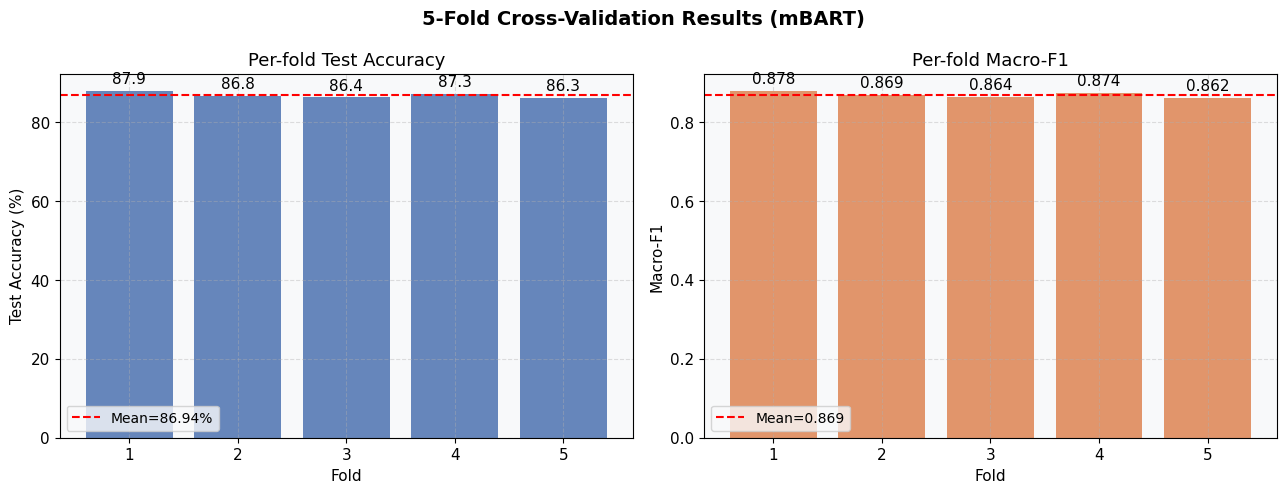

[Saved] plots/00_kfold_cross_validation.png

Train: 4344  Val: 543  Test: 543
Train class dist: {1: 1537, 2: 1392, 0: 1415}


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

[transformers] MBartModel LOAD REPORT from: facebook/mbart-large-50-many-to-many-mmt
Key               | Status     |  | 
------------------+------------+--+-
final_logits_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model parameters: 408,791,043  |  Trainable: 50,915,331  (12.5%)

── Parameter / freeze report ─────────────────────────
  Total params      : 408,791,043
  Frozen params     : 357,875,712  (87.5%)
  Trainable params  : 50,915,331  (12.5%)

  Embeddings        : FROZEN
  Encoder layers (12 total):
    Layer  0: FROZEN     (12,596,224 params)
    Layer  1: FROZEN     (12,596,224 params)
    Layer  2: FROZEN     (12,596,224 params)
    Layer  3: FROZEN     (12,596,224 params)
    Layer  4: FROZEN     (12,596,224 params)
    Layer  5: FROZEN     (12,596,224 params)
    Layer  6: FROZEN     (12,596,224 params)
    Layer  7: FROZEN     (12,596,224 params)
    Layer  8: trainable  (12,596,224 params)
    Layer  9: trainable  (12,596,224 params)
    Layer 10: trainable  (12,596,224 params)
    Layer 11: trainable  (12,596,224 params)
  Classifier head     : trainable  (526,339 params)
───────────────────────────────────────────────────────
 Epoch  Train Loss  Train Acc  Val Loss  Smoothed  V

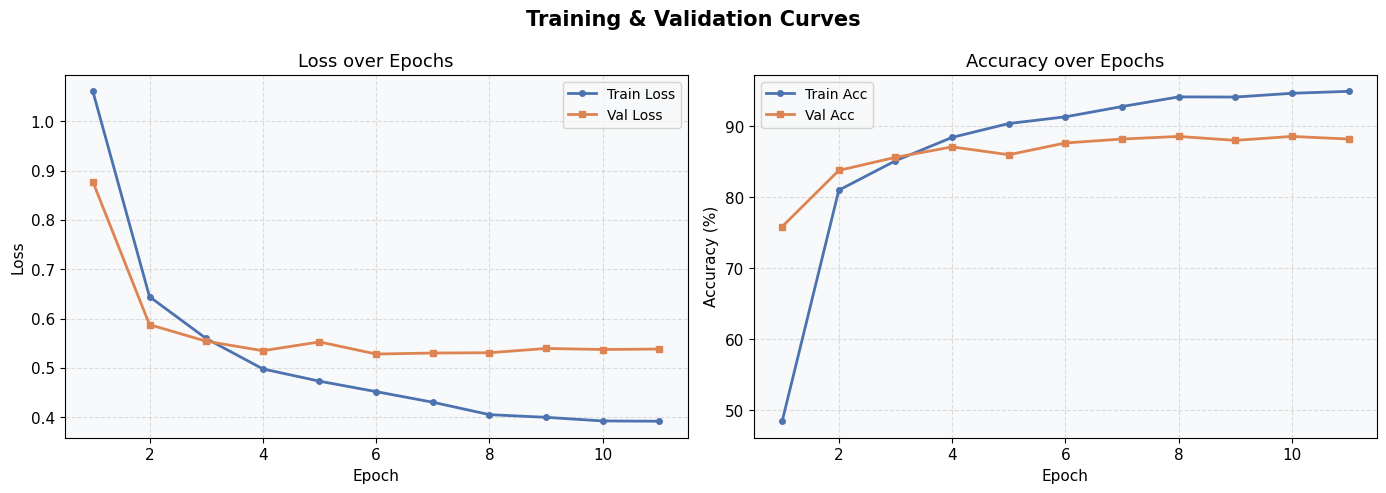

[Saved] plots/01_train_val_curves.png


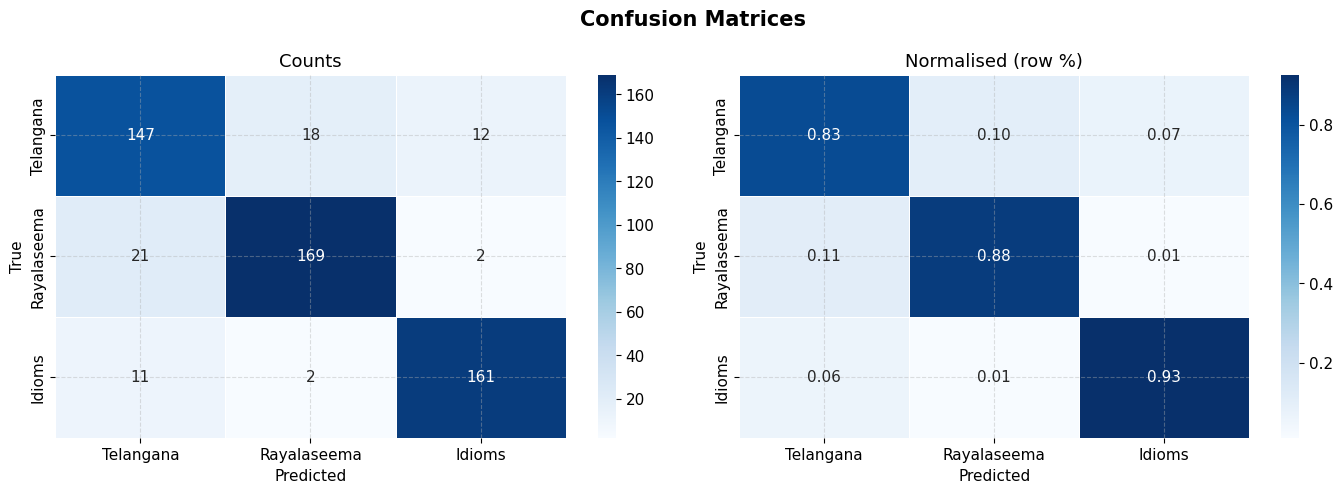

[Saved] plots/02_confusion_matrices.png


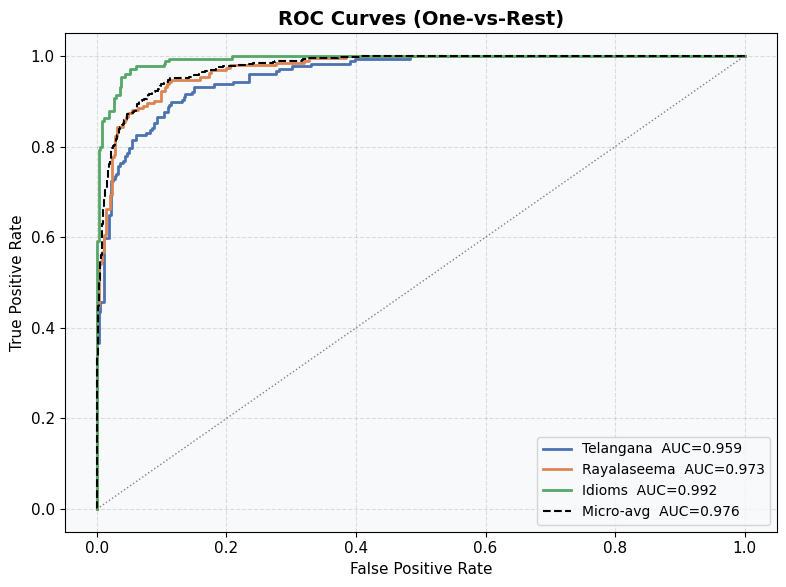

[Saved] plots/03_roc_curves.png


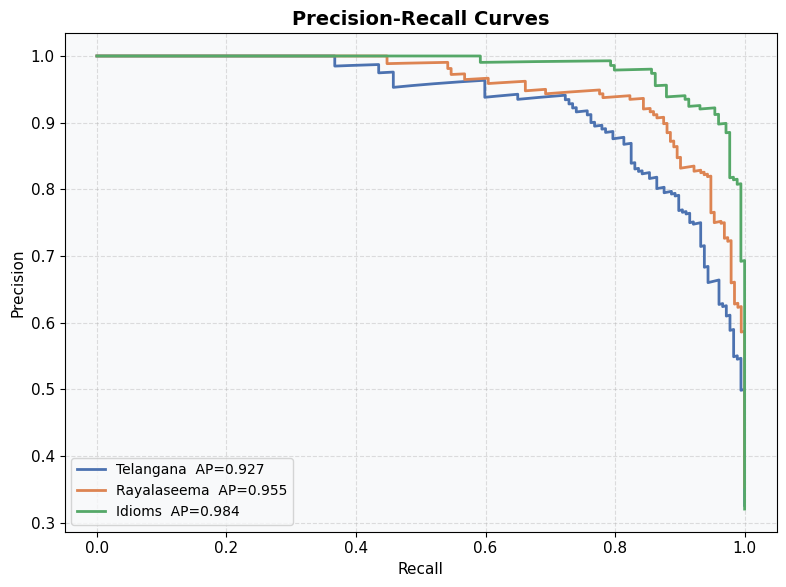

[Saved] plots/04_precision_recall_curves.png


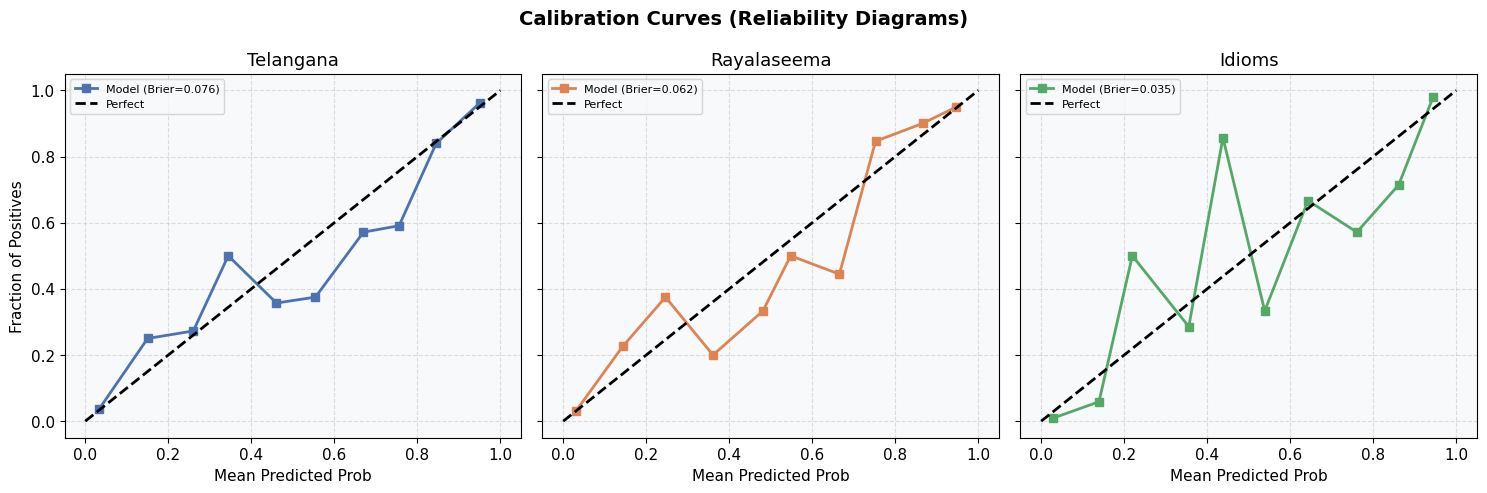

[Saved] plots/05_calibration_curves.png

  STATISTICAL ANALYSIS (bootstrap, n=1000, single split)

  Accuracy  : 87.85%   95% CI [85.08%, 90.61%]
  Macro-F1  : 0.8785   95% CI [0.8505, 0.9062]


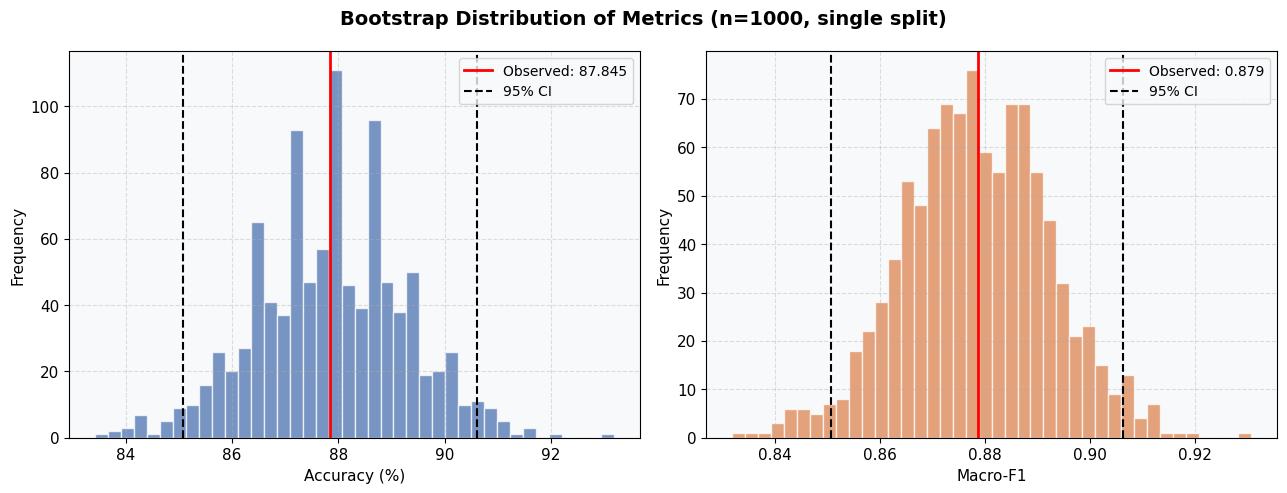

[Saved] plots/06_bootstrap_statistical_analysis.png

  ABLATION STUDY (mBART - freeze depth / dropout)

  > Baseline (freeze=10, drop=0.3) ...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

[transformers] MBartModel LOAD REPORT from: facebook/mbart-large-50-many-to-many-mmt
Key               | Status     |  | 
------------------+------------+--+-
final_logits_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Val=87.29%  Test=87.85%  MacroF1=0.8784  Trainable=50,915,331

  > Freeze=11 (minimal capacity) ...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

[transformers] MBartModel LOAD REPORT from: facebook/mbart-large-50-many-to-many-mmt
Key               | Status     |  | 
------------------+------------+--+-
final_logits_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Val=87.29%  Test=88.95%  MacroF1=0.8894  Trainable=50,915,331

  > Dropout=0.1 (lighter) ...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

[transformers] MBartModel LOAD REPORT from: facebook/mbart-large-50-many-to-many-mmt
Key               | Status     |  | 
------------------+------------+--+-
final_logits_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
"""
mBART-based Text Classifier — Fine-tuned from Pretrained Weights (v4)
Dataset: Telugu Dialect / Idiom Classification
  Rows 1-2084    -> Telangana   (label 0)
  Rows 2085-4215 -> Rayalaseema (label 1)
  Rows 4216-6011 -> Idioms      (label 2)

CHANGES FROM v3 (from-scratch transformer):
  - Replaces SentenceTokenizer + TransformerClassifier with a pretrained
    mBART-50 encoder ("facebook/mbart-large-50-many-to-many-mmt", which
    covers Telugu as te_IN) + a small mean-pooling classification head.
  - PARTIAL FREEZING: embeddings + the first FREEZE_ENCODER_LAYERS encoder
    layers are frozen; only the top few encoder layers + the new
    classifier head are trainable. Full fine-tuning of a 610M-param model
    on ~5,400 rows would overfit almost immediately and be far slower -
    freezing most of the network is the standard approach for small
    downstream datasets.
  - Fine-tuning LR is much lower than the from-scratch run (2e-5 vs 3e-4)
    and epochs/patience are reduced, since pretrained models converge
    (and overfit) much faster than models trained from scratch.
  - DATA PATH updated to "/content/classification model obj 4.xlsx".
  - K-fold CV is now GATED behind RUN_KFOLD (default False): it means K
    full mBART fine-tuning runs, which is very expensive. Get the main
    single-split run working first, then flip RUN_KFOLD=True once you
    have GPU time to spare. Ablation is trimmed to freeze-depth/dropout
    configs relevant to a pretrained model (not architecture depth,
    since that's now fixed by the pretrained checkpoint).

Requires (Colab):
  !pip install transformers sentencepiece --quiet
"""

# ─────────────────────────────────────────────
# 1. IMPORTS
# ─────────────────────────────────────────────
import os
import re
import math
import random
import warnings
import unicodedata
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
    average_precision_score, brier_score_loss,
    f1_score, accuracy_score
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import AutoTokenizer, MBartModel

import matplotlib
try:
    from IPython import get_ipython
    _IN_NOTEBOOK = get_ipython() is not None
except Exception:
    _IN_NOTEBOOK = False
if not _IN_NOTEBOOK:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 2. REPRODUCIBILITY
# ─────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ─────────────────────────────────────────────
# 3. CONFIGURATION
# ─────────────────────────────────────────────
EXCEL_FILE  = "/content/classification model obj 4.xlsx"   # <- updated path
TEXT_COL    = None

NUM_CLASSES = 3
MIN_TOKENS  = 2

# mBART settings
# mBART settings
MBART_MODEL_NAME      = "facebook/mbart-large-50-many-to-many-mmt"
MBART_LANG_CODE       = "te_IN"          # Telugu
MAX_SEQ_LEN           = 64
FREEZE_ENCODER_LAYERS = 8                # Set to 8 or 10 for your comparison test
DROPOUT               = 0.3
BATCH_SIZE            = 16
EPOCHS                = 12               # Raised from 6 to 12 so patience decides stopping
LR                    = 1e-5
WEIGHT_DECAY          = 0.02
PATIENCE              = 3                # Raised to 3 to accommodate a 12-epoch ceiling
TRAIN_TOKEN_DROPOUT   = 0.08
EARLY_STOP_SMOOTH_WINDOW = 3             # Raised to match patience

# Which heavy analyses to run
RUN_KFOLD      = True     # Flip to True for Step 2 & 3
RUN_ABLATION   = True
RUN_ROBUSTNESS = True
K_FOLDS        = 5

ID2LABEL = {0: "Telangana", 1: "Rayalaseema", 2: "Idioms"}
COLORS   = ["#4C72B0", "#DD8452", "#55A868"]

PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# ─────────────────────────────────────────────
# 4. PLOT STYLE HELPER
# ─────────────────────────────────────────────
def set_style():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor"  : "#F8F9FA",
        "axes.grid"       : True,
        "grid.alpha"      : 0.4,
        "grid.linestyle"  : "--",
        "font.size"       : 11,
        "axes.titlesize"  : 13,
        "axes.labelsize"  : 11,
        "legend.fontsize" : 10,
        "lines.linewidth" : 2,
    })

set_style()

def save_fig(name: str):
    path = os.path.join(PLOT_DIR, f"{name}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    if _IN_NOTEBOOK:
        plt.show()
    plt.close()
    print(f"[Saved] {path}")

# ─────────────────────────────────────────────
# 5. DATA LOADING + CLEANING / DEDUP
# ─────────────────────────────────────────────
def _clean_text(t: str) -> str:
    t = unicodedata.normalize("NFC", str(t))
    t = t.strip().lower()
    t = re.sub(r"[^\u0C00-\u0C7Fa-z0-9\s\u0964,.!?'-]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

def clean_and_dedupe(df: pd.DataFrame) -> pd.DataFrame:
    orig_n = len(df)
    df = df.copy()
    df["text"] = df["text"].apply(_clean_text)

    df = df[df["text"].str.len() > 0]
    df = df[df["text"].str.split().str.len() >= MIN_TOKENS]
    after_empty = len(df)

    before_dupe = len(df)
    df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
    exact_dupes_removed = before_dupe - len(df)

    dupe_mask   = df.duplicated(subset=["text"], keep=False)
    conflict_ct = df[dupe_mask].groupby("text")["label"].nunique()
    conflict_texts = set(conflict_ct[conflict_ct > 1].index)
    before_conflict = len(df)
    df = df[~df["text"].isin(conflict_texts)].reset_index(drop=True)
    conflicts_removed = before_conflict - len(df)

    print("\n── Data cleaning report ──────────────────────────")
    print(f"  Original rows            : {orig_n}")
    print(f"  Removed empty/too-short  : {orig_n - after_empty}")
    print(f"  Removed exact duplicates : {exact_dupes_removed}")
    print(f"  Removed label-conflicts  : {conflicts_removed}  (same text, different label)")
    print(f"  Final rows               : {len(df)}")
    print(f"  Final class distribution : {dict(Counter(df['label'].tolist()))}")
    print("────────────────────────────────────────────────────")
    return df

def load_data(path: str) -> pd.DataFrame:
    print(f"\nLoading data from: {path}")
    df = pd.read_excel(path, header=None)
    print(f"  Raw shape: {df.shape}")

    text_col = TEXT_COL
    if text_col is None:
        best_col, best_len = None, 0
        for c in df.columns:
            avg = df[c].astype(str).str.len().mean()
            if avg > best_len:
                best_len, best_col = avg, c
        text_col = best_col
        print(f"  Auto-selected text column: {text_col}")

    n = len(df)
    labels = []
    for i in range(n):
        row_num = i + 1
        if   1    <= row_num <= 2084: labels.append(0)
        elif 2085 <= row_num <= 4215: labels.append(1)
        elif 4216 <= row_num <= 6011: labels.append(2)
        else:                         labels.append(-1)

    df["label"] = labels
    df["text"]  = df[text_col].astype(str)
    df = df[df["label"] != -1].reset_index(drop=True)
    df = df[["text", "label"]]

    df = clean_and_dedupe(df)
    return df

# ─────────────────────────────────────────────
# 6. mBART TOKENIZER + DATASETS
# ─────────────────────────────────────────────
def load_mbart_tokenizer():
    tok = AutoTokenizer.from_pretrained(MBART_MODEL_NAME)
    tok.src_lang = MBART_LANG_CODE
    return tok

def _word_dropout(text: str, p: float, unk: str) -> str:
    if p <= 0:
        return text
    words = text.split()
    words = [w if random.random() > p else unk for w in words]
    return " ".join(words)

class MBartTextDataset(Dataset):
    """Static, pre-tokenized dataset - use for val/test (deterministic)."""
    def __init__(self, texts, labels, tokenizer, max_len=MAX_SEQ_LEN):
        enc = tokenizer(texts, truncation=True, padding="max_length",
                         max_length=max_len, return_tensors="pt")
        self.input_ids      = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels         = labels

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return (
            self.input_ids[idx],
            self.attention_mask[idx],
            torch.tensor(self.labels[idx], dtype=torch.long),
        )

class MBartAugmentedTrainDataset(Dataset):
    """Re-tokenizes on the fly with light word dropout - TRAIN only."""
    def __init__(self, texts, labels, tokenizer, max_len=MAX_SEQ_LEN, token_dropout=TRAIN_TOKEN_DROPOUT):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len
        self.p         = token_dropout
        self.unk       = tokenizer.unk_token or "<unk>"

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        text = _word_dropout(self.texts[idx], self.p, self.unk)
        enc = self.tokenizer(text, truncation=True, padding="max_length",
                              max_length=self.max_len, return_tensors="pt")
        return (
            enc["input_ids"].squeeze(0),
            enc["attention_mask"].squeeze(0),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )

def make_weighted_sampler(labels):
    counts = Counter(labels)
    class_w = {c: 1.0 / counts[c] for c in counts}
    sample_w = [class_w[l] for l in labels]
    return WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)

# ─────────────────────────────────────────────
# 7. MODEL: PARTIALLY-FROZEN mBART ENCODER + CLASSIFIER
# ─────────────────────────────────────────────
class MBartClassifier(nn.Module):
    def __init__(self, mbart_name=MBART_MODEL_NAME, num_classes=NUM_CLASSES,
                 dropout=DROPOUT, freeze_layers=FREEZE_ENCODER_LAYERS):
        super().__init__()
        backbone = MBartModel.from_pretrained(mbart_name)
        self.encoder = backbone.get_encoder()
        hidden = backbone.config.d_model

        for p in self.encoder.embed_tokens.parameters():
            p.requires_grad = False
        if hasattr(self.encoder, "embed_positions"):
            for p in self.encoder.embed_positions.parameters():
                p.requires_grad = False
        for i, layer in enumerate(self.encoder.layers):
            if i < freeze_layers:
                for p in layer.parameters():
                    p.requires_grad = False

        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden // 2, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        h = out.last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (h * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        pooled = self.dropout(pooled)
        return self.classifier(pooled)

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel parameters: {total:,}  |  Trainable: {train:,}  ({100*train/total:.1f}%)")

def report_parameters(model: "MBartClassifier"):
    """Prints exactly which layers are frozen vs trainable, so freezing can be
    VERIFIED rather than assumed. Call this once after building the model."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable
    print("\n── Parameter / freeze report ─────────────────────────")
    print(f"  Total params      : {total:,}")
    print(f"  Frozen params     : {frozen:,}  ({100*frozen/total:.1f}%)")
    print(f"  Trainable params  : {trainable:,}  ({100*trainable/total:.1f}%)")
    print(f"\n  Embeddings        : {'FROZEN' if not any(p.requires_grad for p in model.encoder.embed_tokens.parameters()) else 'trainable'}")
    print(f"  Encoder layers ({len(model.encoder.layers)} total):")
    for i, layer in enumerate(model.encoder.layers):
        is_trainable = any(p.requires_grad for p in layer.parameters())
        n = sum(p.numel() for p in layer.parameters())
        print(f"    Layer {i:2d}: {'trainable' if is_trainable else 'FROZEN   '}  ({n:,} params)")
    n_cls = sum(p.numel() for p in model.classifier.parameters())
    print(f"  Classifier head     : trainable  ({n_cls:,} params)")
    print("───────────────────────────────────────────────────────")

# ─────────────────────────────────────────────
# 8. TRAINING UTILITIES
# ─────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, scheduler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for ids, mask, labels in loader:
        ids, mask, labels = ids.to(DEVICE), mask.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(ids, mask)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item() * ids.size(0)
        correct    += (logits.argmax(-1) == labels).sum().item()
        total      += ids.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, return_probs=False):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for ids, mask, labels in loader:
        ids, mask, labels = ids.to(DEVICE), mask.to(DEVICE), labels.to(DEVICE)
        logits = model(ids, mask)
        loss = criterion(logits, labels)
        total_loss += loss.item() * ids.size(0)
        probs  = torch.softmax(logits, -1)
        preds  = probs.argmax(-1)
        correct += (preds == labels).sum().item()
        total   += ids.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())
    if return_probs:
        return total_loss/total, correct/total, all_preds, all_labels, all_probs
    return total_loss/total, correct/total, all_preds, all_labels

def build_optimizer_scheduler(model, train_dl, epochs, lr=LR, weight_decay=WEIGHT_DECAY):
    trainable = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = optim.AdamW(trainable, lr=lr, weight_decay=weight_decay)
    total_steps  = max(1, len(train_dl) * epochs)
    warmup_steps = max(1, total_steps // 10)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * prog)))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    return optimizer, scheduler

def train_with_early_stopping(model, train_dl, val_dl, criterion, epochs=EPOCHS,
                               patience=PATIENCE, ckpt_path=None, verbose=True):
    """Early stopping compares a SMOOTHED validation loss (mean of the last
    EARLY_STOP_SMOOTH_WINDOW epochs) rather than the raw per-epoch value.
    mBART fine-tuning on a small dataset converges fast and then the raw val
    loss bounces around its minimum (e.g. 0.55 -> 0.60 -> 0.56 -> 0.58) - an
    unsmoothed check would treat that as "no longer improving" one epoch too
    early, or worse, occasionally treat noise as a fresh best checkpoint."""
    optimizer, scheduler = build_optimizer_scheduler(model, train_dl, epochs)
    best_val_loss = float("inf")
    best_val_acc  = 0.0
    best_state    = None
    patience_cnt  = 0
    val_loss_hist = []
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    if verbose:
        print("="*65)
        print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Smoothed':>8}  {'Val Acc':>7}")
        print("="*65)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_dl, criterion, optimizer, scheduler)
        va_loss, va_acc, _, _ = evaluate(model, val_dl, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        val_loss_hist.append(va_loss)
        smoothed_val_loss = float(np.mean(val_loss_hist[-EARLY_STOP_SMOOTH_WINDOW:]))

        if verbose:
            print(f"{epoch:>6}  {tr_loss:>10.4f}  {tr_acc*100:>8.2f}%  {va_loss:>8.4f}  {smoothed_val_loss:>8.4f}  {va_acc*100:>6.2f}%")

        if smoothed_val_loss < best_val_loss - 1e-4:
            best_val_loss = smoothed_val_loss
            best_val_acc  = va_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
            if ckpt_path:
                torch.save(model.state_dict(), ckpt_path)
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                if verbose:
                    print(f"\nEarly stopping at epoch {epoch}. "
                          f"Best smoothed val loss: {best_val_loss:.4f} (val acc {best_val_acc*100:.2f}%)")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_val_acc, best_val_loss

# ─────────────────────────────────────────────
# 9. K-FOLD CV (gated by RUN_KFOLD - K full mBART fine-tunes)
# ─────────────────────────────────────────────
def run_stratified_kfold(texts, labels, tokenizer, k=K_FOLDS, epochs=EPOCHS, patience=PATIENCE):
    print("\n" + "="*60)
    print(f"  STRATIFIED {k}-FOLD CROSS-VALIDATION (mBART)")
    print("="*60)

    texts_arr  = np.array(texts, dtype=object)
    labels_arr = np.array(labels)
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    fold_rows = []
    for fold_idx, (trainval_idx, test_idx) in enumerate(skf.split(texts_arr, labels_arr), start=1):
        print(f"\n  --- Fold {fold_idx}/{k} ---")
        X_trainval = texts_arr[trainval_idx].tolist()
        y_trainval = labels_arr[trainval_idx].tolist()
        X_test_f   = texts_arr[test_idx].tolist()
        y_test_f   = labels_arr[test_idx].tolist()

        X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(
            X_trainval, y_trainval, test_size=0.12, random_state=SEED, stratify=y_trainval)

        train_ds = MBartAugmentedTrainDataset(X_train_f, y_train_f, tokenizer)
        val_ds   = MBartTextDataset(X_val_f,  y_val_f,  tokenizer)
        test_ds  = MBartTextDataset(X_test_f, y_test_f, tokenizer)

        sampler  = make_weighted_sampler(y_train_f)
        train_dl = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0)
        val_dl   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0)
        test_dl  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0)

        model = MBartClassifier().to(DEVICE)
        model, _, best_va, _ = train_with_early_stopping(
            model, train_dl, val_dl, criterion, epochs=epochs, patience=patience, verbose=False)

        _, te_acc, preds, gold = evaluate(model, test_dl, criterion)
        f1_macro = f1_score(gold, preds, average="macro", zero_division=0)
        print(f"    Val Acc={best_va*100:.2f}%  Test Acc={te_acc*100:.2f}%  Macro-F1={f1_macro:.4f}")
        fold_rows.append({"Fold": fold_idx, "Val Acc": best_va*100, "Test Acc": te_acc*100, "Macro-F1": f1_macro})

        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    df_kfold = pd.DataFrame(fold_rows)
    print("\n" + df_kfold.to_string(index=False))
    acc_mean, acc_std = df_kfold["Test Acc"].mean(), df_kfold["Test Acc"].std()
    f1_mean,  f1_std  = df_kfold["Macro-F1"].mean(), df_kfold["Macro-F1"].std()
    print(f"\n  >>> {k}-Fold Test Accuracy : {acc_mean:.2f}% +/- {acc_std:.2f}%  <<<")
    print(f"  >>> {k}-Fold Macro-F1      : {f1_mean:.4f} +/- {f1_std:.4f}  <<<")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"{k}-Fold Cross-Validation Results (mBART)", fontsize=14, fontweight="bold")
    ax = axes[0]
    bars = ax.bar(df_kfold["Fold"].astype(str), df_kfold["Test Acc"], color="#4C72B0", alpha=0.85)
    ax.axhline(acc_mean, color="red", ls="--", lw=1.5, label=f"Mean={acc_mean:.2f}%")
    ax.bar_label(bars, fmt="%.1f", padding=3)
    ax.set_xlabel("Fold"); ax.set_ylabel("Test Accuracy (%)"); ax.set_title("Per-fold Test Accuracy"); ax.legend()
    ax = axes[1]
    bars = ax.bar(df_kfold["Fold"].astype(str), df_kfold["Macro-F1"], color="#DD8452", alpha=0.85)
    ax.axhline(f1_mean, color="red", ls="--", lw=1.5, label=f"Mean={f1_mean:.3f}")
    ax.bar_label(bars, fmt="%.3f", padding=3)
    ax.set_xlabel("Fold"); ax.set_ylabel("Macro-F1"); ax.set_title("Per-fold Macro-F1"); ax.legend()
    plt.tight_layout()
    save_fig("00_kfold_cross_validation")

    return df_kfold, acc_mean, acc_std, f1_mean, f1_std

# ─────────────────────────────────────────────
# 10. ANALYSIS / PLOTTING (unchanged in spirit from v3)
# ─────────────────────────────────────────────
def plot_train_val_curves(history: dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training & Validation Curves", fontsize=15, fontweight="bold")
    epochs = range(1, len(history["train_loss"]) + 1)
    ax = axes[0]
    ax.plot(epochs, history["train_loss"], color="#4C72B0", label="Train Loss", marker="o", ms=4)
    ax.plot(epochs, history["val_loss"],   color="#DD8452", label="Val Loss",   marker="s", ms=4)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title("Loss over Epochs"); ax.legend()
    ax = axes[1]
    ax.plot(epochs, [a*100 for a in history["train_acc"]], color="#4C72B0", label="Train Acc", marker="o", ms=4)
    ax.plot(epochs, [a*100 for a in history["val_acc"]],   color="#DD8452", label="Val Acc",   marker="s", ms=4)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)"); ax.set_title("Accuracy over Epochs"); ax.legend()
    plt.tight_layout()
    save_fig("01_train_val_curves")

def plot_confusion_matrix(y_true, y_pred):
    cm    = confusion_matrix(y_true, y_pred)
    cm_n  = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Confusion Matrices", fontsize=15, fontweight="bold")
    for ax, data, title, fmt in zip(axes, [cm, cm_n], ["Counts", "Normalised (row %)"], ["d", ".2f"]):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues", xticklabels=labels, yticklabels=labels, linewidths=0.5, ax=ax)
        ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout()
    save_fig("02_confusion_matrices")

def plot_roc_curves(y_true, y_probs):
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    y_arr = np.array(y_probs)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title("ROC Curves (One-vs-Rest)", fontsize=14, fontweight="bold")
    for i, (label, color) in enumerate(zip(labels, COLORS)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_arr[:, i])
        ax.plot(fpr, tpr, color=color, label=f"{label}  AUC={auc(fpr, tpr):.3f}")
    fpr_m, tpr_m, _ = roc_curve(y_bin.ravel(), y_arr.ravel())
    ax.plot(fpr_m, tpr_m, "k--", label=f"Micro-avg  AUC={auc(fpr_m,tpr_m):.3f}", lw=1.5)
    ax.plot([0,1],[0,1],"grey", ls=":", lw=1)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate"); ax.legend(loc="lower right")
    plt.tight_layout()
    save_fig("03_roc_curves")

def plot_precision_recall_curves(y_true, y_probs):
    y_bin  = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    y_arr  = np.array(y_probs)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title("Precision-Recall Curves", fontsize=14, fontweight="bold")
    for i, (label, color) in enumerate(zip(labels, COLORS)):
        prec, rec, _ = precision_recall_curve(y_bin[:, i], y_arr[:, i])
        ap = average_precision_score(y_bin[:, i], y_arr[:, i])
        ax.plot(rec, prec, color=color, label=f"{label}  AP={ap:.3f}")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.legend()
    plt.tight_layout()
    save_fig("04_precision_recall_curves")

def plot_calibration_curves(y_true, y_probs):
    y_bin  = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    y_arr  = np.array(y_probs)
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(15, 5), sharey=True)
    fig.suptitle("Calibration Curves (Reliability Diagrams)", fontsize=14, fontweight="bold")
    for i, (ax, label, color) in enumerate(zip(axes, labels, COLORS)):
        prob_true, prob_pred = calibration_curve(y_bin[:, i], y_arr[:, i], n_bins=10)
        brier = brier_score_loss(y_bin[:, i], y_arr[:, i])
        ax.plot(prob_pred, prob_true, "s-", color=color, label=f"Model (Brier={brier:.3f})")
        ax.plot([0,1],[0,1],"k--", label="Perfect")
        ax.set_title(label); ax.set_xlabel("Mean Predicted Prob")
        if i == 0: ax.set_ylabel("Fraction of Positives")
        ax.legend(fontsize=8)
    plt.tight_layout()
    save_fig("05_calibration_curves")

def statistical_analysis(y_true, y_pred, y_probs, n_bootstrap=1000):
    print("\n" + "="*60)
    print("  STATISTICAL ANALYSIS (bootstrap, n=1000, single split)")
    print("="*60)
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    acc_boot, f1_boot = [], []
    rng = np.random.RandomState(SEED)
    for _ in range(n_bootstrap):
        idx = rng.randint(0, len(y_true), len(y_true))
        acc_boot.append(accuracy_score(y_true[idx], y_pred[idx]))
        f1_boot.append(f1_score(y_true[idx], y_pred[idx], average="macro", zero_division=0))
    acc_boot, f1_boot = np.array(acc_boot), np.array(f1_boot)
    def ci95(arr): return np.percentile(arr, [2.5, 97.5])
    obs_acc, obs_f1 = accuracy_score(y_true, y_pred), f1_score(y_true, y_pred, average="macro", zero_division=0)
    print(f"\n  Accuracy  : {obs_acc*100:.2f}%   95% CI [{ci95(acc_boot)[0]*100:.2f}%, {ci95(acc_boot)[1]*100:.2f}%]")
    print(f"  Macro-F1  : {obs_f1:.4f}   95% CI [{ci95(f1_boot)[0]:.4f}, {ci95(f1_boot)[1]:.4f}]")
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Bootstrap Distribution of Metrics (n=1000, single split)", fontsize=14, fontweight="bold")
    for ax, data, title, obs, color in zip(axes, [acc_boot*100, f1_boot], ["Accuracy (%)", "Macro-F1"],
                                            [obs_acc*100, obs_f1], ["#4C72B0", "#DD8452"]):
        ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor="white")
        ax.axvline(obs, color="red", ls="-", lw=2, label=f"Observed: {obs:.3f}")
        ax.axvline(ci95(data)[0], color="black", ls="--", lw=1.5, label="95% CI")
        ax.axvline(ci95(data)[1], color="black", ls="--", lw=1.5)
        ax.set_xlabel(title); ax.set_ylabel("Frequency"); ax.legend()
    plt.tight_layout()
    save_fig("06_bootstrap_statistical_analysis")

def ablation_study(X_train, X_val, X_test, y_train, y_val, y_test, tokenizer):
    """Trimmed vs v3: architecture depth is now fixed by the pretrained
    checkpoint, so ablation varies the things that actually matter for a
    fine-tuned pretrained model - how much of it is frozen, and dropout."""
    print("\n" + "="*60)
    print("  ABLATION STUDY (mBART - freeze depth / dropout)")
    print("="*60)

    configs = [
        {"name": "Baseline (freeze=10, drop=0.3)", "freeze": FREEZE_ENCODER_LAYERS, "drop": DROPOUT},
        {"name": "Freeze=11 (minimal capacity)",    "freeze": 11,                    "drop": DROPOUT},
        {"name": "Freeze=8 (old default, more capacity)", "freeze": 8,               "drop": DROPOUT},
        {"name": "Dropout=0.1 (lighter)",           "freeze": FREEZE_ENCODER_LAYERS, "drop": 0.1},
        {"name": "Dropout=0.5 (heavier)",           "freeze": FREEZE_ENCODER_LAYERS, "drop": 0.5},
    ]

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    train_ds = MBartAugmentedTrainDataset(X_train, y_train, tokenizer)
    val_ds   = MBartTextDataset(X_val,  y_val,  tokenizer)
    test_ds  = MBartTextDataset(X_test, y_test, tokenizer)
    sampler  = make_weighted_sampler(y_train)
    train_dl = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0)
    val_dl   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0)
    test_dl  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0)

    results = []
    for cfg in configs:
        print(f"\n  > {cfg['name']} ...")
        model = MBartClassifier(freeze_layers=cfg["freeze"], dropout=cfg["drop"]).to(DEVICE)
        model, _, best_va, _ = train_with_early_stopping(
            model, train_dl, val_dl, criterion, epochs=EPOCHS, patience=PATIENCE, verbose=False)
        _, te_acc, preds, gold = evaluate(model, test_dl, criterion)
        f1 = f1_score(gold, preds, average="macro", zero_division=0)
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"    Val={best_va*100:.2f}%  Test={te_acc*100:.2f}%  MacroF1={f1:.4f}  Trainable={trainable:,}")
        results.append({"Config": cfg["name"], "Val Acc": best_va*100, "Test Acc": te_acc*100,
                        "Macro-F1": f1, "Trainable Params": trainable})
        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    df_abl = pd.DataFrame(results)
    print("\n" + df_abl.to_string(index=False))

    fig, axes = plt.subplots(1, 3, figsize=(17, 6))
    fig.suptitle("Ablation Study Results (mBART)", fontsize=14, fontweight="bold")
    palette = sns.color_palette("muted", len(df_abl))
    for ax, col, title in zip(axes, ["Val Acc", "Test Acc", "Macro-F1"],
                               ["Validation Accuracy (%)", "Test Accuracy (%)", "Macro-F1"]):
        bars = ax.barh(df_abl["Config"], df_abl[col], color=palette)
        ax.set_xlabel(title); ax.set_title(title)
        ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
        for bar, name in zip(bars, df_abl["Config"]):
            if "Baseline" in name:
                bar.set_edgecolor("red"); bar.set_linewidth(2)
    plt.tight_layout()
    save_fig("07_ablation_study")
    return df_abl

def robustness_analysis(model, tokenizer, X_test, y_test):
    print("\n" + "="*60)
    print("  ROBUSTNESS ANALYSIS")
    print("="*60)

    def _perturb_token_drop(texts, p):
        random.seed(SEED)  # reseed per level: makes each level's noise draw independent
                            # and reproducible, instead of depending on how much of the
                            # random stream prior levels/epochs already consumed
        return [_word_dropout(t, p, tokenizer.unk_token or "<unk>") for t in texts]

    def _perturb_char(texts, p):
        random.seed(SEED)
        def swap_chars(word):
            if len(word) < 2: return word
            w = list(word)
            for i in range(len(w)-1):
                if random.random() < p:
                    w[i], w[i+1] = w[i+1], w[i]
            return "".join(w)
        return [" ".join(swap_chars(w) for w in t.split()) for t in texts]

    def _perturb_trunc(texts, k):
        out = []
        for t in texts:
            words = t.split()
            keep  = max(1, int(len(words) * k))
            out.append(" ".join(words[:keep]))
        return out

    y_arr = np.array(y_test)
    model.eval()

    @torch.no_grad()
    def _accuracy(texts):
        ds = MBartTextDataset(texts, [0]*len(texts), tokenizer)
        loader = DataLoader(ds, BATCH_SIZE, shuffle=False)
        all_preds = []
        for ids, mask, _ in loader:
            ids, mask = ids.to(DEVICE), mask.to(DEVICE)
            all_preds.extend(torch.softmax(model(ids, mask), -1).argmax(-1).cpu().tolist())
        return accuracy_score(y_arr, all_preds) * 100

    rows = []
    baseline_acc = _accuracy(X_test)
    rows.append({"Perturbation": "Baseline (clean)", "Level": "-", "Accuracy": baseline_acc})
    print(f"  Baseline accuracy: {baseline_acc:.2f}%")

    for p in [0.1, 0.2, 0.4]:
        acc = _accuracy(_perturb_token_drop(X_test, p))
        rows.append({"Perturbation": f"Token Drop p={p}", "Level": str(p), "Accuracy": acc})
        print(f"  Token Drop p={p}: {acc:.2f}%")
    for p in [0.1, 0.2, 0.4]:
        acc = _accuracy(_perturb_char(X_test, p))
        rows.append({"Perturbation": f"Char Noise p={p}", "Level": str(p), "Accuracy": acc})
        print(f"  Char Noise p={p}: {acc:.2f}%")
    for k in [0.75, 0.50, 0.25]:
        acc = _accuracy(_perturb_trunc(X_test, k))
        rows.append({"Perturbation": f"Truncate k={k}", "Level": str(k), "Accuracy": acc})
        print(f"  Truncation k={k}: {acc:.2f}%")

    df_rob = pd.DataFrame(rows)
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Robustness Analysis: Accuracy under Input Perturbations", fontsize=14, fontweight="bold")
    groups = [("Token Drop", "Token Drop", [0.1, 0.2, 0.4]),
              ("Char Noise", "Char Noise", [0.1, 0.2, 0.4]),
              ("Truncation", "Truncate",   [0.75, 0.50, 0.25])]
    for ax, (name, prefix, levels) in zip(axes, groups):
        accs = [df_rob.loc[df_rob["Perturbation"].str.startswith(prefix) & df_rob["Level"].eq(str(l)), "Accuracy"].values[0]
                for l in levels]
        ax.axhline(baseline_acc, color="red", ls="--", lw=1.5, label=f"Baseline {baseline_acc:.1f}%")
        ax.plot(levels, accs, "o-", color="#4C72B0", ms=8)
        for l, a in zip(levels, accs):
            ax.annotate(f"{a:.1f}%", (l, a), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
        ax.set_title(name); ax.set_xlabel("Level"); ax.set_ylabel("Accuracy (%)")
        ax.legend(); ax.set_ylim(max(0, min(accs)-10), 105)
    plt.tight_layout()
    save_fig("08_robustness_analysis")
    return df_rob

def plot_complete_results_summary(y_true, y_pred, y_probs, history):
    labels = [ID2LABEL[i] for i in range(NUM_CLASSES)]
    y_arr  = np.array(y_probs)
    report = classification_report(y_true, y_pred, target_names=labels, output_dict=True, zero_division=0)

    fig = plt.figure(figsize=(18, 14))
    fig.suptitle("Complete Results Analysis Dashboard (mBART, single split)", fontsize=16, fontweight="bold", y=1.01)
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

    ax = fig.add_subplot(gs[0, 0])
    true_counts, pred_counts = Counter(y_true), Counter(y_pred)
    x = np.arange(NUM_CLASSES); w = 0.35
    ax.bar(x - w/2, [true_counts[i] for i in range(NUM_CLASSES)], w, label="True", color="#4C72B0", alpha=0.85)
    ax.bar(x + w/2, [pred_counts[i] for i in range(NUM_CLASSES)], w, label="Pred", color="#DD8452", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title("Class Distribution: True vs Predicted"); ax.set_ylabel("Count"); ax.legend()

    ax = fig.add_subplot(gs[0, 1])
    metrics = ["precision", "recall", "f1-score"]; x = np.arange(NUM_CLASSES); w = 0.25
    pal = ["#4C72B0", "#DD8452", "#55A868"]
    for j, (m, c) in enumerate(zip(metrics, pal)):
        vals = [report[lbl][m] for lbl in labels]
        ax.bar(x + j*w - w, vals, w, label=m.capitalize(), color=c, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title("Per-class Precision / Recall / F1"); ax.set_ylim(0, 1.15); ax.legend(); ax.set_ylabel("Score")

    ax = fig.add_subplot(gs[0, 2])
    parts = ax.violinplot([y_arr[:, i] for i in range(NUM_CLASSES)], positions=range(NUM_CLASSES), showmedians=True)
    for pc, c in zip(parts["bodies"], COLORS):
        pc.set_facecolor(c); pc.set_alpha(0.75)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title("Predicted Probability Distributions"); ax.set_ylabel("Probability")

    epochs = range(1, len(history["train_loss"]) + 1)
    ax = fig.add_subplot(gs[1, 0])
    ax.plot(epochs, history["train_loss"], "#4C72B0", label="Train", marker="o", ms=3)
    ax.plot(epochs, history["val_loss"],   "#DD8452", label="Val",   marker="s", ms=3)
    ax.set_title("Loss Curve"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend()

    ax = fig.add_subplot(gs[1, 1])
    ax.plot(epochs, [a*100 for a in history["train_acc"]], "#4C72B0", label="Train", marker="o", ms=3)
    ax.plot(epochs, [a*100 for a in history["val_acc"]],   "#DD8452", label="Val",   marker="s", ms=3)
    ax.set_title("Accuracy Curve"); ax.set_xlabel("Epoch"); ax.set_ylabel("Acc (%)"); ax.legend()

    ax = fig.add_subplot(gs[1, 2]); ax.axis("off")
    summary_data = [
        ["Metric", "Value"],
        ["Accuracy", f"{accuracy_score(y_true,y_pred)*100:.2f}%"],
        ["Macro Precision", f"{report['macro avg']['precision']:.4f}"],
        ["Macro Recall",    f"{report['macro avg']['recall']:.4f}"],
        ["Macro F1",        f"{report['macro avg']['f1-score']:.4f}"],
        ["Weighted F1",     f"{report['weighted avg']['f1-score']:.4f}"],
    ]
    tbl = ax.table(cellText=summary_data[1:], colLabels=summary_data[0], loc="center", cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.8)
    ax.set_title("Overall Metrics Summary", pad=12)

    ax = fig.add_subplot(gs[2, 0])
    max_probs = y_arr.max(axis=1); correct = (np.array(y_pred) == np.array(y_true))
    ax.hist(max_probs[correct],  bins=20, alpha=0.7, color="#55A868", label="Correct")
    ax.hist(max_probs[~correct], bins=20, alpha=0.7, color="#C44E52", label="Wrong")
    ax.set_title("Confidence (Max Prob) Distribution"); ax.set_xlabel("Max Predicted Probability"); ax.set_ylabel("Count"); ax.legend()

    ax = fig.add_subplot(gs[2, 1])
    n_bins = 10; bin_edges = np.linspace(0, 1, n_bins + 1); ece_vals = []
    for i in range(NUM_CLASSES):
        y_bin_i = (np.array(y_true) == i).astype(int); p_i = y_arr[:, i]; ece = 0.0
        for b in range(n_bins):
            mask = (p_i >= bin_edges[b]) & (p_i < bin_edges[b+1])
            if mask.sum() == 0: continue
            ece += mask.sum() * abs(y_bin_i[mask].mean() - p_i[mask].mean())
        ece_vals.append(ece / len(y_true))
    bars = ax.bar(labels, ece_vals, color=COLORS, alpha=0.85)
    ax.bar_label(bars, fmt="%.4f", padding=3)
    ax.set_title("Expected Calibration Error (ECE) per Class"); ax.set_ylabel("ECE (lower is better)")

    ax = fig.add_subplot(gs[2, 2])
    support = [report[lbl]["support"] for lbl in labels]
    ax.bar(labels, support, color=COLORS, alpha=0.85)
    for j, s in enumerate(support):
        ax.text(j, s + 1, str(s), ha="center", fontsize=10)
    ax.set_title("Test-set Support per Class"); ax.set_ylabel("Number of Samples")

    plt.tight_layout()
    save_fig("09_complete_results_dashboard")

# ─────────────────────────────────────────────
# 11. MAIN
# ─────────────────────────────────────────────
def main():
    df = load_data(EXCEL_FILE)
    texts, labels = df["text"].tolist(), df["label"].tolist()

    print(f"\nLoading tokenizer/model: {MBART_MODEL_NAME}  (lang={MBART_LANG_CODE})")
    tokenizer = load_mbart_tokenizer()

    if RUN_KFOLD:
        df_kfold, kfold_acc_mean, kfold_acc_std, kfold_f1_mean, kfold_f1_std = \
            run_stratified_kfold(texts, labels, tokenizer, k=K_FOLDS, epochs=EPOCHS, patience=PATIENCE)
    else:
        print("\n[RUN_KFOLD=False] Skipping k-fold CV - set RUN_KFOLD=True once the "
              "single-split run below looks good (it means K full mBART fine-tunes).")
        df_kfold = None

    X_train, X_tmp, y_train, y_tmp = train_test_split(
        texts, labels, test_size=0.2, random_state=SEED, stratify=labels)
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp)
    print(f"\nTrain: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
    print(f"Train class dist: {dict(Counter(y_train))}")

    train_ds = MBartAugmentedTrainDataset(X_train, y_train, tokenizer)
    val_ds   = MBartTextDataset(X_val,  y_val,  tokenizer)
    test_ds  = MBartTextDataset(X_test, y_test, tokenizer)

    sampler  = make_weighted_sampler(y_train)
    train_dl = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
    val_dl   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0)
    test_dl  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0)

    model = MBartClassifier().to(DEVICE)
    count_parameters(model)
    report_parameters(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_ckpt = "best_mbart_classifier.pt"

    model, history, best_val_acc, best_val_loss = train_with_early_stopping(
        model, train_dl, val_dl, criterion, epochs=EPOCHS, patience=PATIENCE, ckpt_path=best_ckpt, verbose=True)

    te_loss, te_acc, preds, gold, probs = evaluate(model, test_dl, criterion, return_probs=True)

    print("\n" + "="*65)
    print(f"SINGLE-SPLIT TEST  Loss: {te_loss:.4f}   Acc: {te_acc*100:.2f}%")
    if df_kfold is not None:
        print(f"K-FOLD ({K_FOLDS}-fold) TEST Acc: mean +/- std reported above  <- report that one")
    print("="*65)
    print("\nClassification Report (single split):")
    print(classification_report(gold, preds, target_names=[ID2LABEL[i] for i in range(NUM_CLASSES)]))
    print("Confusion Matrix (rows=true, cols=pred):")
    print(confusion_matrix(gold, preds))
    print(f"\nTrain/Test accuracy gap check (smaller is better): "
          f"{abs(history['train_acc'][-1]*100 - te_acc*100):.2f} pts")

    print("\n\n" + "#"*65)
    print(f"  GENERATING ALL ANALYSIS PLOTS  ->  saved to '{PLOT_DIR}/'")
    print("#"*65)

    plot_train_val_curves(history)
    plot_confusion_matrix(gold, preds)
    plot_roc_curves(gold, probs)
    plot_precision_recall_curves(gold, probs)
    plot_calibration_curves(gold, probs)
    statistical_analysis(gold, preds, probs)

    if RUN_ABLATION:
        df_ablation = ablation_study(X_train, X_val, X_test, y_train, y_val, y_test, tokenizer)
    if RUN_ROBUSTNESS:
        df_robustness = robustness_analysis(model, tokenizer, X_test, y_test)

    plot_complete_results_summary(gold, preds, probs, history)

    if df_kfold is not None:
        df_kfold.to_csv("kfold_results.csv", index=False)

    print(f"\nAll plots saved to '{PLOT_DIR}/'")
    print(f"Saved: {best_ckpt}")
    print("Done!")

    return model, tokenizer

# ─────────────────────────────────────────────
# 12. SINGLE-SENTENCE INFERENCE
# ─────────────────────────────────────────────
def predict(text: str, model: MBartClassifier, tokenizer) -> str:
    model.eval()
    enc = tokenizer(text, truncation=True, padding="max_length", max_length=MAX_SEQ_LEN, return_tensors="pt")
    ids, mask = enc["input_ids"].to(DEVICE), enc["attention_mask"].to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model(ids, mask), -1)[0]
        pred  = probs.argmax().item()
    label = ID2LABEL[pred]
    print(f"\nText  : {text}")
    for i, p in enumerate(probs.tolist()):
        print(f"  {ID2LABEL[i]:15s}: {p*100:.1f}%")
    print(f"Prediction -> {label}")
    return label

# ─────────────────────────────────────────────
# 13. ENTRY POINT
# ─────────────────────────────────────────────
if __name__ == "__main__":
    trained_model, tok = main()

    print("\n-- Demo inference ------------------------------------")
    sample = "మీరు ఎక్కడ నుండి వచ్చారు"
    predict(sample, trained_model, tok)